<a href="https://colab.research.google.com/github/Adhul-R/AI-Hackathon/blob/main/flood_prediction_model_advanced_with_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install -U xgboost lightgbm catboost imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore, wilcoxon, ttest_rel

from google.colab import files

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    label_binarize
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)

from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


RANDOM_STATE = 42
TEST_SIZE = 0.20

N_SPLITS = 5
N_REPEATS = 4
VALIDATION_RUNS = N_SPLITS * N_REPEATS

CORRELATION_THRESHOLD = 0.90
PCA_VARIANCE = 0.95
ALPHA = 0.05

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

print("AI-DRIVEN MULTICLASS URBAN FLOOD SEVERITY PREDICTION")
print("10 MACHINE LEARNING ALGORITHMS")
print("Pearson + Spearman Correlation Analysis")
print("Balanced and Imbalanced Dataset Evaluation")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
AI-DRIVEN MULTICLASS URBAN FLOOD SEVERITY PREDICTION
10 MACHINE LEARNING ALGORITHMS
Pearson + Spearman Correlation Analysis
Balanced and Imbalanced Dataset Evaluation


DATA COLLECTION

In [2]:
print("\n1. DATA COLLECTION")

uploaded = files.upload()

csv_files = [
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith(".csv")
]

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was uploaded."
    )

DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print("\nUploaded Dataset:", DATA_PATH)
print("Dataset Shape:", df.shape)

print("\nFirst Five Records:")
display(df.head())


1. DATA COLLECTION


Saving flood_dataset.csv to flood_dataset.csv

Uploaded Dataset: flood_dataset.csv
Dataset Shape: (20000, 22)

First Five Records:


,rainfall_intensity_mmhr,current_water_level_m,water_level_rise_rate_mhr,flow_rate_m3s,soil_moisture_pct,drain_blockage_pct,temperature_c,humidity_pct,atmospheric_pressure_hpa,ground_water_level_m,...,forecast_rainfall_3h_mm,forecast_rainfall_4h_mm,forecast_rainfall_5h_mm,elevation_m,slope_pct,impervious_surface_pct,drainage_capacity_m3s,land_use_code,land_use_name,flood_severity_stage
0,22.38,1.502,0.1934,86.022,42.85,14.56,26.53,61.57,1010.37,2.586,...,14.95,19.44,22.06,986.98,34.14,71.87,84.404,0,Sandy,1
1,31.33,1.782,0.2732,91.910,46.03,39.98,30.25,64.33,1007.96,2.608,...,17.76,20.36,25.70,1302.31,20.47,75.02,82.779,0,Sandy,1
2,38.35,2.313,0.3923,146.548,57.04,69.45,25.55,71.47,1004.03,3.699,...,24.19,31.51,36.31,1017.62,5.78,36.29,107.214,1,Loamy,2
3,31.56,1.963,0.3103,100.389,46.89,48.18,32.17,65.92,1008.81,2.918,...,18.39,20.51,27.93,549.78,8.78,27.18,41.864,1,Loamy,1
4,39.35,2.503,0.4301,150.857,61.65,13.15,33.52,71.97,1006.71,4.399,...,27.15,31.89,37.07,682.41,25.94,30.40,57.606,4,Rocky,2


FACING

In [3]:
TARGET_COLUMN = "flood_severity_stage"

if TARGET_COLUMN not in df.columns:

    possible_targets = [
        c
        for c in df.columns
        if any(
            keyword in c.lower()
            for keyword in [
                "target",
                "class",
                "label",
                "severity",
                "flood"
            ]
        )
    ]

    if len(possible_targets) == 0:
        raise ValueError(
            "Target column was not found."
        )

    TARGET_COLUMN = possible_targets[-1]

print("\nTarget Column:", TARGET_COLUMN)


Target Column: flood_severity_stage


DATA INSPECTION

In [4]:
print("\n2. DATA INSPECTION")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(
    df.dtypes.to_frame("Data_Type")
)

print("\nMissing Values:")

missing_table = (
    df.isnull()
    .sum()
    .to_frame("Missing_Count")
)

missing_table["Missing_Percentage"] = (
    missing_table["Missing_Count"]
    / len(df)
    * 100
)

display(missing_table)

duplicate_count = df.duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)

print("\nDescriptive Statistics:")
display(
    df.describe(include="all").T
)

numeric_columns = (
    df.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns = (
    df.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("\nNumerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)


2. DATA INSPECTION

Column Names:
['rainfall_intensity_mmhr', 'current_water_level_m', 'water_level_rise_rate_mhr', 'flow_rate_m3s', 'soil_moisture_pct', 'drain_blockage_pct', 'temperature_c', 'humidity_pct', 'atmospheric_pressure_hpa', 'ground_water_level_m', 'forecast_rainfall_1h_mm', 'forecast_rainfall_2h_mm', 'forecast_rainfall_3h_mm', 'forecast_rainfall_4h_mm', 'forecast_rainfall_5h_mm', 'elevation_m', 'slope_pct', 'impervious_surface_pct', 'drainage_capacity_m3s', 'land_use_code', 'land_use_name', 'flood_severity_stage']

Data Types:


,Data_Type
rainfall_intensity_mmhr,float64
current_water_level_m,float64
water_level_rise_rate_mhr,float64
flow_rate_m3s,float64
soil_moisture_pct,float64
drain_blockage_pct,float64
temperature_c,float64
humidity_pct,float64
atmospheric_pressure_hpa,float64
ground_water_level_m,float64



Missing Values:


,Missing_Count,Missing_Percentage
rainfall_intensity_mmhr,0,0.0
current_water_level_m,0,0.0
water_level_rise_rate_mhr,0,0.0
flow_rate_m3s,0,0.0
soil_moisture_pct,0,0.0
drain_blockage_pct,0,0.0
temperature_c,0,0.0
humidity_pct,0,0.0
atmospheric_pressure_hpa,0,0.0
ground_water_level_m,0,0.0



Duplicate Rows: 0

Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rainfall_intensity_mmhr,20000.0,NaN,NaN,NaN,27.895695,16.260975,-5.23,15.02,25.9,39.1025,79.58
current_water_level_m,20000.0,NaN,NaN,NaN,1.745041,1.012365,-0.233,0.94,1.6225,2.447,5.026
water_level_rise_rate_mhr,20000.0,NaN,NaN,NaN,0.279273,0.164045,-0.0719,0.1502,0.2595,0.3927,0.812
flow_rate_m3s,20000.0,NaN,NaN,NaN,104.684058,61.055574,-19.357,56.00625,97.572,147.0105,300.373
soil_moisture_pct,20000.0,NaN,NaN,NaN,46.215111,15.255943,15.87,34.1075,44.37,56.7725,97.19
drain_blockage_pct,20000.0,NaN,NaN,NaN,39.945779,22.992735,0.0,19.97,39.91,59.73,80.0
temperature_c,20000.0,NaN,NaN,NaN,28.01038,3.977028,11.64,25.34,28.03,30.7,44.36
humidity_pct,20000.0,NaN,NaN,NaN,65.713744,9.293763,45.73,58.43,64.63,72.17,98.2
atmospheric_pressure_hpa,20000.0,NaN,NaN,NaN,1008.016356,4.29815,992.92,1005.08,1008.46,1011.27,1019.69
ground_water_level_m,20000.0,NaN,NaN,NaN,2.793608,1.620705,-0.285,1.50075,2.595,3.92125,7.84



Numerical Columns:
['rainfall_intensity_mmhr', 'current_water_level_m', 'water_level_rise_rate_mhr', 'flow_rate_m3s', 'soil_moisture_pct', 'drain_blockage_pct', 'temperature_c', 'humidity_pct', 'atmospheric_pressure_hpa', 'ground_water_level_m', 'forecast_rainfall_1h_mm', 'forecast_rainfall_2h_mm', 'forecast_rainfall_3h_mm', 'forecast_rainfall_4h_mm', 'forecast_rainfall_5h_mm', 'elevation_m', 'slope_pct', 'impervious_surface_pct', 'drainage_capacity_m3s', 'land_use_code', 'flood_severity_stage']

Categorical Columns:
['land_use_name']


TARGET VALIDATION

In [5]:
print("\n3. TARGET VALIDATION")

df[TARGET_COLUMN] = pd.to_numeric(
    df[TARGET_COLUMN],
    errors="coerce"
)

df = df.dropna(
    subset=[TARGET_COLUMN]
).copy()

df[TARGET_COLUMN] = (
    df[TARGET_COLUMN]
    .astype(int)
)

classes = np.sort(
    df[TARGET_COLUMN].unique()
)

print("\nDetected Target Classes:")
print(classes)

if len(classes) < 2:
    raise ValueError(
        "At least two target classes are required."
    )

print("\nTarget Distribution:")

target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)

display(
    target_distribution.to_frame("Count")
)


3. TARGET VALIDATION

Detected Target Classes:
[0 1 2 3 4]

Target Distribution:


,Count
flood_severity_stage,
0,4724
1,7050
2,5439
3,2381
4,406


CLASS DISTRIBUTION BEFORE PREPROCESSING

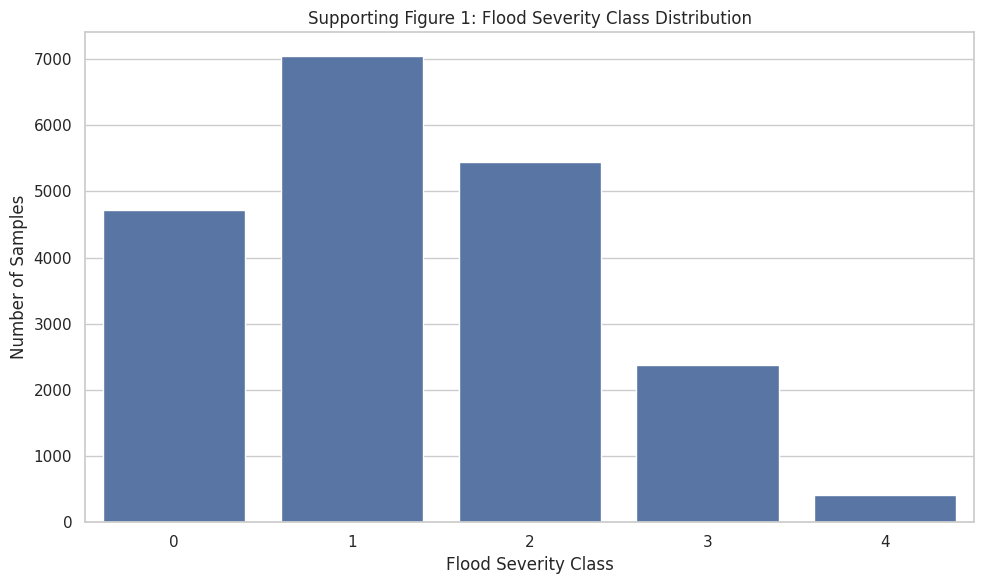

In [6]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    order=classes
)

plt.title(
    "Supporting Figure 1: Flood Severity Class Distribution"
)

plt.xlabel(
    "Flood Severity Class"
)

plt.ylabel(
    "Number of Samples"
)

plt.tight_layout()
plt.show()

MISSING VALUE ANALYSIS

In [7]:
print("\n4. MISSING VALUE ANALYSIS")

missing_plot = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_plot = missing_plot[
    missing_plot > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values
    )

    plt.title(
        "Supporting Figure 2: Missing Values by Feature"
    )

    plt.xlabel("Feature")
    plt.ylabel("Missing Values")

    plt.xticks(
        rotation=70,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "No missing values requiring visualization were detected."
    )


4. MISSING VALUE ANALYSIS
No missing values requiring visualization were detected.


DATA CLEANING

In [8]:
print("\n5. DATA CLEANING")

rows_before_duplicates = len(df)

df = (
    df.drop_duplicates()
    .reset_index(drop=True)
)

rows_after_duplicates = len(df)

print(
    "Rows Before Duplicate Removal:",
    rows_before_duplicates
)

print(
    "Rows After Duplicate Removal:",
    rows_after_duplicates
)

print(
    "Duplicates Removed:",
    rows_before_duplicates
    - rows_after_duplicates
)

X = df.drop(
    columns=[TARGET_COLUMN]
).copy()

y = df[TARGET_COLUMN].copy()

original_feature_names = X.columns.tolist()

numeric_feature_names = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_feature_names = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print(
    "\nOriginal Number of Features:",
    X.shape[1]
)

print(
    "Numerical Features:",
    len(numeric_feature_names)
)

print(
    "Categorical Features:",
    len(categorical_feature_names)
)


5. DATA CLEANING
Rows Before Duplicate Removal: 20000
Rows After Duplicate Removal: 20000
Duplicates Removed: 0

Original Number of Features: 21
Numerical Features: 20
Categorical Features: 1


TRAIN TEST SPLIT

In [9]:
print("\n6. TRAIN / TEST SPLIT")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(
    "Training Samples:",
    len(X_train_raw)
)

print(
    "Testing Samples:",
    len(X_test_raw)
)

print("\nTraining Class Distribution:")

display(
    y_train
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

print("\nTesting Class Distribution:")

display(
    y_test
    .value_counts()
    .sort_index()
    .to_frame("Count")
)


6. TRAIN / TEST SPLIT
Training Samples: 16000
Testing Samples: 4000

Training Class Distribution:


,Count
flood_severity_stage,
0,3779
1,5640
2,4351
3,1905
4,325



Testing Class Distribution:


,Count
flood_severity_stage,
0,945
1,1410
2,1088
3,476
4,81


MISSING VALUE HANDLING

In [10]:
print("\n7. MISSING VALUE HANDLING")

numeric_imputer = SimpleImputer(
    strategy="median"
)

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_train_numeric = pd.DataFrame(
    numeric_imputer.fit_transform(
        X_train_raw[numeric_feature_names]
    ),
    columns=numeric_feature_names,
    index=X_train_raw.index
)

X_test_numeric = pd.DataFrame(
    numeric_imputer.transform(
        X_test_raw[numeric_feature_names]
    ),
    columns=numeric_feature_names,
    index=X_test_raw.index
)

if len(categorical_feature_names) > 0:

    X_train_categorical = pd.DataFrame(
        categorical_imputer.fit_transform(
            X_train_raw[
                categorical_feature_names
            ]
        ),
        columns=categorical_feature_names,
        index=X_train_raw.index
    )

    X_test_categorical = pd.DataFrame(
        categorical_imputer.transform(
            X_test_raw[
                categorical_feature_names
            ]
        ),
        columns=categorical_feature_names,
        index=X_test_raw.index
    )

else:

    X_train_categorical = pd.DataFrame(
        index=X_train_raw.index
    )

    X_test_categorical = pd.DataFrame(
        index=X_test_raw.index
    )

print(
    "Missing-value handling completed."
)


7. MISSING VALUE HANDLING
Missing-value handling completed.


OUTLIER DETECTION USING IQR AND Z-SCORE

In [11]:
print("\n8. OUTLIER ANALYSIS USING IQR AND Z-SCORE")

iqr_outlier_mask = np.zeros(
    len(X_train_numeric),
    dtype=bool
)

zscore_outlier_mask = np.zeros(
    len(X_train_numeric),
    dtype=bool
)

iqr_counts = {}
zscore_counts = {}

for feature in numeric_feature_names:

    values = X_train_numeric[feature]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    feature_iqr_mask = (
        (values < lower_bound)
        |
        (values > upper_bound)
    )

    iqr_counts[feature] = (
        feature_iqr_mask.sum()
    )

    iqr_outlier_mask |= (
        feature_iqr_mask.values
    )

for feature in numeric_feature_names:

    values = X_train_numeric[feature]

    mean_value = values.mean()
    std_value = values.std(ddof=0)

    if std_value == 0:

        feature_z_mask = np.zeros(
            len(values),
            dtype=bool
        )

    else:

        z_values = np.abs(
            (values - mean_value)
            / std_value
        )

        feature_z_mask = (
            z_values > 3.5
        )

    zscore_counts[feature] = (
        feature_z_mask.sum()
    )

    zscore_outlier_mask |= (
        feature_z_mask.values
    )

combined_outlier_mask = (
    iqr_outlier_mask
    |
    zscore_outlier_mask
)

print(
    "Training Rows Before Outlier Removal:",
    len(X_train_raw)
)

print(
    "IQR Outlier Rows:",
    iqr_outlier_mask.sum()
)

print(
    "Z-score Outlier Rows:",
    zscore_outlier_mask.sum()
)

print(
    "Rows Identified by Either Method:",
    combined_outlier_mask.sum()
)

X_train_clean = X_train_numeric.loc[
    ~combined_outlier_mask
].copy()

y_train_clean = y_train.loc[
    X_train_clean.index
].copy()

X_train_cat_clean = (
    X_train_categorical.loc[
        X_train_clean.index
    ].copy()
)

print(
    "Training Rows After Outlier Removal:",
    len(X_train_clean)
)

print(
    "Rows Removed:",
    len(X_train_raw)
    - len(X_train_clean)
)

outlier_table = pd.DataFrame({

    "Feature":
        numeric_feature_names,

    "IQR_Outliers": [
        iqr_counts[f]
        for f in numeric_feature_names
    ],

    "ZScore_Outliers": [
        zscore_counts[f]
        for f in numeric_feature_names
    ]
})

display(outlier_table)


8. OUTLIER ANALYSIS USING IQR AND Z-SCORE
Training Rows Before Outlier Removal: 16000
IQR Outlier Rows: 596
Z-score Outlier Rows: 109
Rows Identified by Either Method: 596
Training Rows After Outlier Removal: 15404
Rows Removed: 596


,Feature,IQR_Outliers,ZScore_Outliers
0,rainfall_intensity_mmhr,28,0
1,current_water_level_m,15,0
2,water_level_rise_rate_mhr,21,0
3,flow_rate_m3s,16,0
4,soil_moisture_pct,21,0
5,drain_blockage_pct,0,0
6,temperature_c,121,9
7,humidity_pct,27,0
8,atmospheric_pressure_hpa,34,1
9,ground_water_level_m,17,0


BOX PLOTS BEFORE OUTLIER REMOVAL

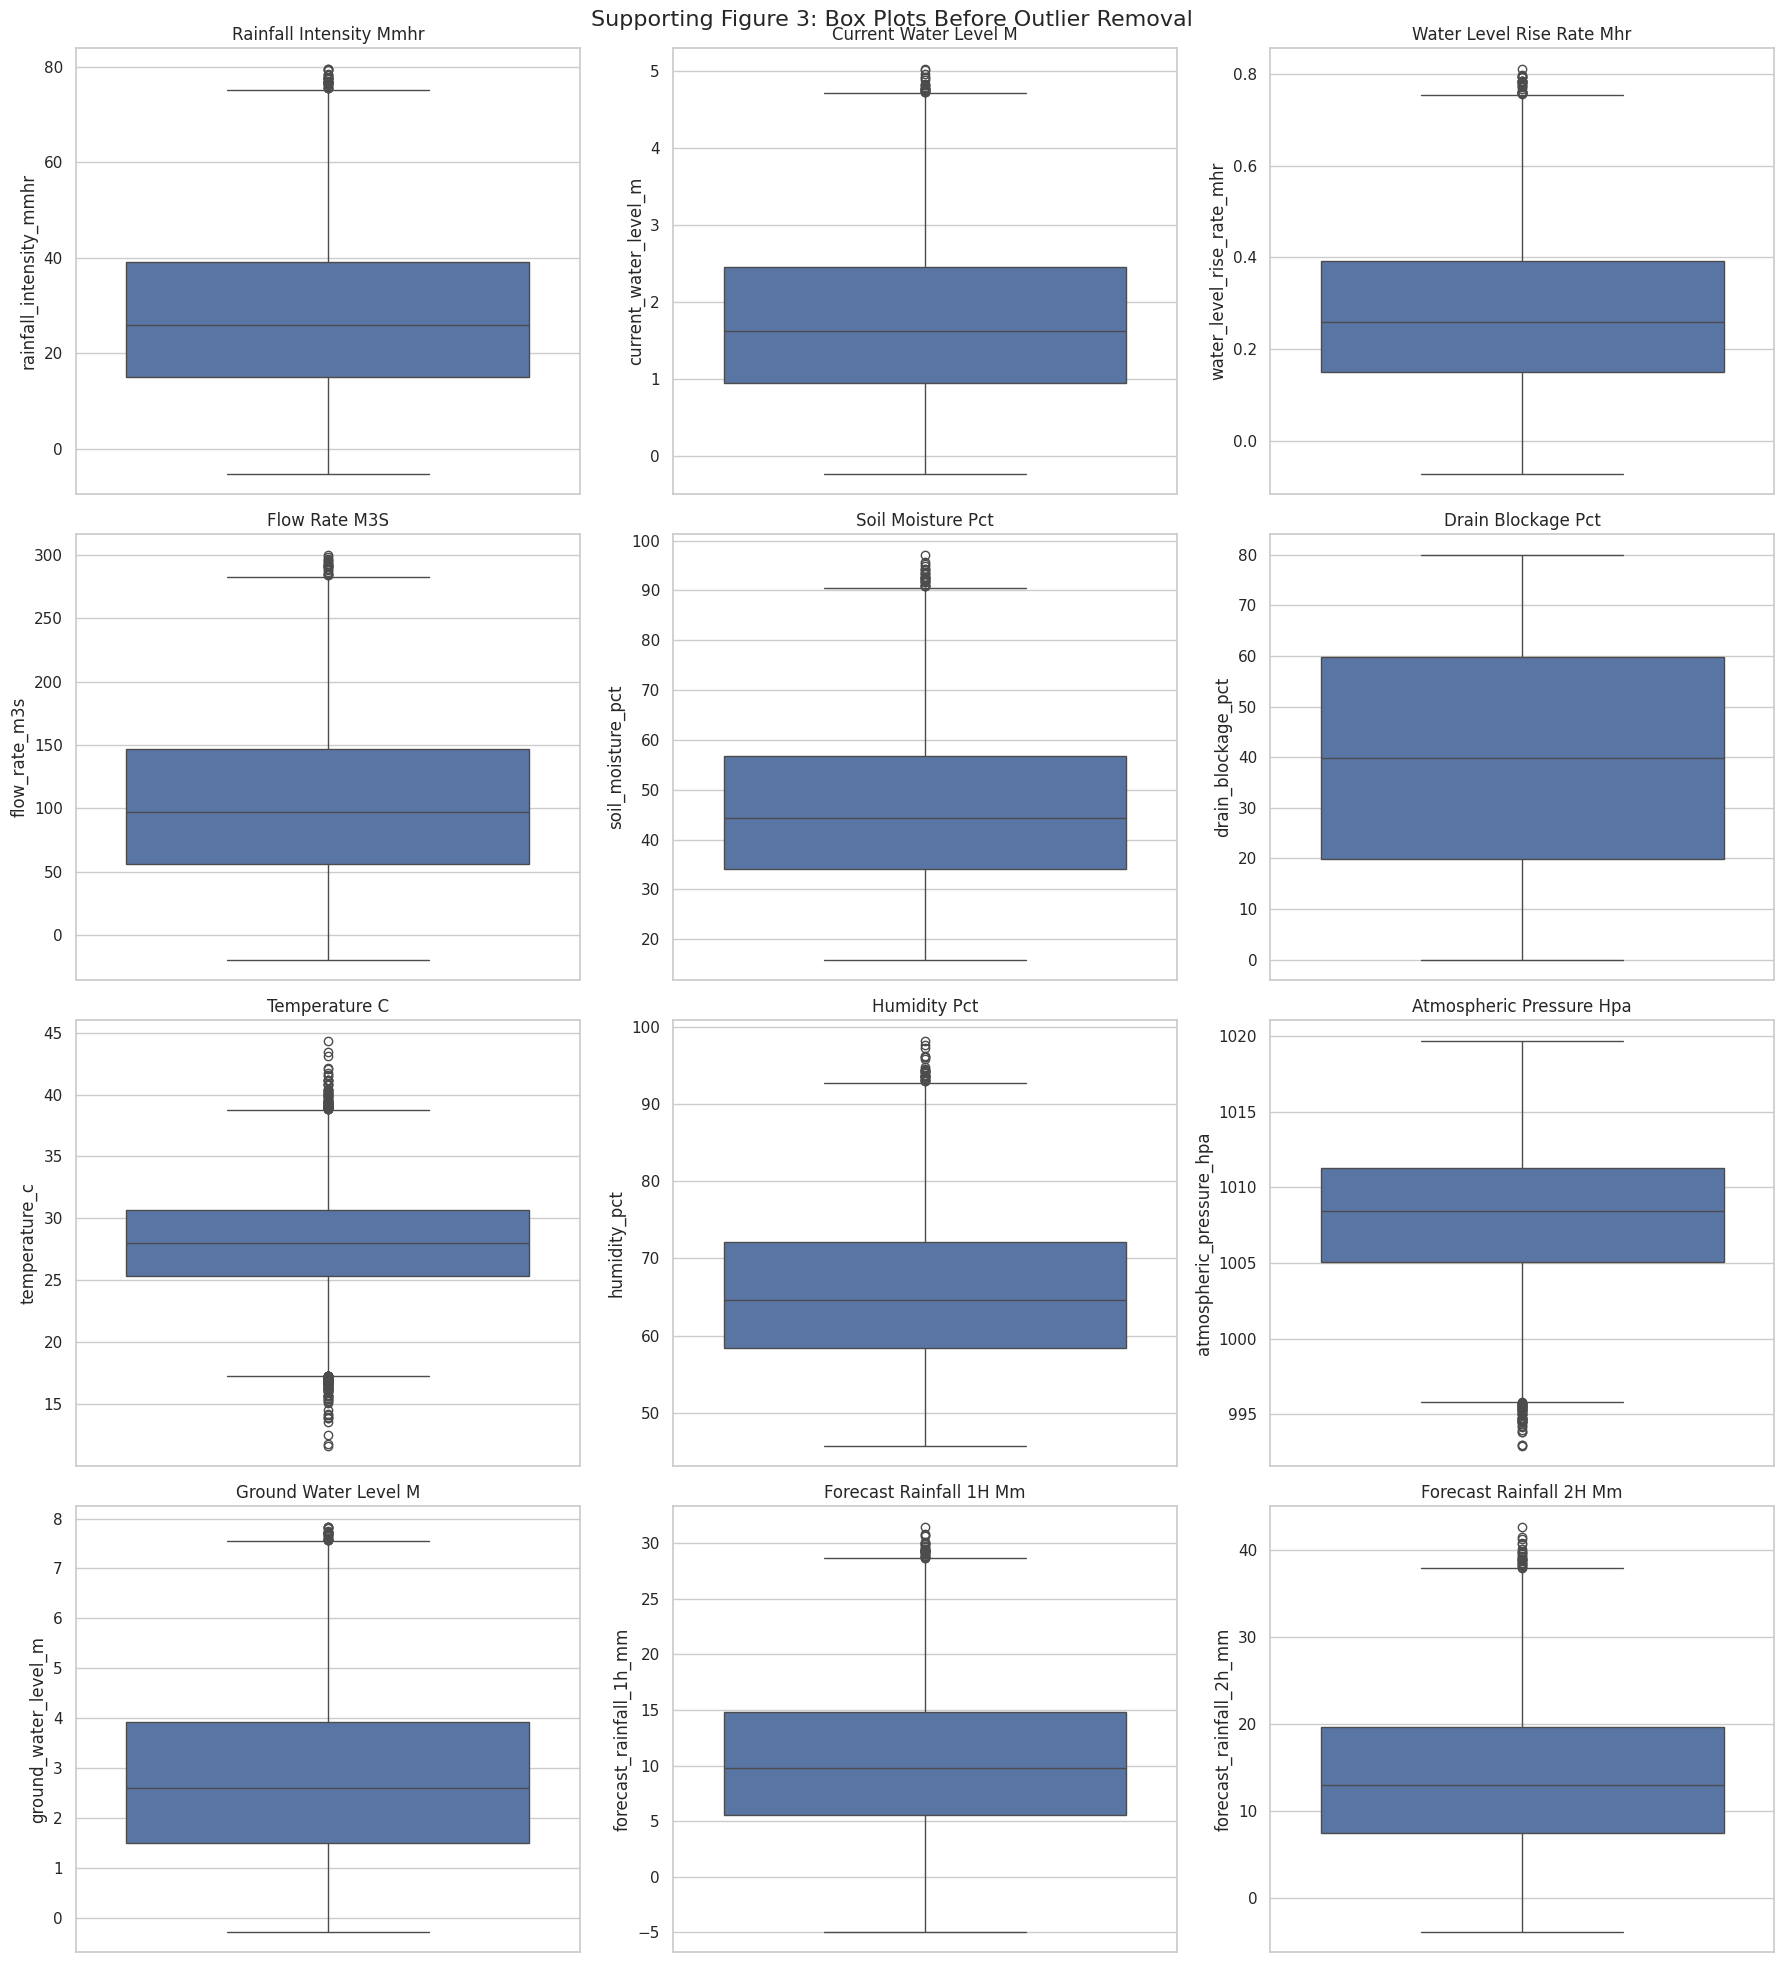

In [12]:
box_features = numeric_feature_names[
    :min(12, len(numeric_feature_names))
]

n_cols = 3

n_rows = int(
    np.ceil(
        len(box_features)
        / n_cols
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, feature in zip(
    axes,
    box_features
):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(
        feature.replace(
            "_",
            " "
        ).title()
    )

for ax in axes[
    len(box_features):
]:

    ax.axis("off")

plt.suptitle(
    "Supporting Figure 3: Box Plots Before Outlier Removal",
    fontsize=16
)

plt.tight_layout()
plt.show()

SCATTER PLOT

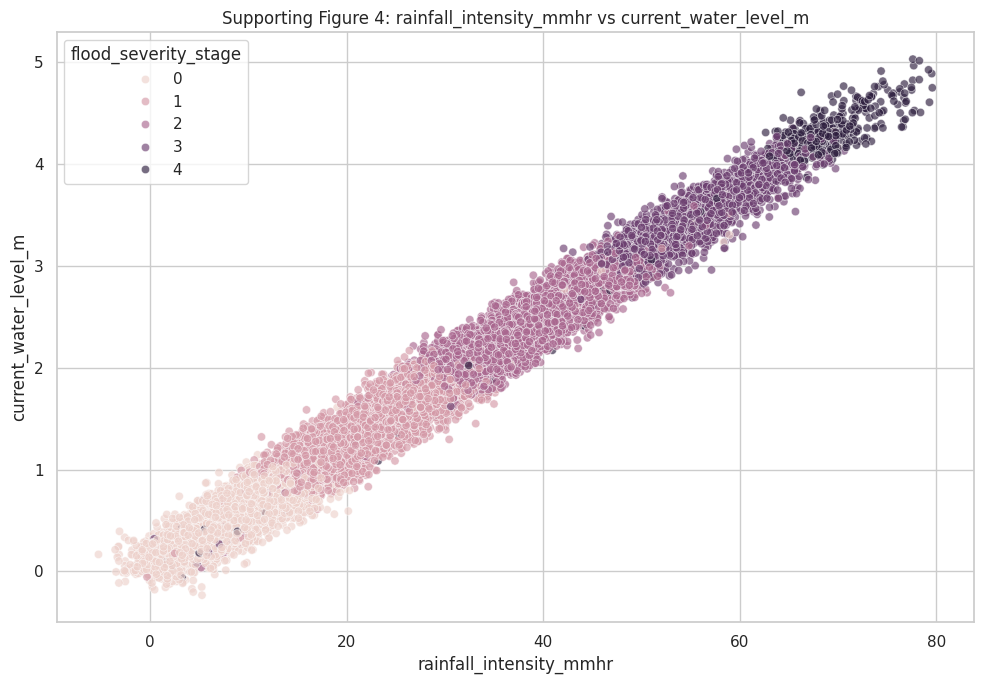

In [13]:
if len(numeric_feature_names) >= 2:

    scatter_x = numeric_feature_names[0]
    scatter_y = numeric_feature_names[1]

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=df,
        x=scatter_x,
        y=scatter_y,
        hue=TARGET_COLUMN,
        hue_order=classes,
        alpha=0.65
    )

    plt.title(
        f"Supporting Figure 4: {scatter_x} vs {scatter_y}"
    )

    plt.xlabel(scatter_x)
    plt.ylabel(scatter_y)

    plt.tight_layout()
    plt.show()

BOX PLOTS AFTER OUTLIER REMOVAL

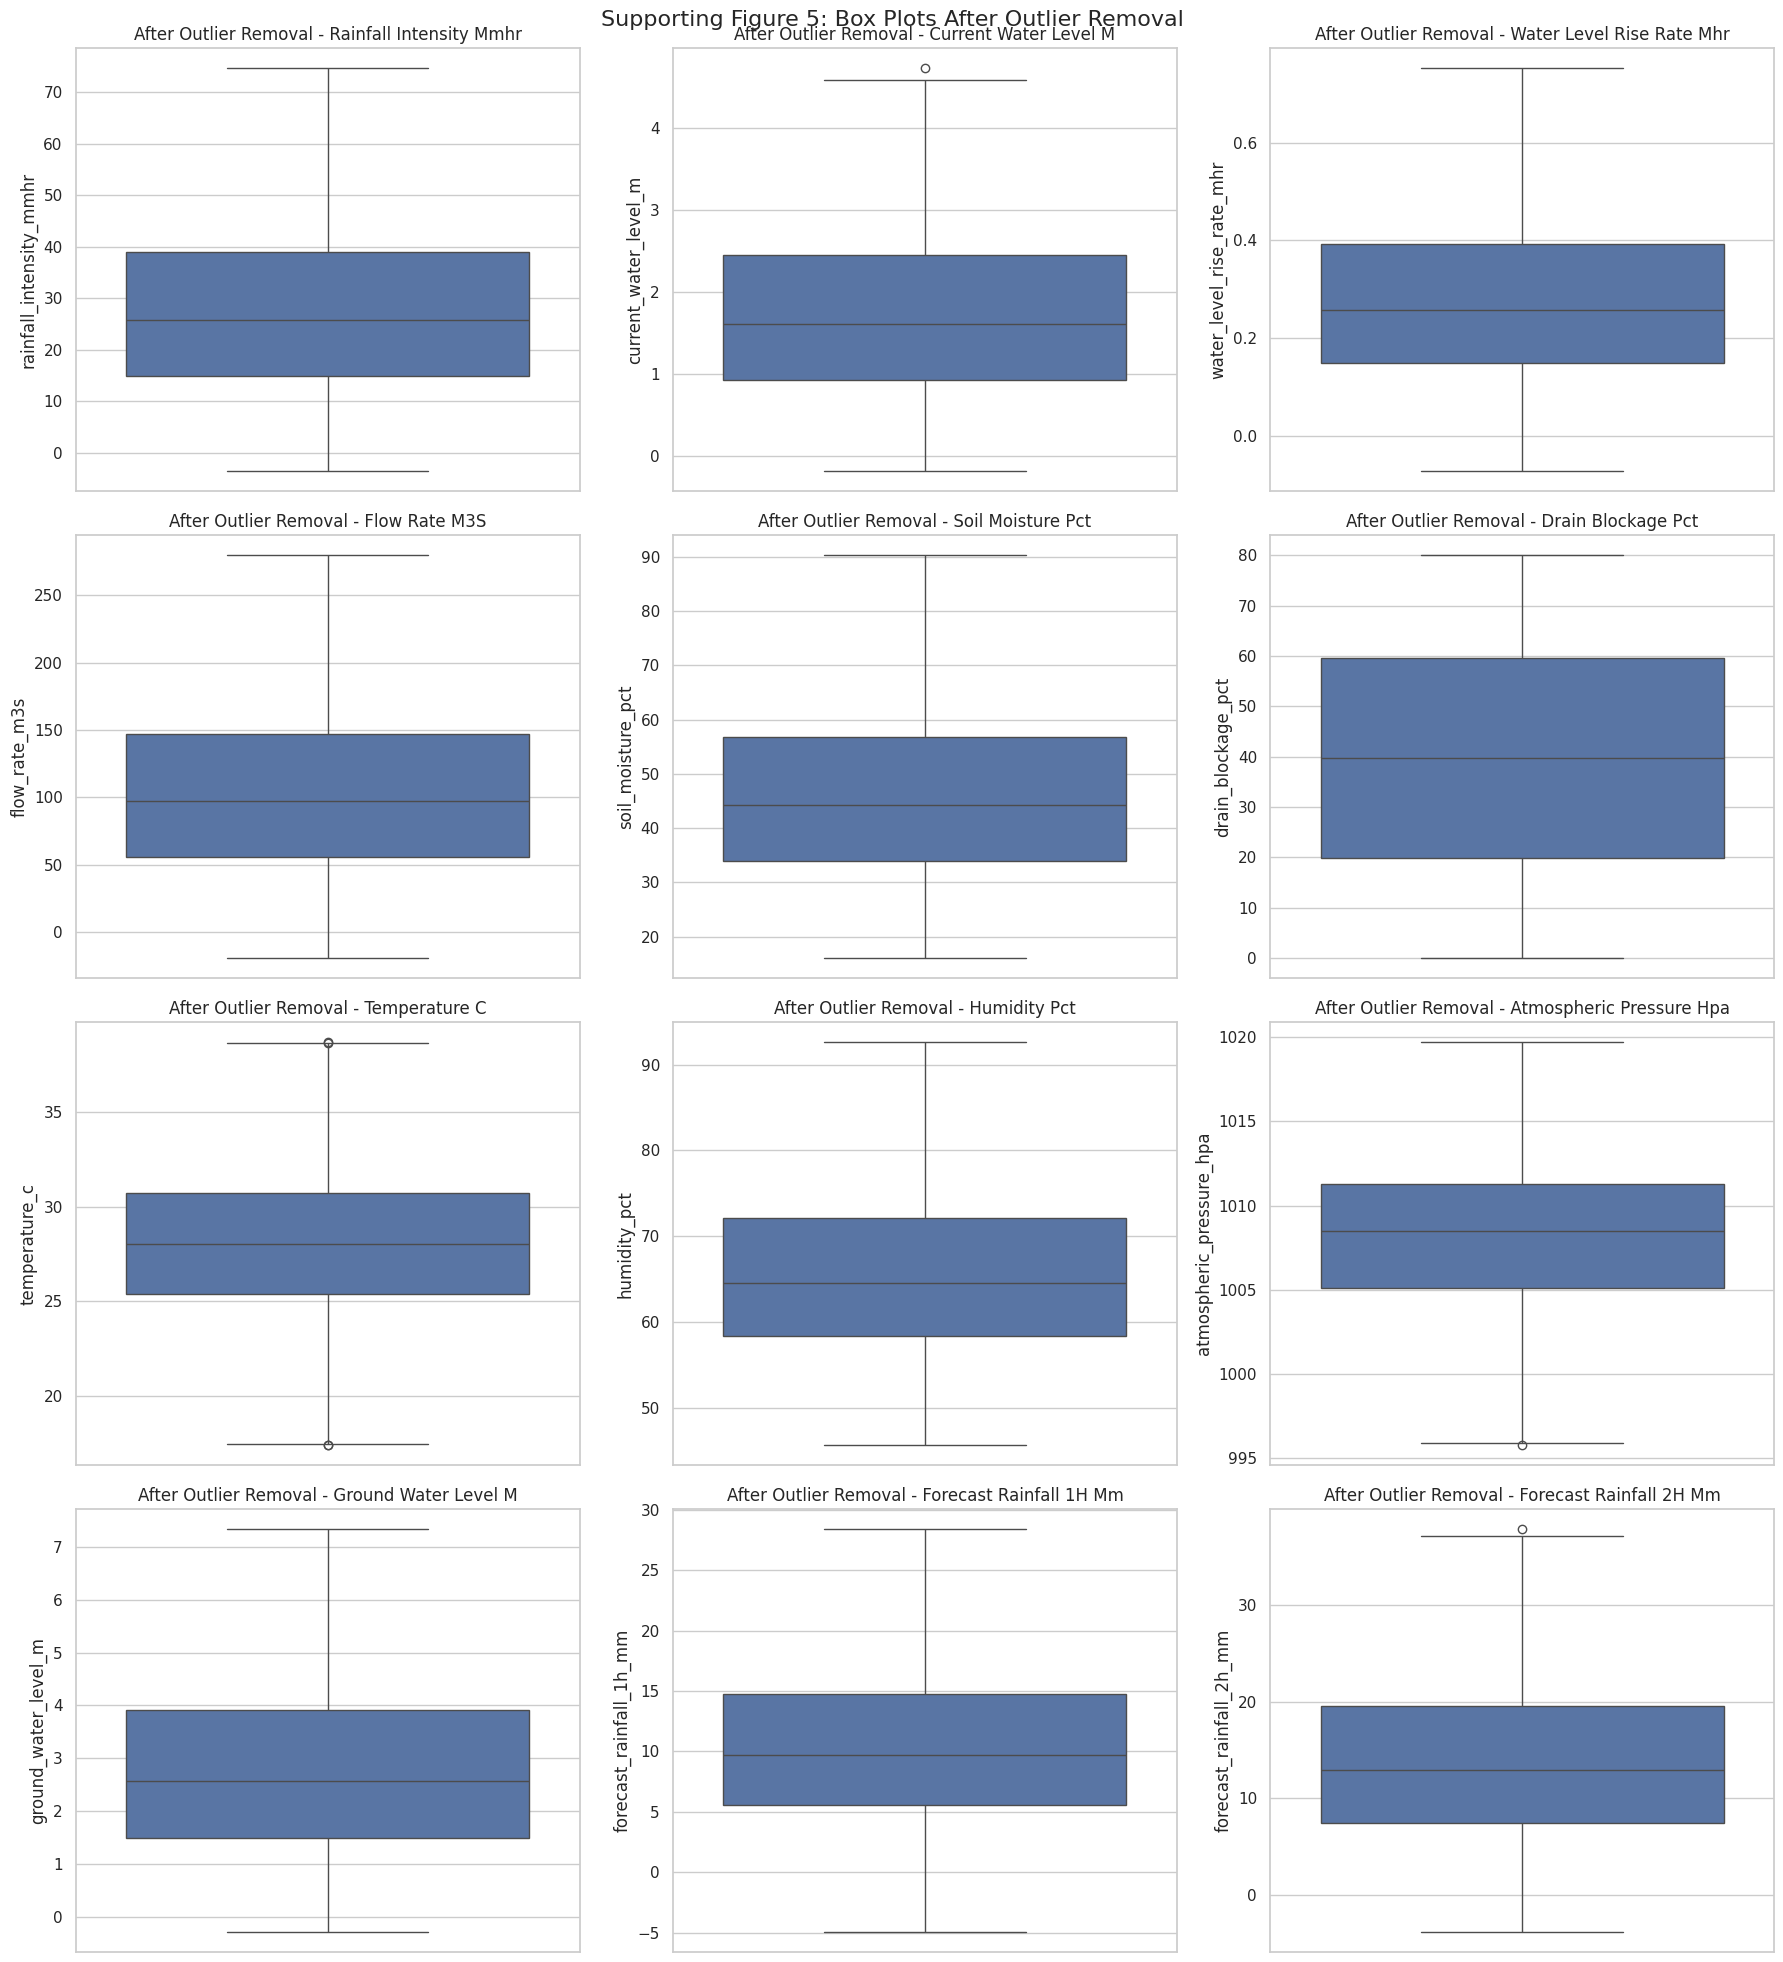

In [14]:
box_features_after = numeric_feature_names[
    :min(12, len(numeric_feature_names))
]

n_cols = 3

n_rows = int(
    np.ceil(
        len(box_features_after)
        / n_cols
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, feature in zip(
    axes,
    box_features_after
):

    sns.boxplot(
        y=X_train_clean[feature],
        ax=ax
    )

    ax.set_title(
        "After Outlier Removal - "
        +
        feature.replace(
            "_",
            " "
        ).title()
    )

for ax in axes[
    len(box_features_after):
]:

    ax.axis("off")

plt.suptitle(
    "Supporting Figure 5: Box Plots After Outlier Removal",
    fontsize=16
)

plt.tight_layout()
plt.show()

CLASS DISTRIBUTION AFTER PREPROCESSING

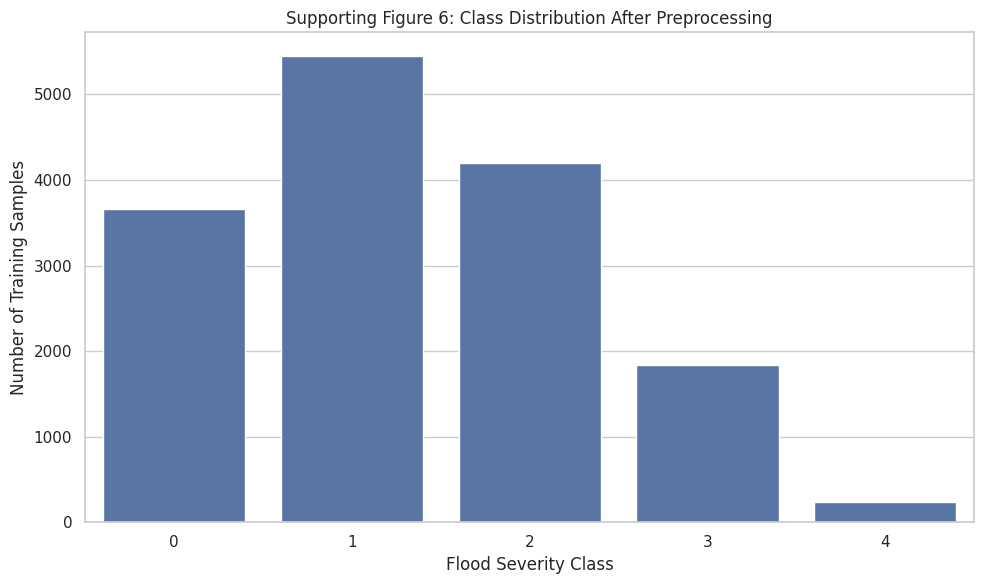

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x=y_train_clean,
    order=classes
)

plt.title(
    "Supporting Figure 6: Class Distribution After Preprocessing"
)

plt.xlabel(
    "Flood Severity Class"
)

plt.ylabel(
    "Number of Training Samples"
)

plt.tight_layout()
plt.show()

PEARSON CORRELATION ANALYSIS


9. PEARSON CORRELATION ANALYSIS

Pearson Correlation Matrix of Input Features


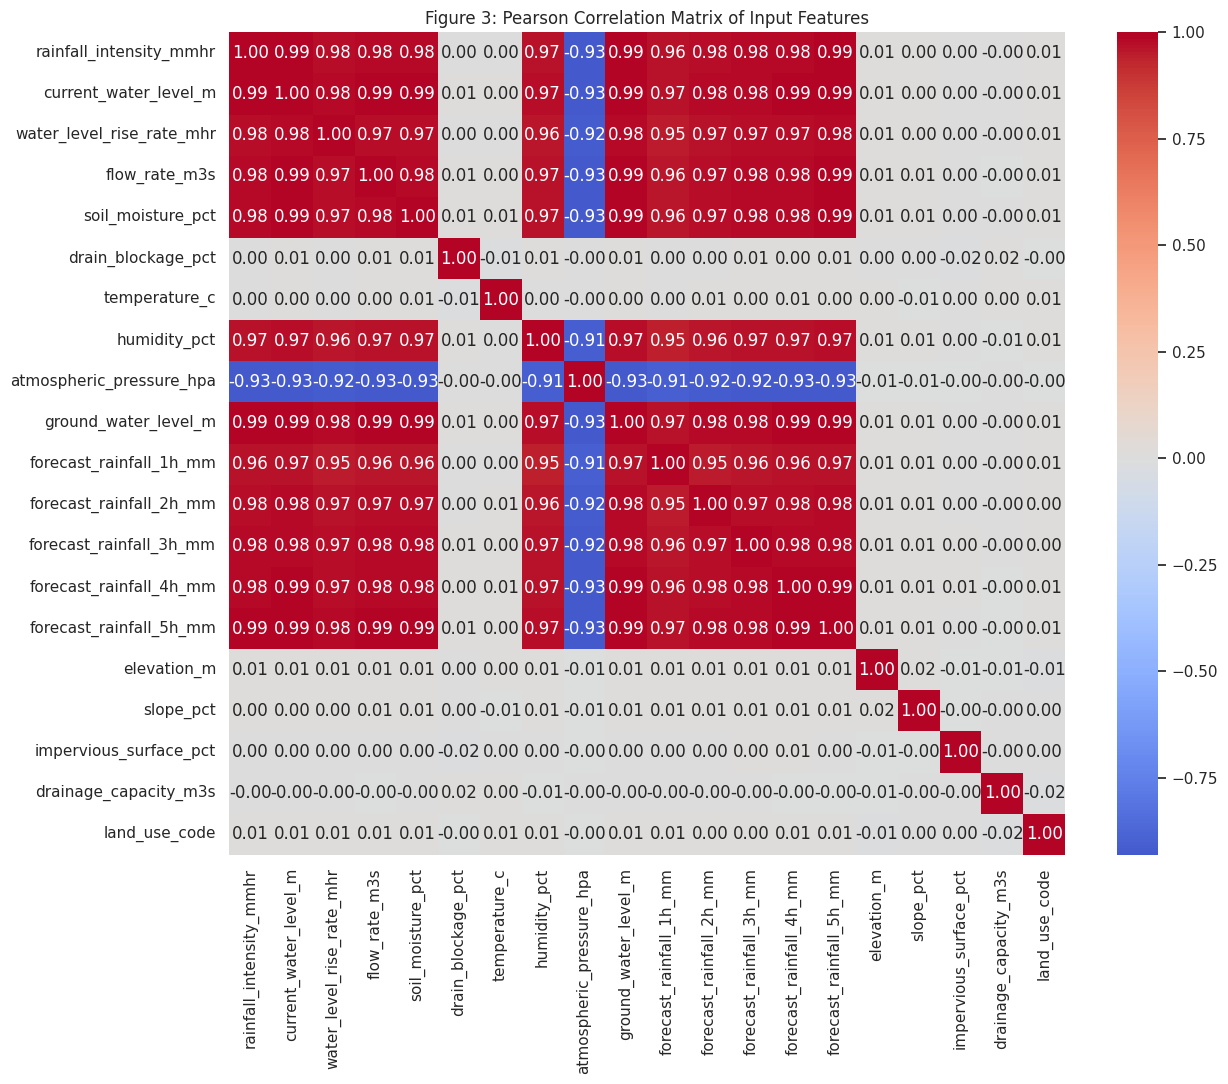

In [16]:
print("\n9. PEARSON CORRELATION ANALYSIS")

pearson_correlation_matrix = (
    X_train_clean
    .corr(method="pearson")
)

print(
    "\nPearson Correlation Matrix of Input Features"
)

plt.figure(
    figsize=(
        max(
            12,
            len(numeric_feature_names) * 0.65
        ),
        max(
            10,
            len(numeric_feature_names) * 0.55
        )
    )
)

sns.heatmap(
    pearson_correlation_matrix,
    annot=len(numeric_feature_names) <= 20,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Figure 3: Pearson Correlation Matrix of Input Features"
)

plt.tight_layout()
plt.show()

SPEARMAN CORRELATION ANALYSIS


10. SPEARMAN CORRELATION ANALYSIS

Spearman Correlation Matrix of Input Features


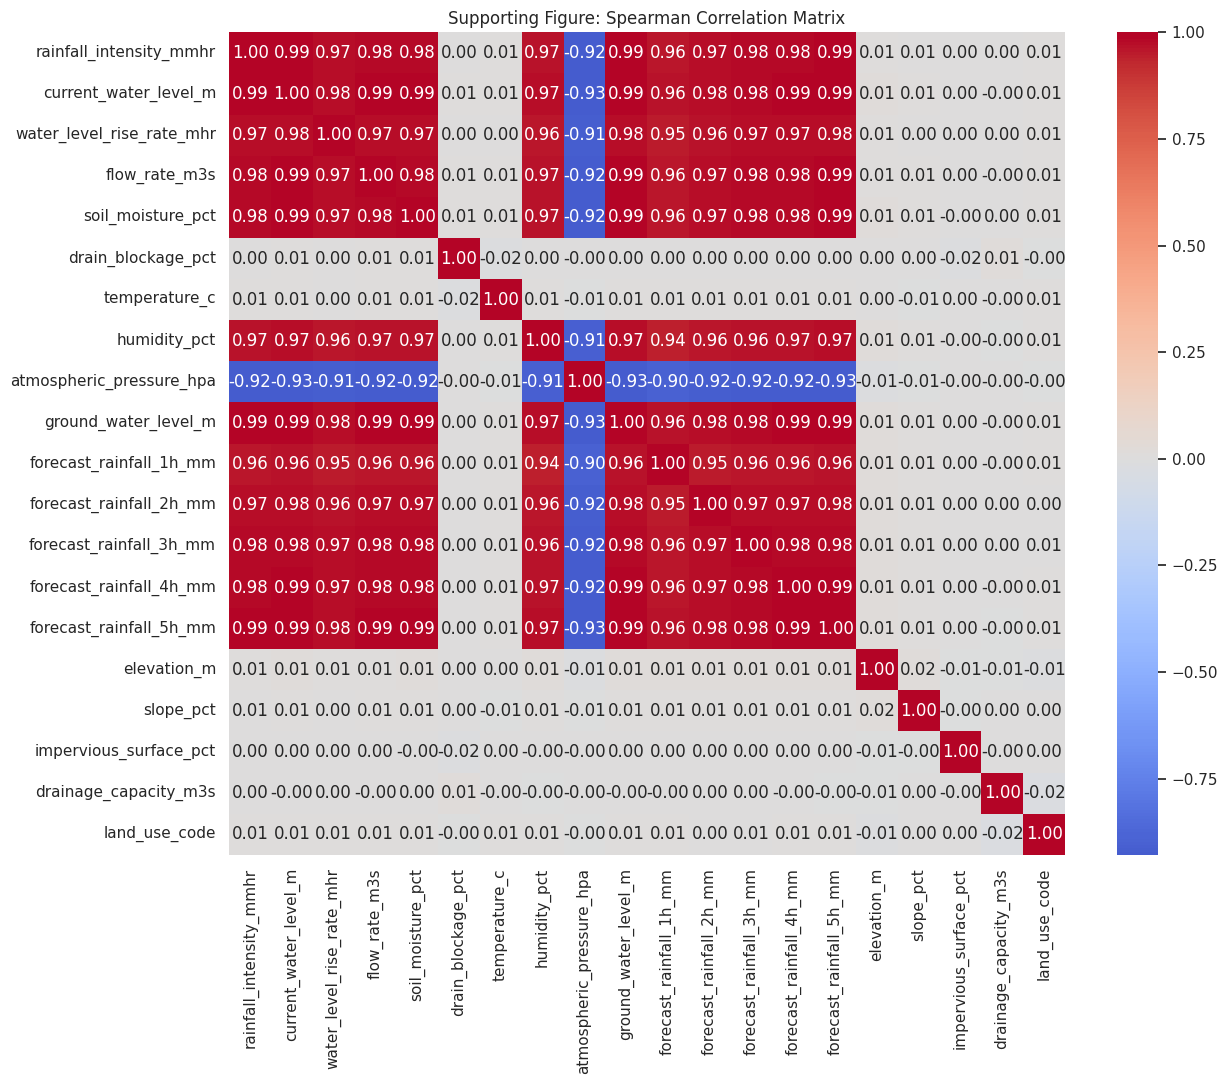

In [17]:
print("\n10. SPEARMAN CORRELATION ANALYSIS")

spearman_correlation_matrix = (
    X_train_clean
    .corr(method="spearman")
)

print(
    "\nSpearman Correlation Matrix of Input Features"
)

plt.figure(
    figsize=(
        max(
            12,
            len(numeric_feature_names) * 0.65
        ),
        max(
            10,
            len(numeric_feature_names) * 0.55
        )
    )
)

sns.heatmap(
    spearman_correlation_matrix,
    annot=len(numeric_feature_names) <= 20,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Supporting Figure: Spearman Correlation Matrix"
)

plt.tight_layout()
plt.show()

CORRELATION BASED FEATURE SELECTION

In [18]:
print("\n11. CORRELATION-BASED FEATURE SELECTION")

upper_triangle = (
    pearson_correlation_matrix
    .where(
        np.triu(
            np.ones(
                pearson_correlation_matrix.shape
            ),
            k=1
        ).astype(bool)
    )
)

correlated_features = [
    column
    for column in upper_triangle.columns
    if any(
        abs(
            upper_triangle[column]
        )
        >
        CORRELATION_THRESHOLD
    )
]

selected_numeric_features = [
    feature
    for feature in numeric_feature_names
    if feature not in correlated_features
]

if len(selected_numeric_features) == 0:

    selected_numeric_features = [
        numeric_feature_names[0]
    ]

print(
    "Original Numerical Features:",
    len(numeric_feature_names)
)

print(
    "Removed Highly Correlated Features:",
    len(correlated_features)
)

print(
    "Selected Numerical Features:",
    len(selected_numeric_features)
)

print("\nRemoved Features:")

for feature in correlated_features:
    print(feature)

print("\nSelected Features:")

for feature in selected_numeric_features:
    print(feature)

selected_categorical_features = (
    categorical_feature_names.copy()
)

print(
    "\nCategorical Features Retained:",
    selected_categorical_features
)


11. CORRELATION-BASED FEATURE SELECTION
Original Numerical Features: 20
Removed Highly Correlated Features: 12
Selected Numerical Features: 8

Removed Features:
current_water_level_m
water_level_rise_rate_mhr
flow_rate_m3s
soil_moisture_pct
humidity_pct
atmospheric_pressure_hpa
ground_water_level_m
forecast_rainfall_1h_mm
forecast_rainfall_2h_mm
forecast_rainfall_3h_mm
forecast_rainfall_4h_mm
forecast_rainfall_5h_mm

Selected Features:
rainfall_intensity_mmhr
drain_blockage_pct
temperature_c
elevation_m
slope_pct
impervious_surface_pct
drainage_capacity_m3s
land_use_code

Categorical Features Retained: ['land_use_name']


SELECTED FEATURES

In [19]:
X_train_selected_numeric = (
    X_train_clean[
        selected_numeric_features
    ].copy()
)

X_test_selected_numeric = (
    X_test_numeric[
        selected_numeric_features
    ].copy()
)

X_train_selected_categorical = (
    X_train_cat_clean[
        selected_categorical_features
    ].copy()
)

X_test_selected_categorical = (
    X_test_categorical[
        selected_categorical_features
    ].copy()
)

CORRELATION MATRIX OF SELECTED FEATURES


12. CORRELATION MATRIX OF SELECTED FEATURES


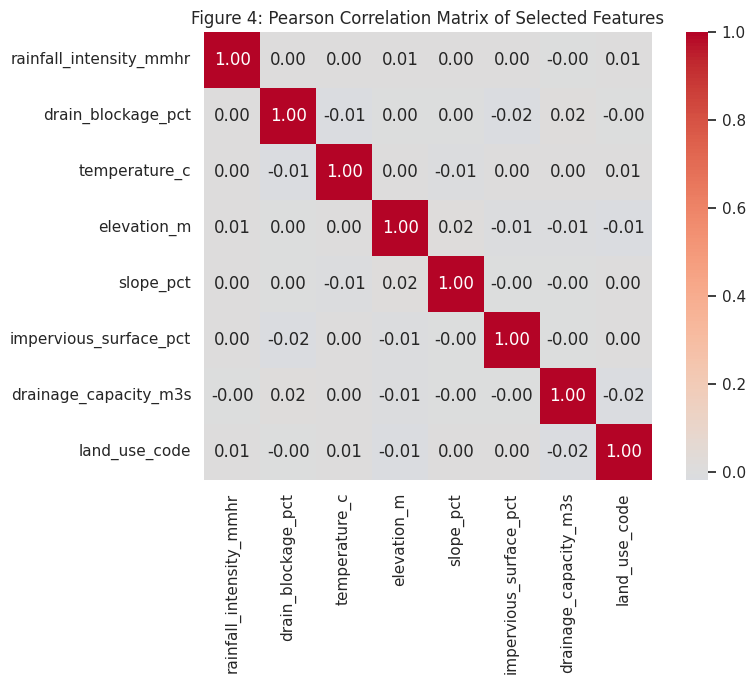

In [20]:
print(
    "\n12. CORRELATION MATRIX OF SELECTED FEATURES"
)

selected_pearson_corr = (
    X_train_selected_numeric
    .corr(method="pearson")
)

plt.figure(
    figsize=(
        max(
            9,
            len(selected_numeric_features) * 0.7
        ),
        max(
            7,
            len(selected_numeric_features) * 0.6
        )
    )
)

sns.heatmap(
    selected_pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Figure 4: Pearson Correlation Matrix of Selected Features"
)

plt.tight_layout()
plt.show()

SELECTED FEATURE SPEARMAN CORRELATION

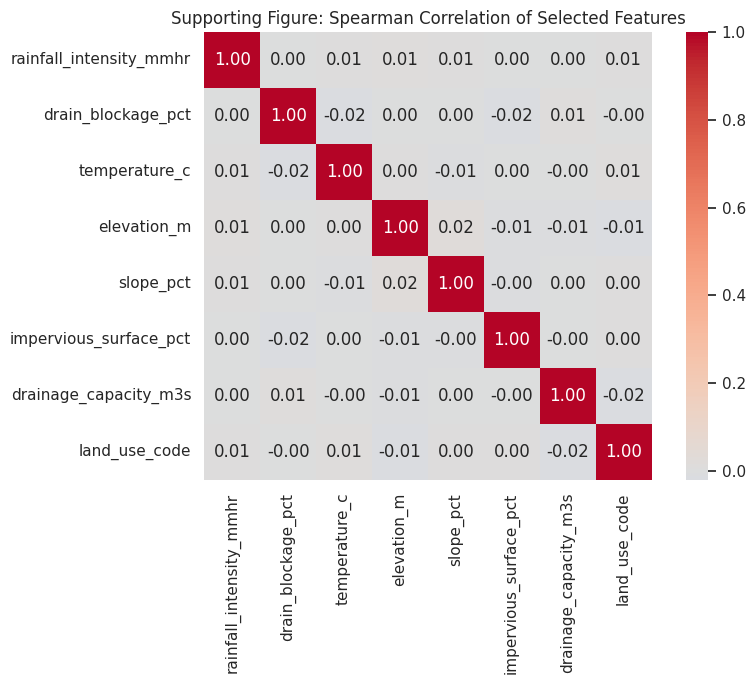

In [21]:
selected_spearman_corr = (
    X_train_selected_numeric
    .corr(method="spearman")
)

plt.figure(
    figsize=(
        max(
            9,
            len(selected_numeric_features) * 0.7
        ),
        max(
            7,
            len(selected_numeric_features) * 0.6
        )
    )
)

sns.heatmap(
    selected_spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Supporting Figure: Spearman Correlation of Selected Features"
)

plt.tight_layout()
plt.show()

CORRELATION WITH TARGET

In [22]:
print(
    "\n13. FEATURE-TARGET CORRELATION ANALYSIS"
)

target_numeric_train = (
    pd.DataFrame({
        TARGET_COLUMN:
        y_train_clean
    })
)

feature_target_data = pd.concat(
    [
        X_train_selected_numeric.reset_index(
            drop=True
        ),
        target_numeric_train.reset_index(
            drop=True
        )
    ],
    axis=1
)

pearson_target = (
    feature_target_data
    .corr(method="pearson")[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

spearman_target = (
    feature_target_data
    .corr(method="spearman")[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

target_correlation_table = pd.DataFrame({
    "Feature":
        pearson_target.index,

    "Pearson_Correlation":
        pearson_target.values,

    "Spearman_Correlation":
        spearman_target.reindex(
            pearson_target.index
        ).values
})

display(
    target_correlation_table
)


13. FEATURE-TARGET CORRELATION ANALYSIS


,Feature,Pearson_Correlation,Spearman_Correlation
0,rainfall_intensity_mmhr,0.903296,0.915089
1,elevation_m,0.014395,0.016319
2,slope_pct,0.004486,0.004551
3,drain_blockage_pct,0.003640,0.004763
4,drainage_capacity_m3s,0.003361,0.005313
5,land_use_code,0.003189,0.004472
6,impervious_surface_pct,0.001508,0.001984
7,temperature_c,-0.000622,0.002377


CATEGORICAL ENCODING

In [23]:
print("\n14. CATEGORICAL ENCODING")

if len(selected_categorical_features) > 0:

    try:

        encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

    except TypeError:

        encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

    X_train_cat_encoded = (
        encoder.fit_transform(
            X_train_selected_categorical
        )
    )

    X_test_cat_encoded = (
        encoder.transform(
            X_test_selected_categorical
        )
    )

    encoded_categorical_names = (
        encoder
        .get_feature_names_out(
            selected_categorical_features
        )
        .tolist()
    )

else:

    X_train_cat_encoded = np.empty(
        (
            len(
                X_train_selected_numeric
            ),
            0
        )
    )

    X_test_cat_encoded = np.empty(
        (
            len(
                X_test_selected_numeric
            ),
            0
        )
    )

    encoded_categorical_names = []

X_train_feature_matrix = np.hstack(
    [
        X_train_selected_numeric.values,
        X_train_cat_encoded
    ]
)

X_test_feature_matrix = np.hstack(
    [
        X_test_selected_numeric.values,
        X_test_cat_encoded
    ]
)

all_selected_feature_names = (
    selected_numeric_features
    +
    encoded_categorical_names
)

print(
    "Final Feature Count Before PCA:",
    len(all_selected_feature_names)
)


14. CATEGORICAL ENCODING
Final Feature Count Before PCA: 14


FEATURE SCALING

In [24]:
print("\n15. FEATURE SCALING")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_feature_matrix
)

X_test_scaled = scaler.transform(
    X_test_feature_matrix
)

print(
    "Scaled Training Matrix:",
    X_train_scaled.shape
)

print(
    "Scaled Testing Matrix:",
    X_test_scaled.shape
)


15. FEATURE SCALING
Scaled Training Matrix: (15404, 14)
Scaled Testing Matrix: (4000, 14)


PCA ANALYSIS

In [25]:
print("\n16. PCA ANALYSIS")

pca_full = PCA()

X_train_pca_full = (
    pca_full.fit_transform(
        X_train_scaled
    )
)

individual_variance = (
    pca_full
    .explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    individual_variance
)

pca_components = (
    np.argmax(
        cumulative_variance
        >= PCA_VARIANCE
    )
    + 1
)

pca_components = max(
    1,
    min(
        pca_components,
        X_train_scaled.shape[1]
    )
)

pca = PCA(
    n_components=pca_components
)

X_train_pca = (
    pca.fit_transform(
        X_train_scaled
    )
)

X_test_pca = (
    pca.transform(
        X_test_scaled
    )
)

print(
    "PCA Components Required for 95% Variance:",
    pca_components
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)


16. PCA ANALYSIS
PCA Components Required for 95% Variance: 12
Total Explained Variance: 1.0


PCA EXPLAINED VARIANCE

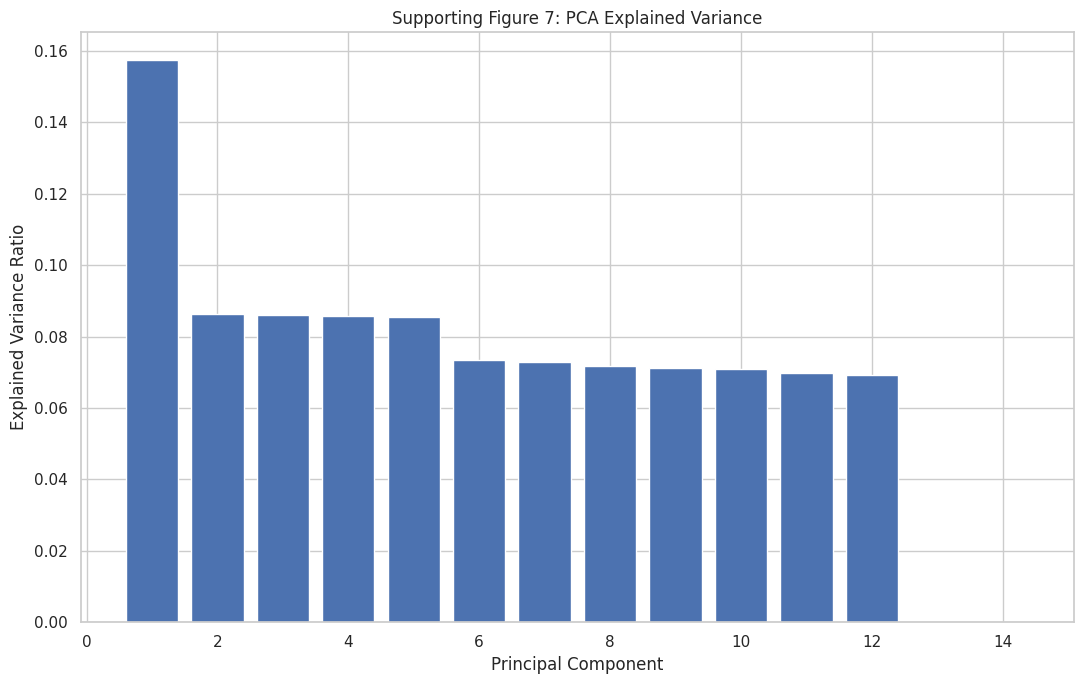

In [26]:
plt.figure(figsize=(11, 7))

plt.bar(
    range(
        1,
        len(individual_variance) + 1
    ),
    individual_variance
)

plt.title(
    "Supporting Figure 7: PCA Explained Variance"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Explained Variance Ratio"
)

plt.tight_layout()
plt.show()

CUMULATIVE PCA VARIANCE

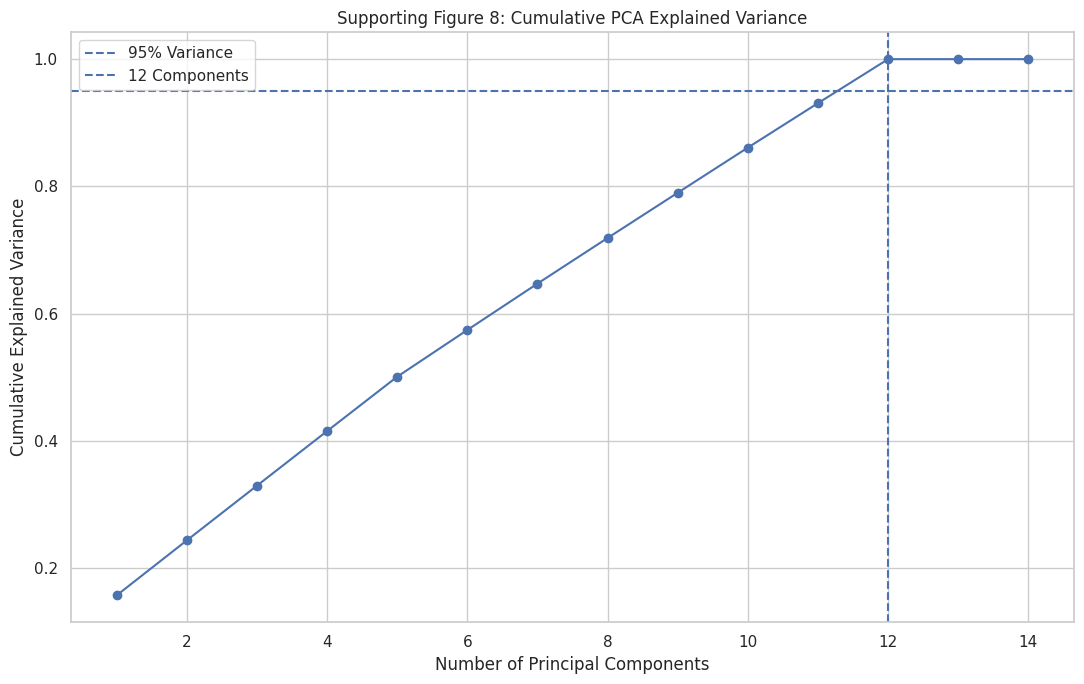

In [27]:
plt.figure(figsize=(11, 7))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    PCA_VARIANCE,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    pca_components,
    linestyle="--",
    label=f"{pca_components} Components"
)

plt.title(
    "Supporting Figure 8: Cumulative PCA Explained Variance"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.legend()

plt.tight_layout()
plt.show()

MODEL DEFINITIONS

In [28]:
print("\n17. MODEL CONFIGURATION")

models = {

    "Logistic Regression":
        LogisticRegression(
            C=2.0,
            solver="lbfgs",
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=11,
            weights="distance",
            metric="euclidean"
        ),

    "SVM-RBF":
        SVC(
            C=20,
            gamma=0.01,
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=400,
            max_depth=8,
            min_samples_split=2,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.85,
            colsample_bytree=0.90,
            objective="multi:softprob",
            num_class=len(classes),
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "LightGBM":
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.90,
            objective="multiclass",
            num_class=len(classes),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ),

    "CatBoost":
        CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="MultiClass",
            verbose=False,
            random_seed=RANDOM_STATE
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_split=3,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.5,
            random_state=RANDOM_STATE
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.85,
            random_state=RANDOM_STATE
        ),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=250,
            learning_rate=0.05,
            random_state=RANDOM_STATE
        )
}

print(
    "\nAlgorithms Implemented:"
)

for i, name in enumerate(
    models.keys(),
    start=1
):
    print(
        f"{i}. {name}"
    )


17. MODEL CONFIGURATION

Algorithms Implemented:
1. Logistic Regression
2. KNN
3. SVM-RBF
4. Random Forest
5. XGBoost
6. LightGBM
7. CatBoost
8. Extra Trees
9. Hist Gradient Boosting
10. Gradient Boosting
11. AdaBoost


MODEL INPUT STRATEGY


In [70]:
scaled_models = [
    "Logistic Regression",
    "KNN",
    "SVM-RBF"
]

tree_models = [
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "Extra Trees",
    "Hist Gradient Boosting",
    "Gradient Boosting",
    "AdaBoost"
]

def get_model_input(
    model_name,
    X_original,
    X_pca
):

    if model_name in scaled_models:

        return X_pca

    return X_original

METRIC FUNCTIONS

In [71]:
print("\n18. EVALUATION METRIC FUNCTIONS")

def calculate_specificity(
    y_true,
    y_pred,
    class_labels
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_labels
    )

    specificity_values = {}

    total = cm.sum()

    for i, class_label in enumerate(
        class_labels
    ):

        tp = cm[i, i]

        fn = (
            cm[i, :].sum()
            - tp
        )

        fp = (
            cm[:, i].sum()
            - tp
        )

        tn = (
            total
            - tp
            - fn
            - fp
        )

        denominator = tn + fp

        specificity_values[
            class_label
        ] = (
            tn / denominator
            if denominator > 0
            else np.nan
        )

    return specificity_values


def calculate_metrics(
    y_true,
    y_pred,
    y_prob=None
):

    result = {}

    result["Accuracy"] = (
        accuracy_score(
            y_true,
            y_pred
        )
    )

    result["Macro Precision"] = (
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    result["Macro Recall"] = (
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    result["Macro F1"] = (
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    result["Weighted Precision"] = (
        precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    result["Weighted Recall"] = (
        recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    result["Weighted F1"] = (
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    result["Balanced Accuracy"] = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    result["MCC"] = (
        matthews_corrcoef(
            y_true,
            y_pred
        )
    )

    specificity = (
        calculate_specificity(
            y_true,
            y_pred,
            classes
        )
    )

    result["Specificity"] = (
        np.nanmean(
            list(
                specificity.values()
            )
        )
    )

    result["Sensitivity"] = (
        result["Macro Recall"]
    )

    result["ROC-AUC"] = np.nan

    if y_prob is not None:

        try:

            result["ROC-AUC"] = (
                roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class="ovr",
                    average="macro",
                    labels=classes
                )
            )

        except Exception:

            try:

                y_binary = label_binarize(
                    y_true,
                    classes=classes
                )

                result["ROC-AUC"] = (
                    roc_auc_score(
                        y_binary,
                        y_prob,
                        average="macro"
                    )
                )

            except Exception:

                result["ROC-AUC"] = np.nan

    return result


def classwise_metrics(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    records = []

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=classes
    )

    for i, class_label in enumerate(
        classes
    ):

        tp = cm[i, i]

        fn = (
            cm[i, :].sum()
            - tp
        )

        fp = (
            cm[:, i].sum()
            - tp
        )

        tn = (
            cm.sum()
            - tp
            - fn
            - fp
        )

        precision = (
            tp / (tp + fp)
            if tp + fp > 0
            else 0
        )

        sensitivity = (
            tp / (tp + fn)
            if tp + fn > 0
            else 0
        )

        specificity = (
            tn / (tn + fp)
            if tn + fp > 0
            else 0
        )

        f1 = (
            2
            * precision
            * sensitivity
            /
            (
                precision
                + sensitivity
            )
            if precision + sensitivity > 0
            else 0
        )

        class_auc = np.nan

        if y_prob is not None:

            try:

                binary_true = (
                    y_true
                    == class_label
                ).astype(int)

                class_auc = (
                    roc_auc_score(
                        binary_true,
                        y_prob[:, i]
                    )
                )

            except Exception:
                pass

        records.append({

            "Model":
                model_name,

            "Class":
                class_label,

            "Precision":
                precision,

            "Sensitivity":
                sensitivity,

            "Specificity":
                specificity,

            "F1-Score":
                f1,

            "ROC-AUC":
                class_auc,

            "Support":
                tp + fn
        })

    return pd.DataFrame(records)


18. EVALUATION METRIC FUNCTIONS


REPEATED STRATIFIED VALIDATION

In [31]:
print(
    "\n19. 20 REPEATED STRATIFIED VALIDATION RUNS"
)

validation_splitter = (
    RepeatedStratifiedKFold(
        n_splits=N_SPLITS,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE
    )
)

validation_records = []

validation_predictions = {}

run_number = 0

for train_indices, validation_indices in (
    validation_splitter.split(
        X_train_feature_matrix,
        y_train_clean
    )
):

    run_number += 1

    print(
        f"Completed validation run "
        f"{run_number}/{VALIDATION_RUNS}"
    )

    X_tr_original = (
        X_train_feature_matrix[
            train_indices
        ]
    )

    X_val_original = (
        X_train_feature_matrix[
            validation_indices
        ]
    )

    X_tr_pca = (
        X_train_pca[
            train_indices
        ]
    )

    X_val_pca = (
        X_train_pca[
            validation_indices
        ]
    )

    y_tr = (
        y_train_clean
        .iloc[train_indices]
    )

    y_val = (
        y_train_clean
        .iloc[validation_indices]
    )

    validation_predictions[
        run_number
    ] = {}

    for model_name, base_model in (
        models.items()
    ):

        model_instance = clone(
            base_model
        )

        X_tr = get_model_input(
            model_name,
            X_tr_original,
            X_tr_pca
        )

        X_val = get_model_input(
            model_name,
            X_val_original,
            X_val_pca
        )

        model_instance.fit(
            X_tr,
            y_tr
        )

        y_val_pred = (
            model_instance
            .predict(X_val)
        )

        if hasattr(
            model_instance,
            "predict_proba"
        ):

            y_val_prob = (
                model_instance
                .predict_proba(X_val)
            )

        else:

            y_val_prob = None

        metrics = calculate_metrics(
            y_val,
            y_val_pred,
            y_val_prob
        )

        metrics["Run"] = run_number
        metrics["Model"] = model_name

        validation_records.append(
            metrics
        )

        validation_predictions[
            run_number
        ][model_name] = {

            "indices":
                validation_indices,

            "y_true":
                y_val.to_numpy(),

            "y_pred":
                y_val_pred,

            "probability":
                y_val_prob
        }

validation_results = pd.DataFrame(
    validation_records
)

print(
    "\nCompleted Validation Runs:",
    validation_results["Run"].nunique()
)


19. 20 REPEATED STRATIFIED VALIDATION RUNS
Completed validation run 1/20
Completed validation run 2/20
Completed validation run 3/20
Completed validation run 4/20
Completed validation run 5/20
Completed validation run 6/20
Completed validation run 7/20
Completed validation run 8/20
Completed validation run 9/20
Completed validation run 10/20
Completed validation run 11/20
Completed validation run 12/20
Completed validation run 13/20
Completed validation run 14/20
Completed validation run 15/20
Completed validation run 16/20
Completed validation run 17/20
Completed validation run 18/20
Completed validation run 19/20
Completed validation run 20/20

Completed Validation Runs: 20


VALIDATION PERFORMANCE SUMMARY

In [32]:
validation_summary = (
    validation_results
    .groupby("Model")
    .agg(

        Mean_Accuracy=(
            "Accuracy",
            "mean"
        ),

        Std_Accuracy=(
            "Accuracy",
            "std"
        ),

        Mean_Precision=(
            "Macro Precision",
            "mean"
        ),

        Mean_Recall=(
            "Macro Recall",
            "mean"
        ),

        Mean_F1=(
            "Macro F1",
            "mean"
        ),

        Std_F1=(
            "Macro F1",
            "std"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC",
            "mean"
        ),

        Mean_Balanced_Accuracy=(
            "Balanced Accuracy",
            "mean"
        ),

        Mean_Sensitivity=(
            "Sensitivity",
            "mean"
        ),

        Mean_Specificity=(
            "Specificity",
            "mean"
        ),

        Mean_MCC=(
            "MCC",
            "mean"
        )
    )
    .sort_values(
        [
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Accuracy"
        ],
        ascending=False
    )
)

print(
    "\nTable 4: Validation Performance Summary"
)

display(
    validation_summary.style.format(
        "{:.4f}"
    )
)


Table 4: Validation Performance Summary


,Mean_Accuracy,Std_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Std_F1,Mean_ROC_AUC,Mean_Balanced_Accuracy,Mean_Sensitivity,Mean_Specificity,Mean_MCC
Model,,,,,,,,,,,
CatBoost,0.8884,0.0051,0.8584,0.7997,0.8209,0.0150,0.9423,0.7997,0.7997,0.9690,0.8464
Hist Gradient Boosting,0.8826,0.0050,0.8502,0.7914,0.8125,0.0157,0.9391,0.7914,0.7914,0.9674,0.8385
XGBoost,0.8825,0.0053,0.8531,0.7903,0.8123,0.0164,0.9398,0.7903,0.7903,0.9674,0.8384
Gradient Boosting,0.8836,0.0054,0.8314,0.7973,0.8111,0.0139,0.9397,0.7973,0.7973,0.9679,0.8400
LightGBM,0.8812,0.0044,0.8504,0.7891,0.8111,0.0139,0.9387,0.7891,0.7891,0.9670,0.8366
Random Forest,0.8828,0.0059,0.8330,0.7914,0.8046,0.0148,0.9368,0.7914,0.7914,0.9682,0.8396
SVM-RBF,0.8717,0.0066,0.7827,0.8096,0.7938,0.0129,0.9408,0.8096,0.8096,0.9658,0.8249
Extra Trees,0.8798,0.0037,0.8642,0.7502,0.7739,0.0129,0.9414,0.7502,0.7502,0.9664,0.8343
Logistic Regression,0.7892,0.0070,0.6799,0.6603,0.6465,0.0071,0.9236,0.6603,0.6603,0.9485,0.7210


CLASSIFICATION PERFORMANCE COMPARISON


Figure 5: Comparison of Classification Performance Metrics


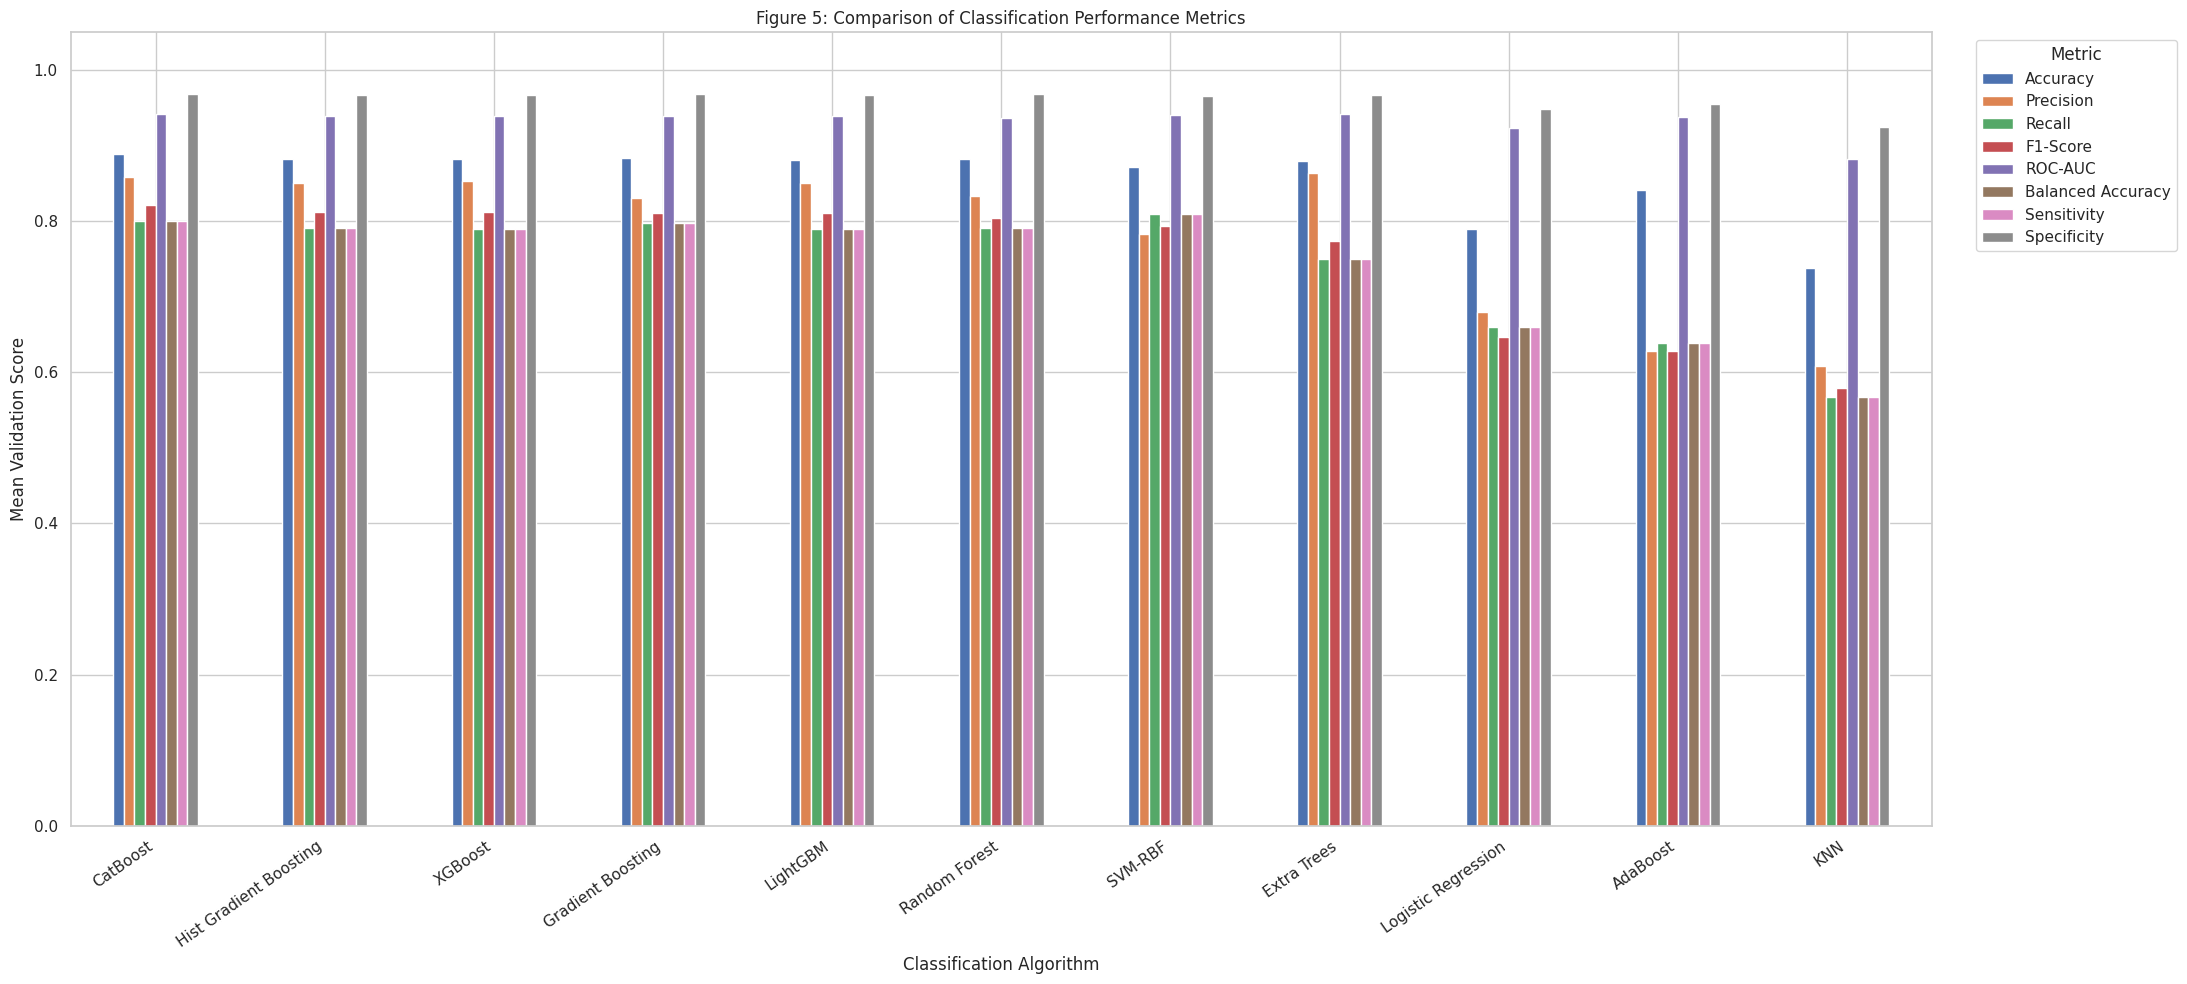

In [33]:
print(
    "\nFigure 5: Comparison of Classification Performance Metrics"
)

metrics_for_plot = [
    "Mean_Accuracy",
    "Mean_Precision",
    "Mean_Recall",
    "Mean_F1",
    "Mean_ROC_AUC",
    "Mean_Balanced_Accuracy",
    "Mean_Sensitivity",
    "Mean_Specificity"
]

plot_data = (
    validation_summary[
        metrics_for_plot
    ]
    .copy()
)

plot_data.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "Sensitivity",
    "Specificity"
]

ax = plot_data.plot(
    kind="bar",
    figsize=(22, 10)
)

plt.title(
    "Figure 5: Comparison of Classification Performance Metrics"
)

plt.xlabel(
    "Classification Algorithm"
)

plt.ylabel(
    "Mean Validation Score"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

ADDITIONAL MODEL PERFORMANCE BAR GRAPHS

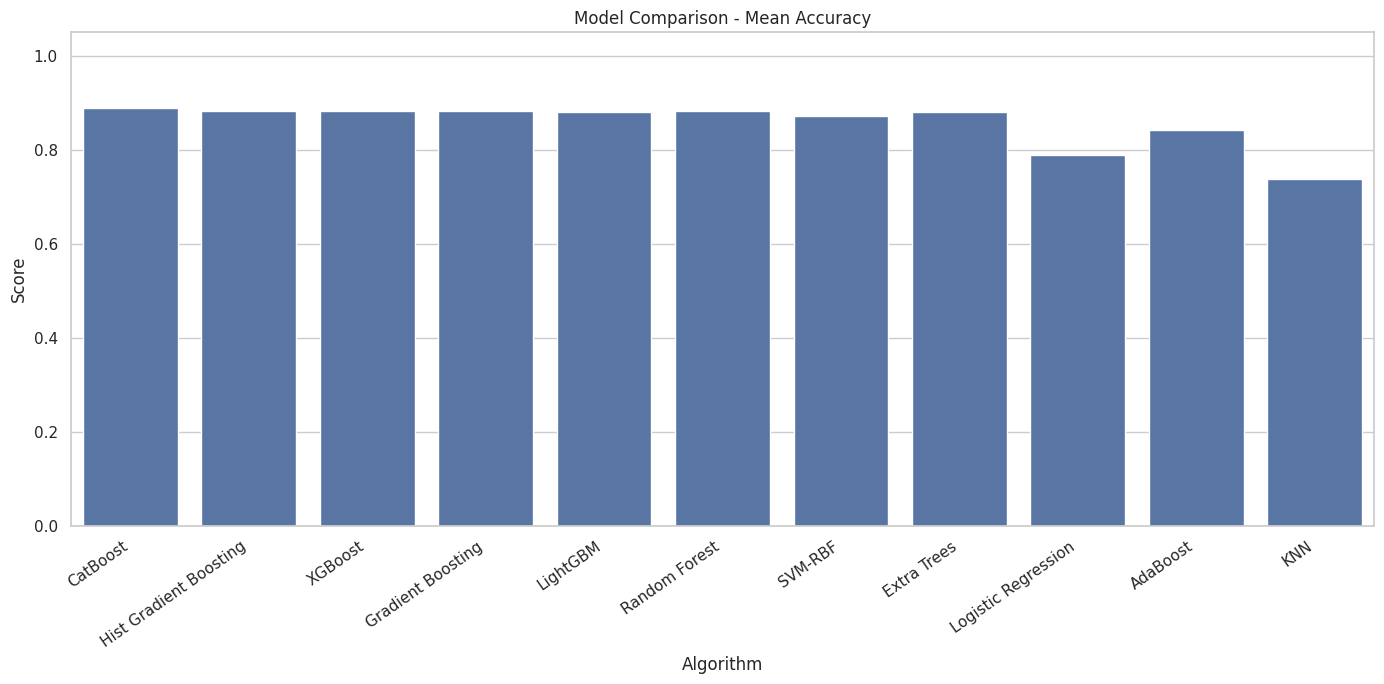

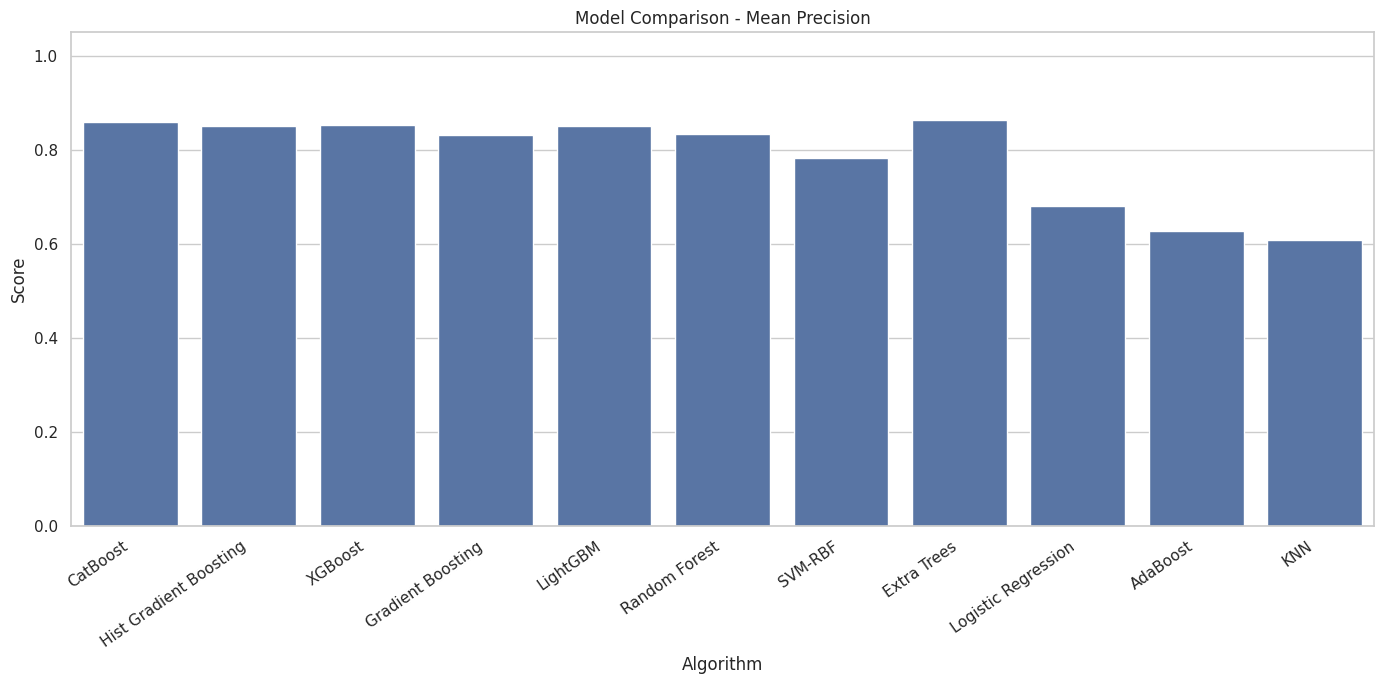

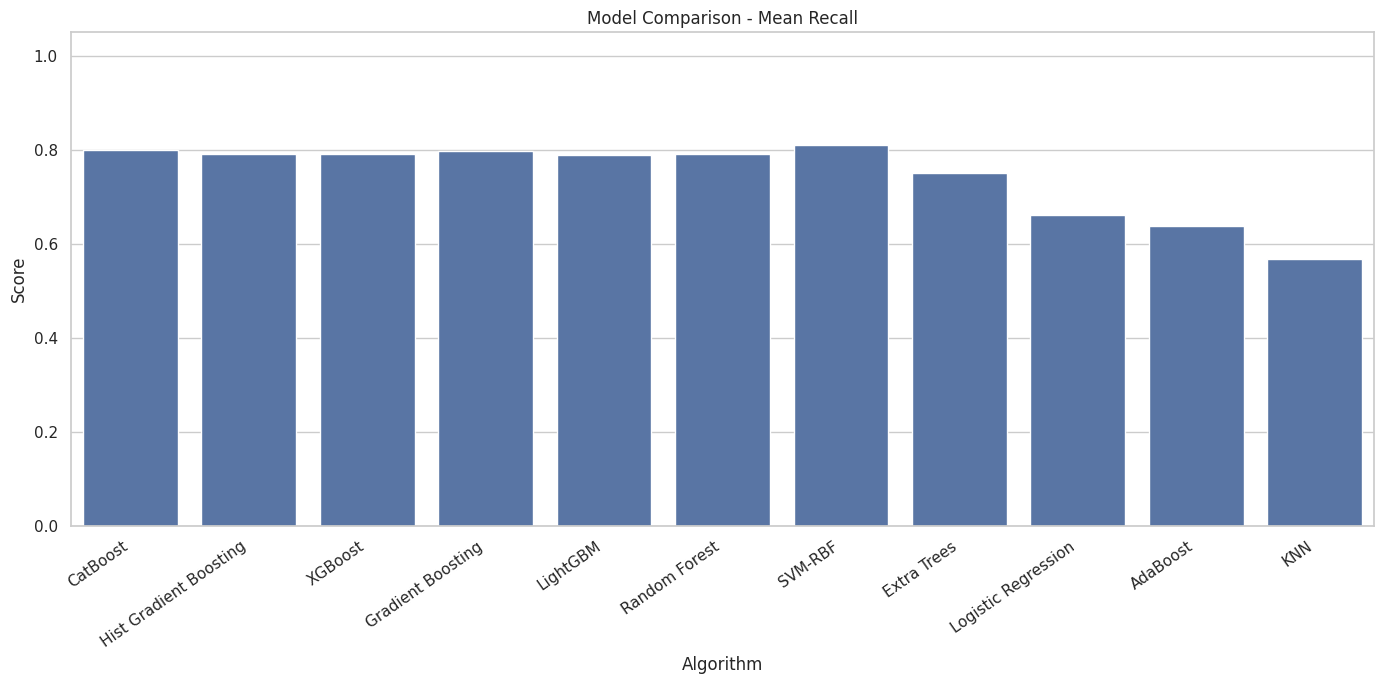

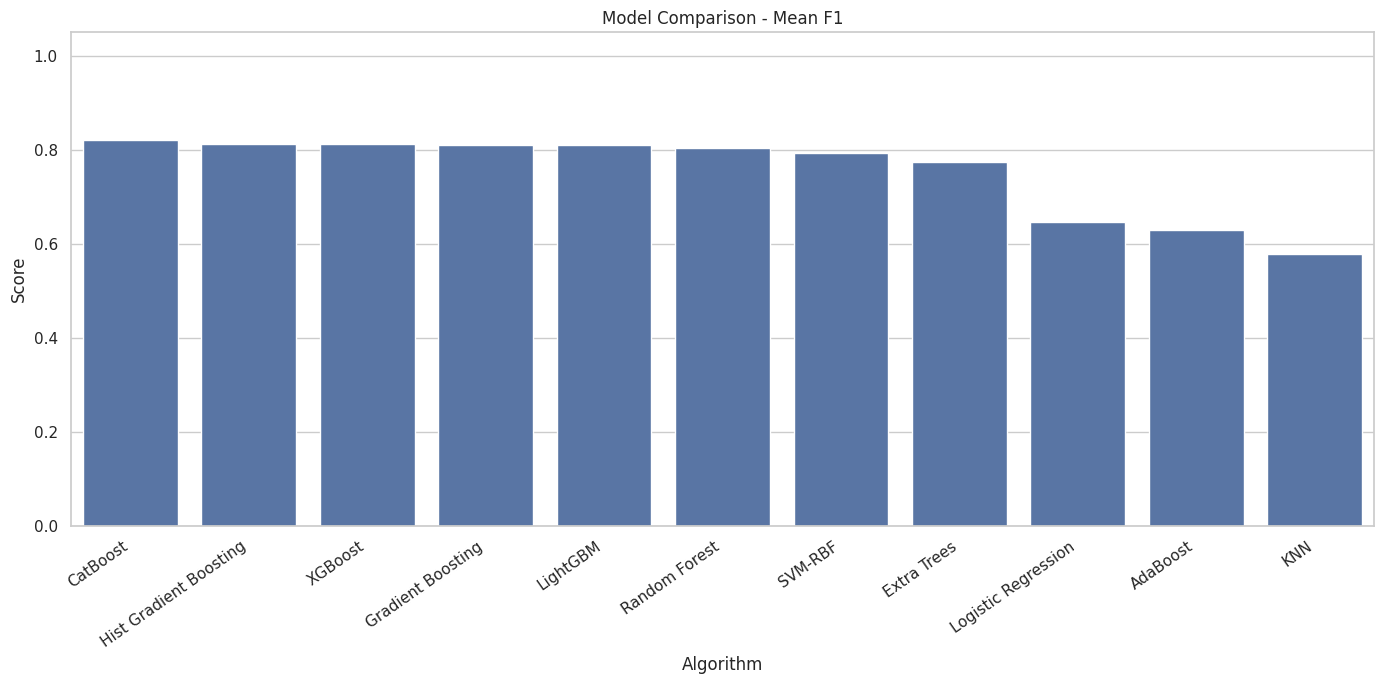

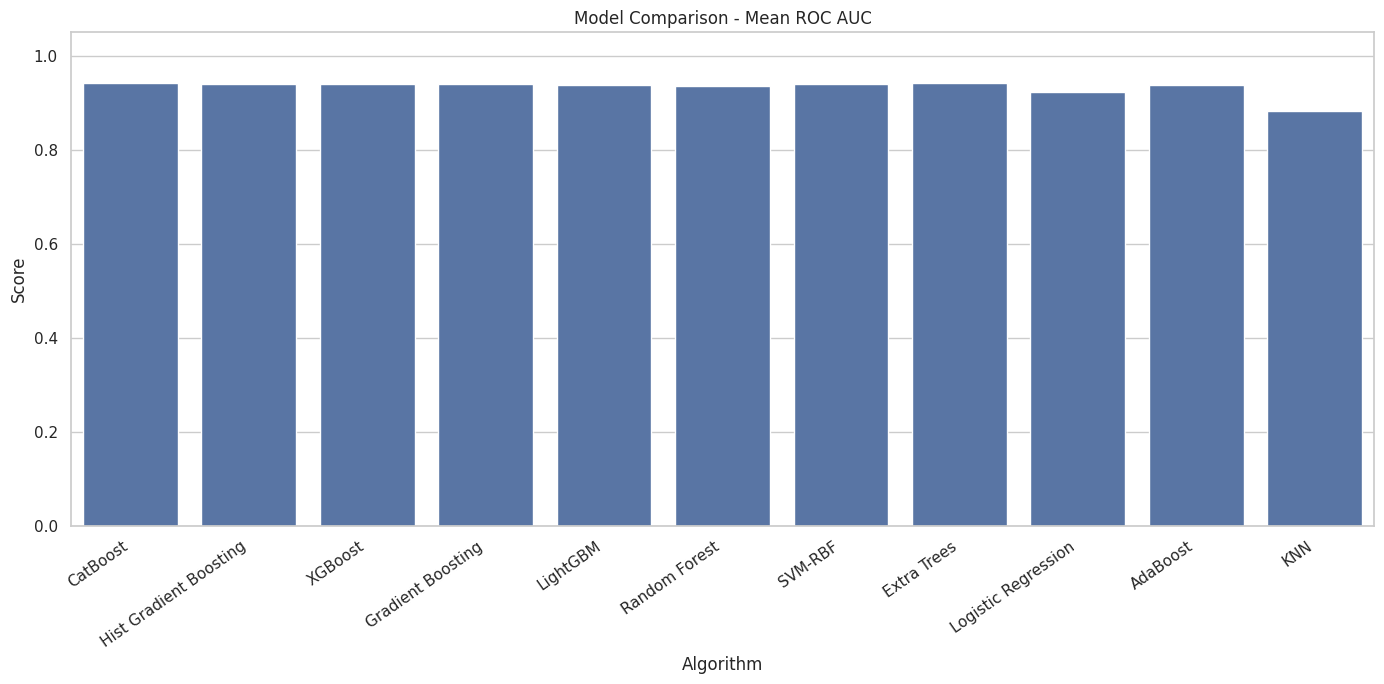

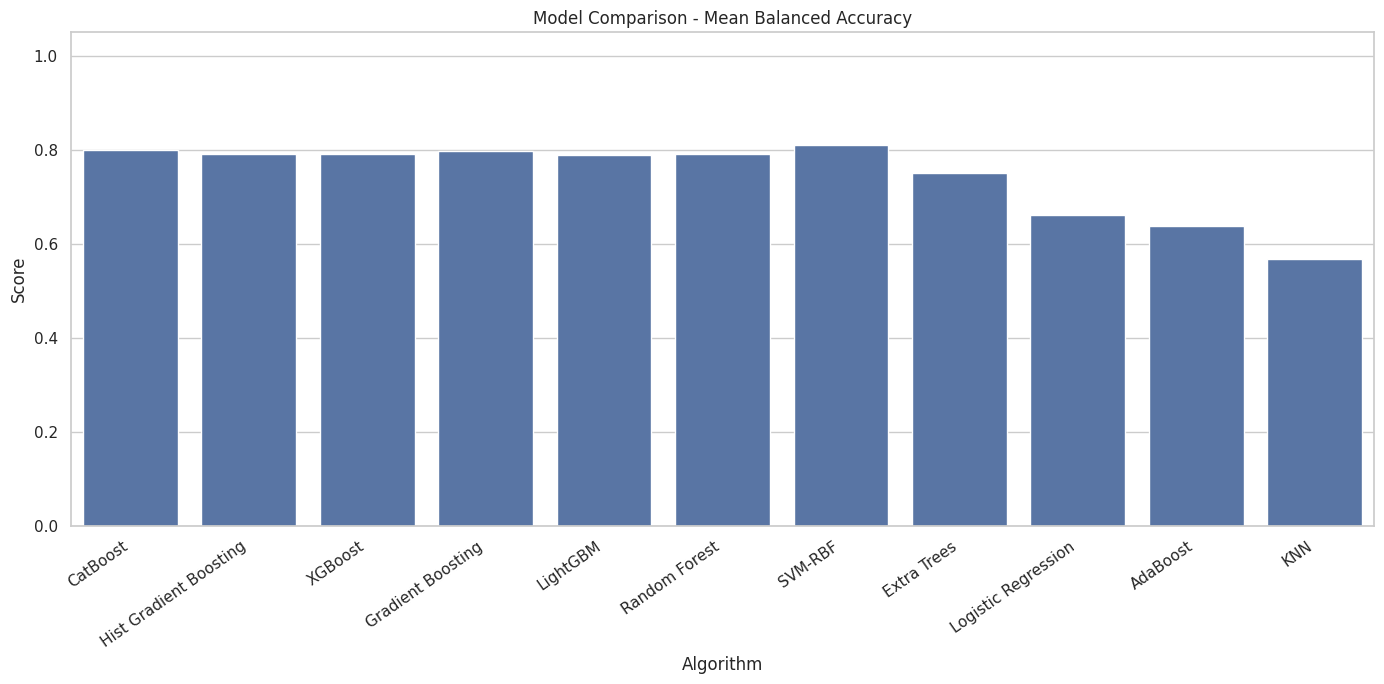

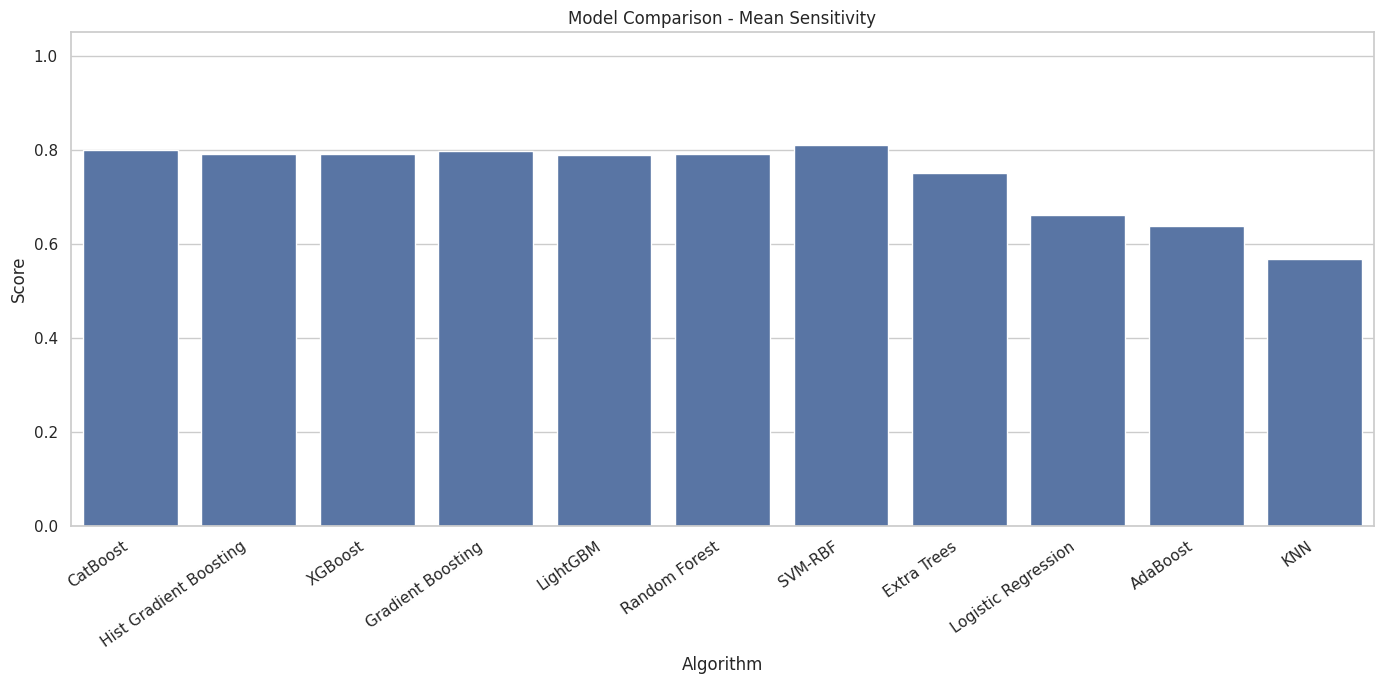

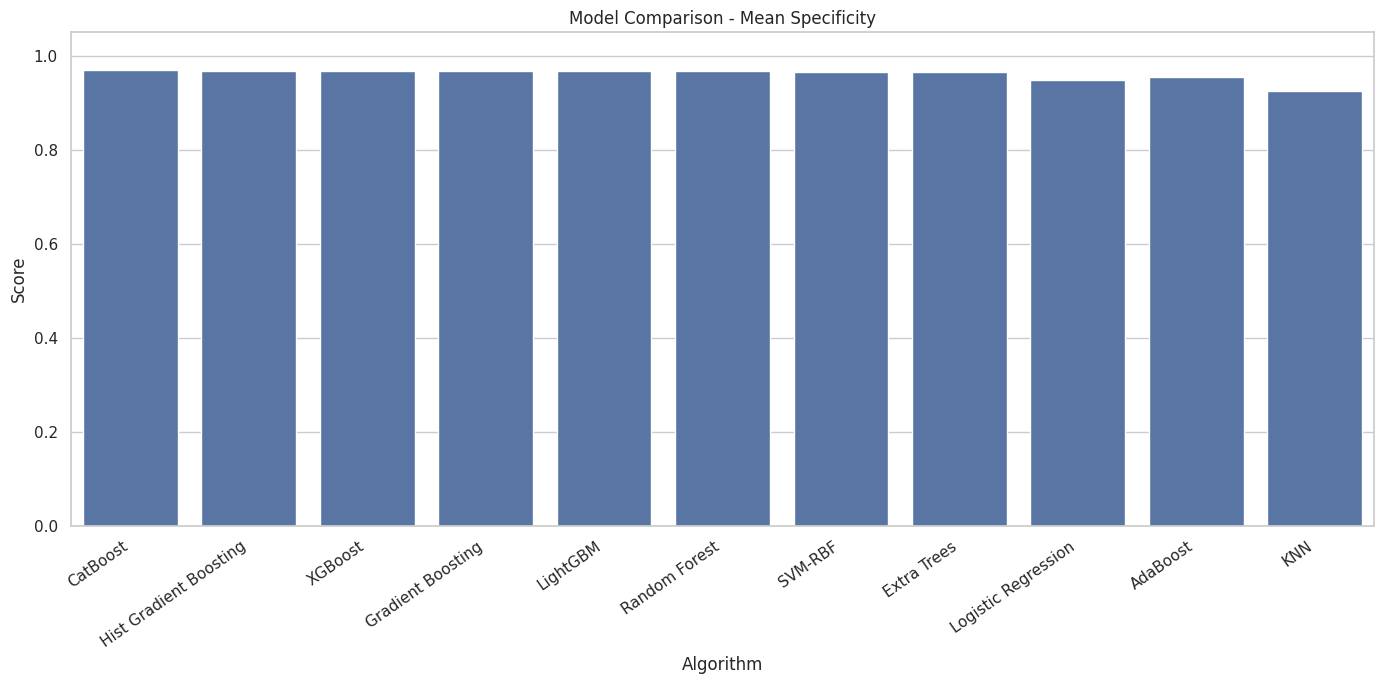

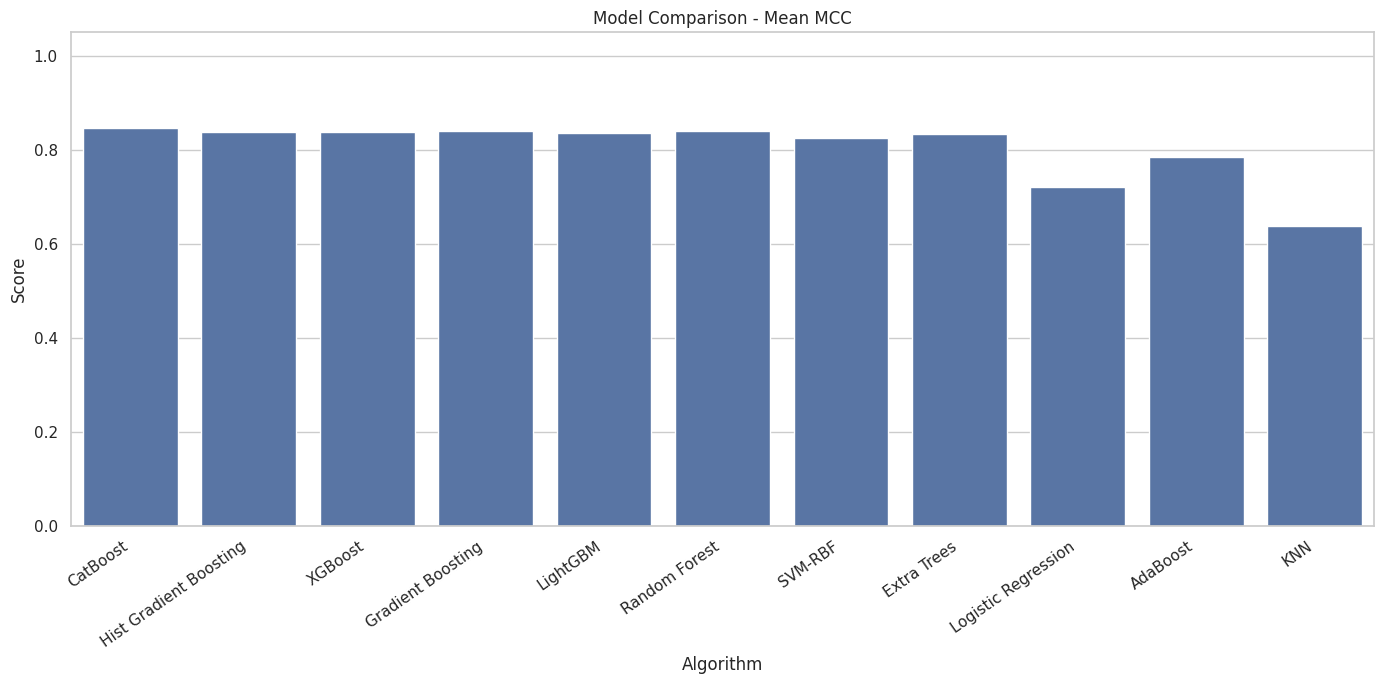

In [34]:
additional_metrics = [
    "Mean_Accuracy",
    "Mean_Precision",
    "Mean_Recall",
    "Mean_F1",
    "Mean_ROC_AUC",
    "Mean_Balanced_Accuracy",
    "Mean_Sensitivity",
    "Mean_Specificity",
    "Mean_MCC"
]

for metric in additional_metrics:

    plt.figure(
        figsize=(14, 7)
    )

    sns.barplot(
        data=validation_summary.reset_index(),
        x="Model",
        y=metric
    )

    plt.title(
        f"Model Comparison - {metric.replace('_', ' ')}"
    )

    plt.xlabel(
        "Algorithm"
    )

    plt.ylabel(
        "Score"
    )

    plt.ylim(
        0,
        1.05
    )

    plt.xticks(
        rotation=35,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

CROSS-VALIDATION PERFORMANCE DISTRIBUTIONS

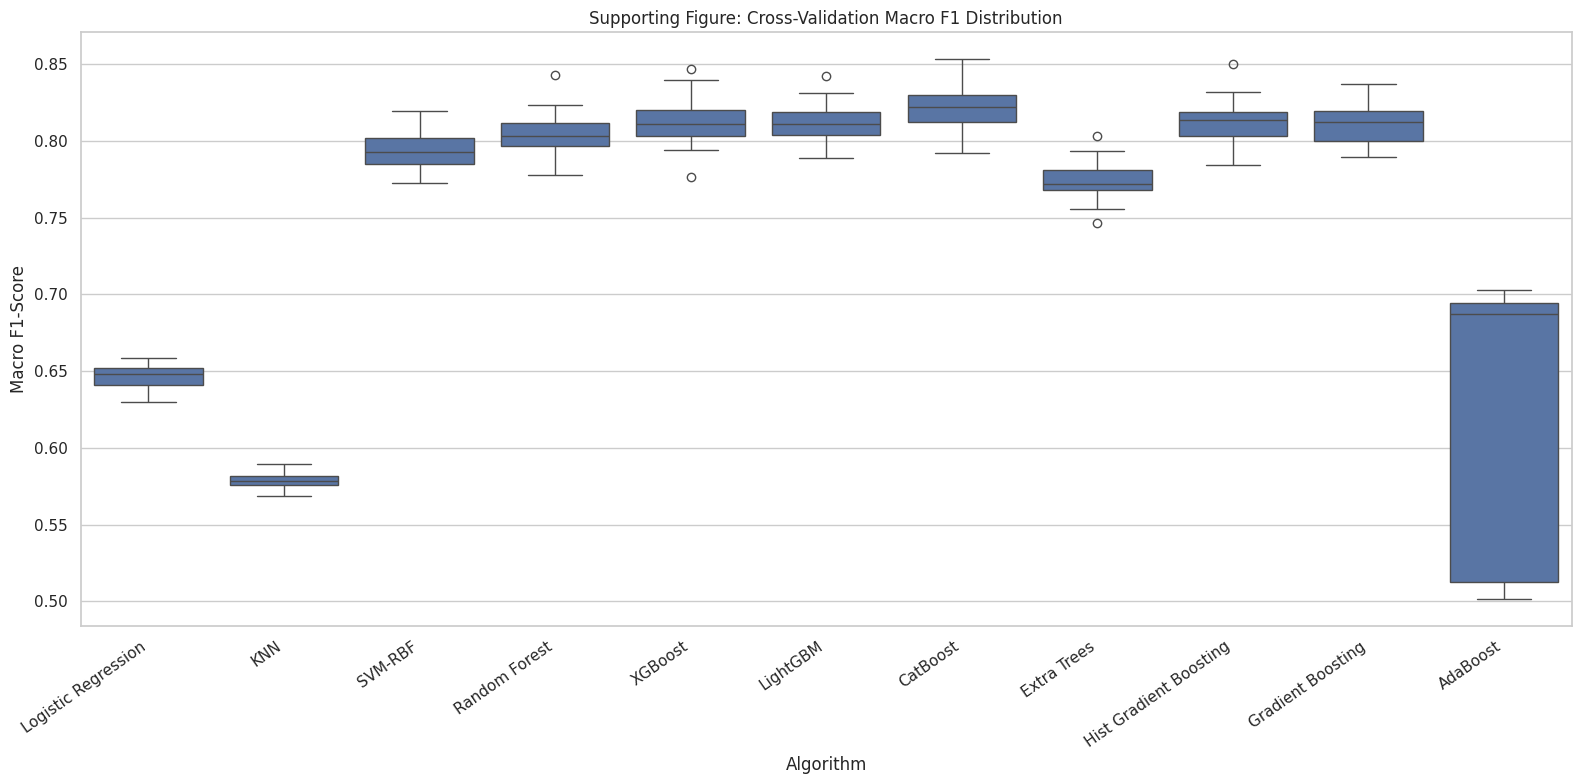

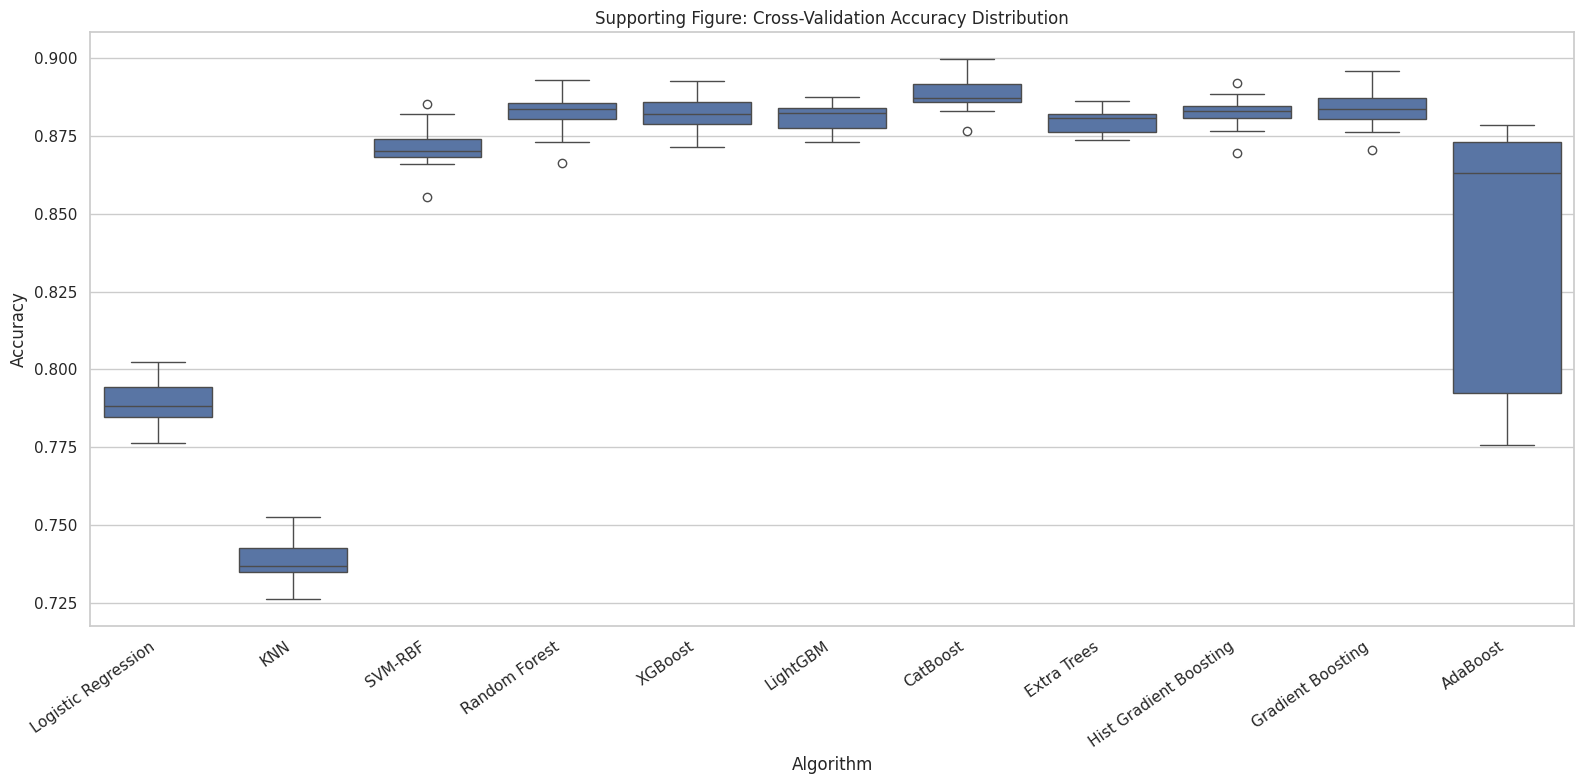

In [35]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=validation_results,
    x="Model",
    y="Macro F1"
)

plt.title(
    "Supporting Figure: Cross-Validation Macro F1 Distribution"
)

plt.xlabel("Algorithm")
plt.ylabel("Macro F1-Score")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 8))

sns.boxplot(
    data=validation_results,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Supporting Figure: Cross-Validation Accuracy Distribution"
)

plt.xlabel("Algorithm")
plt.ylabel("Accuracy")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

CLASS-WISE VALIDATION METRICS

In [36]:
print(
    "\n20. CLASS-WISE VALIDATION METRICS"
)

classwise_records = []

for run in range(
    1,
    VALIDATION_RUNS + 1
):

    for model_name in (
        validation_predictions[
            run
        ].keys()
    ):

        data = (
            validation_predictions[
                run
            ][model_name]
        )

        class_metrics = classwise_metrics(
            data["y_true"],
            data["y_pred"],
            data["probability"],
            model_name
        )

        class_metrics["Run"] = run

        classwise_records.append(
            class_metrics
        )

classwise_validation = pd.concat(
    classwise_records,
    ignore_index=True
)

classwise_summary = (
    classwise_validation
    .groupby(
        ["Model", "Class"]
    )
    .agg(

        Precision=(
            "Precision",
            "mean"
        ),

        Sensitivity=(
            "Sensitivity",
            "mean"
        ),

        Specificity=(
            "Specificity",
            "mean"
        ),

        F1=(
            "F1-Score",
            "mean"
        ),

        ROC_AUC=(
            "ROC-AUC",
            "mean"
        ),

        Support=(
            "Support",
            "mean"
        )
    )
    .reset_index()
)

print(
    "\nTable 5: Class-Wise Performance Comparison"
)

display(
    classwise_summary.style.format(
        {
            "Precision": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}",
            "F1": "{:.4f}",
            "ROC_AUC": "{:.4f}",
            "Support": "{:.2f}"
        }
    )
)


20. CLASS-WISE VALIDATION METRICS

Table 5: Class-Wise Performance Comparison


,Model,Class,Precision,Sensitivity,Specificity,F1,ROC_AUC,Support
0,AdaBoost,0,0.8995,0.9119,0.9681,0.9056,0.9778,733.00
1,AdaBoost,1,0.8863,0.8966,0.9369,0.8914,0.9575,1090.60
2,AdaBoost,2,0.7480,0.9206,0.8766,0.8222,0.9682,840.80
3,AdaBoost,3,0.6057,0.4641,0.9953,0.5247,0.9687,368.60
4,AdaBoost,4,0.0000,0.0000,1.0000,0.0000,0.8202,47.80
5,CatBoost,0,0.9065,0.9065,0.9708,0.9065,0.9825,733.00
6,CatBoost,1,0.8832,0.9017,0.9346,0.8923,0.9727,1090.60
7,CatBoost,2,0.8912,0.8949,0.9590,0.8930,0.9804,840.80
8,CatBoost,3,0.8735,0.8561,0.9831,0.8646,0.9713,368.60
9,CatBoost,4,0.7377,0.4392,0.9975,0.5483,0.8047,47.80


CLASS-WISE F1 COMPARISON

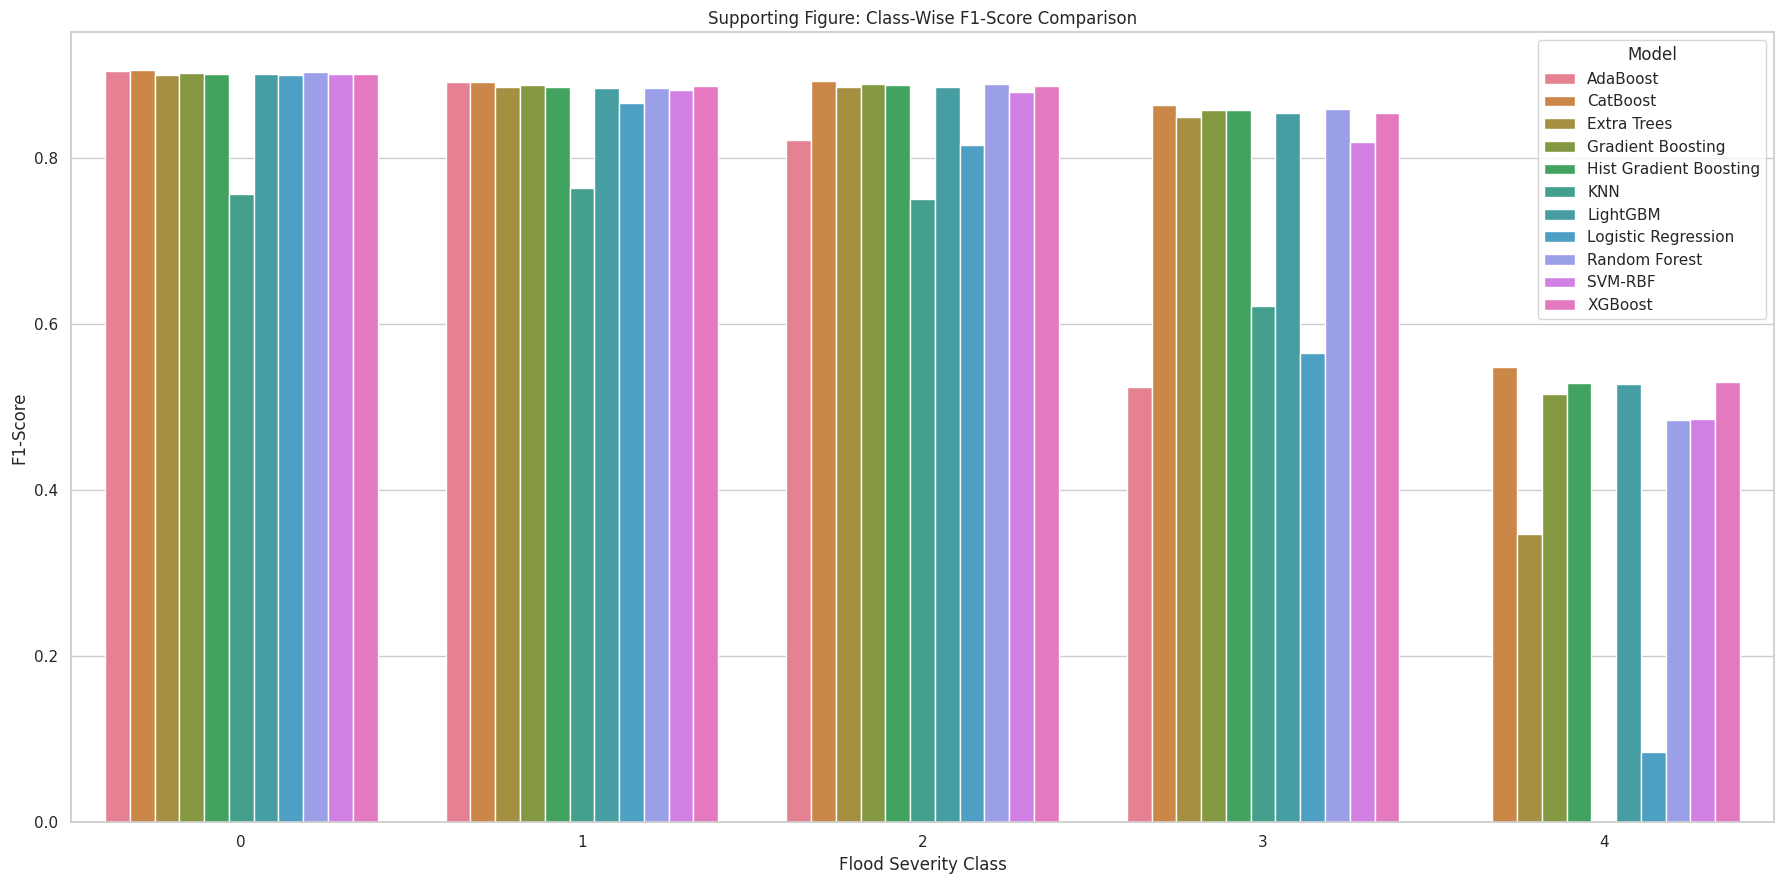

In [37]:
plt.figure(
    figsize=(18, 9)
)

sns.barplot(
    data=classwise_summary,
    x="Class",
    y="F1",
    hue="Model"
)

plt.title(
    "Supporting Figure: Class-Wise F1-Score Comparison"
)

plt.xlabel(
    "Flood Severity Class"
)

plt.ylabel(
    "F1-Score"
)

plt.tight_layout()
plt.show()

CLASS-WISE SENSITIVITY COMPARISON

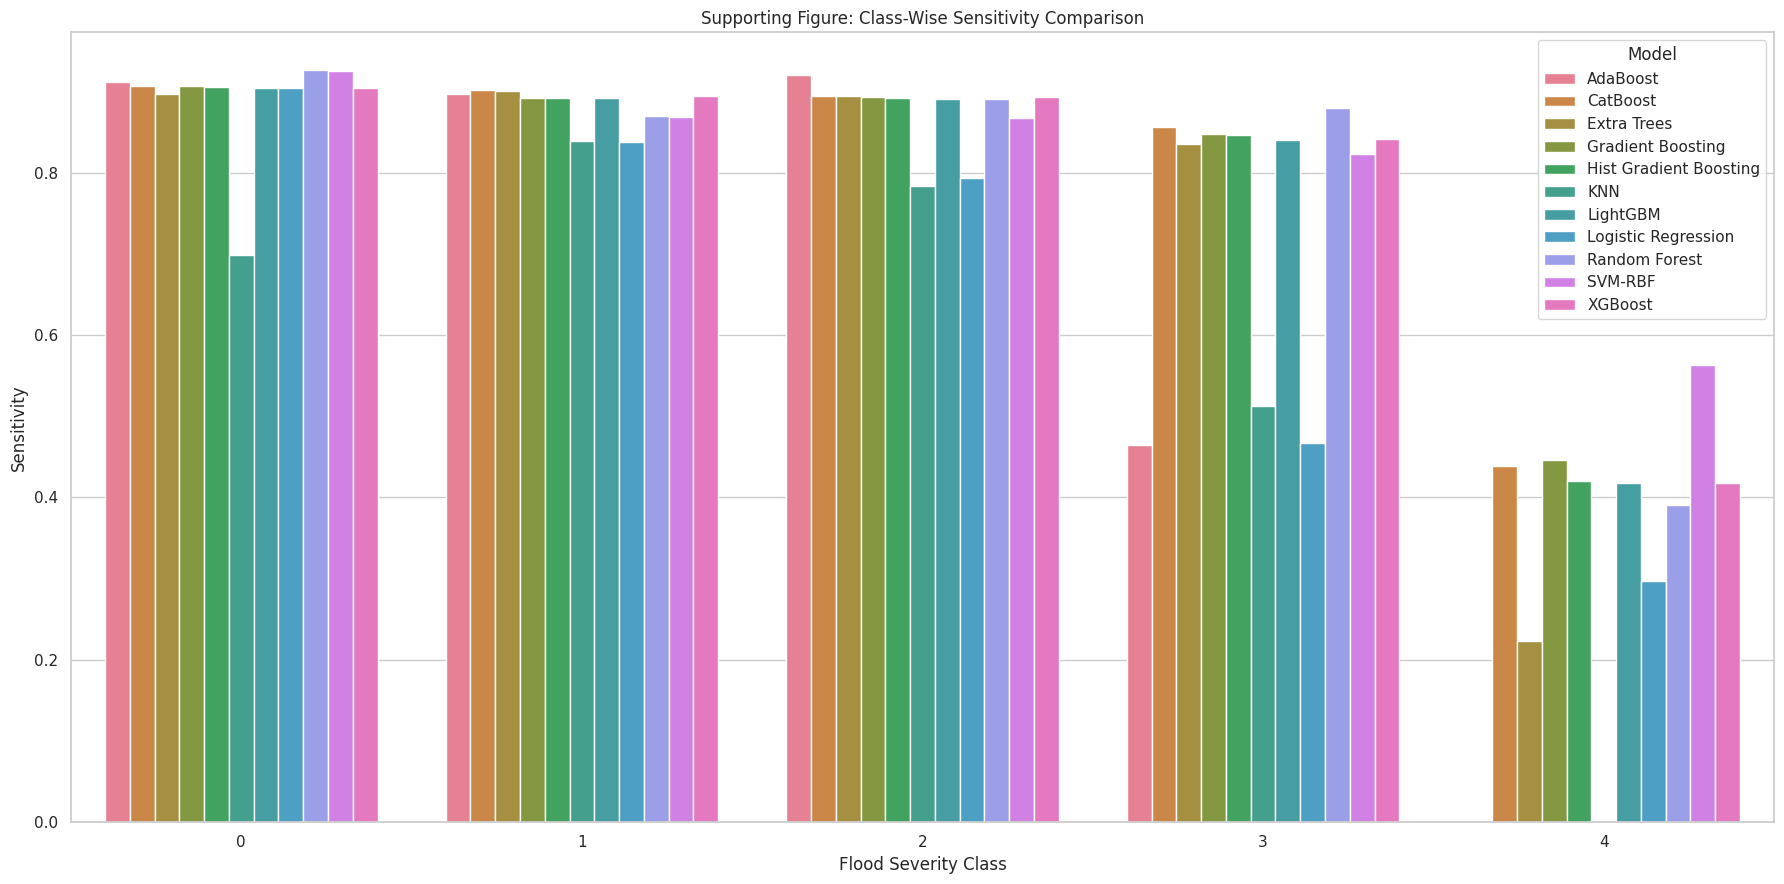

In [38]:
plt.figure(
    figsize=(18, 9)
)

sns.barplot(
    data=classwise_summary,
    x="Class",
    y="Sensitivity",
    hue="Model"
)

plt.title(
    "Supporting Figure: Class-Wise Sensitivity Comparison"
)

plt.xlabel(
    "Flood Severity Class"
)

plt.ylabel(
    "Sensitivity"
)

plt.tight_layout()
plt.show()

CLASS-WISE SPECIFICITY COMPARISON

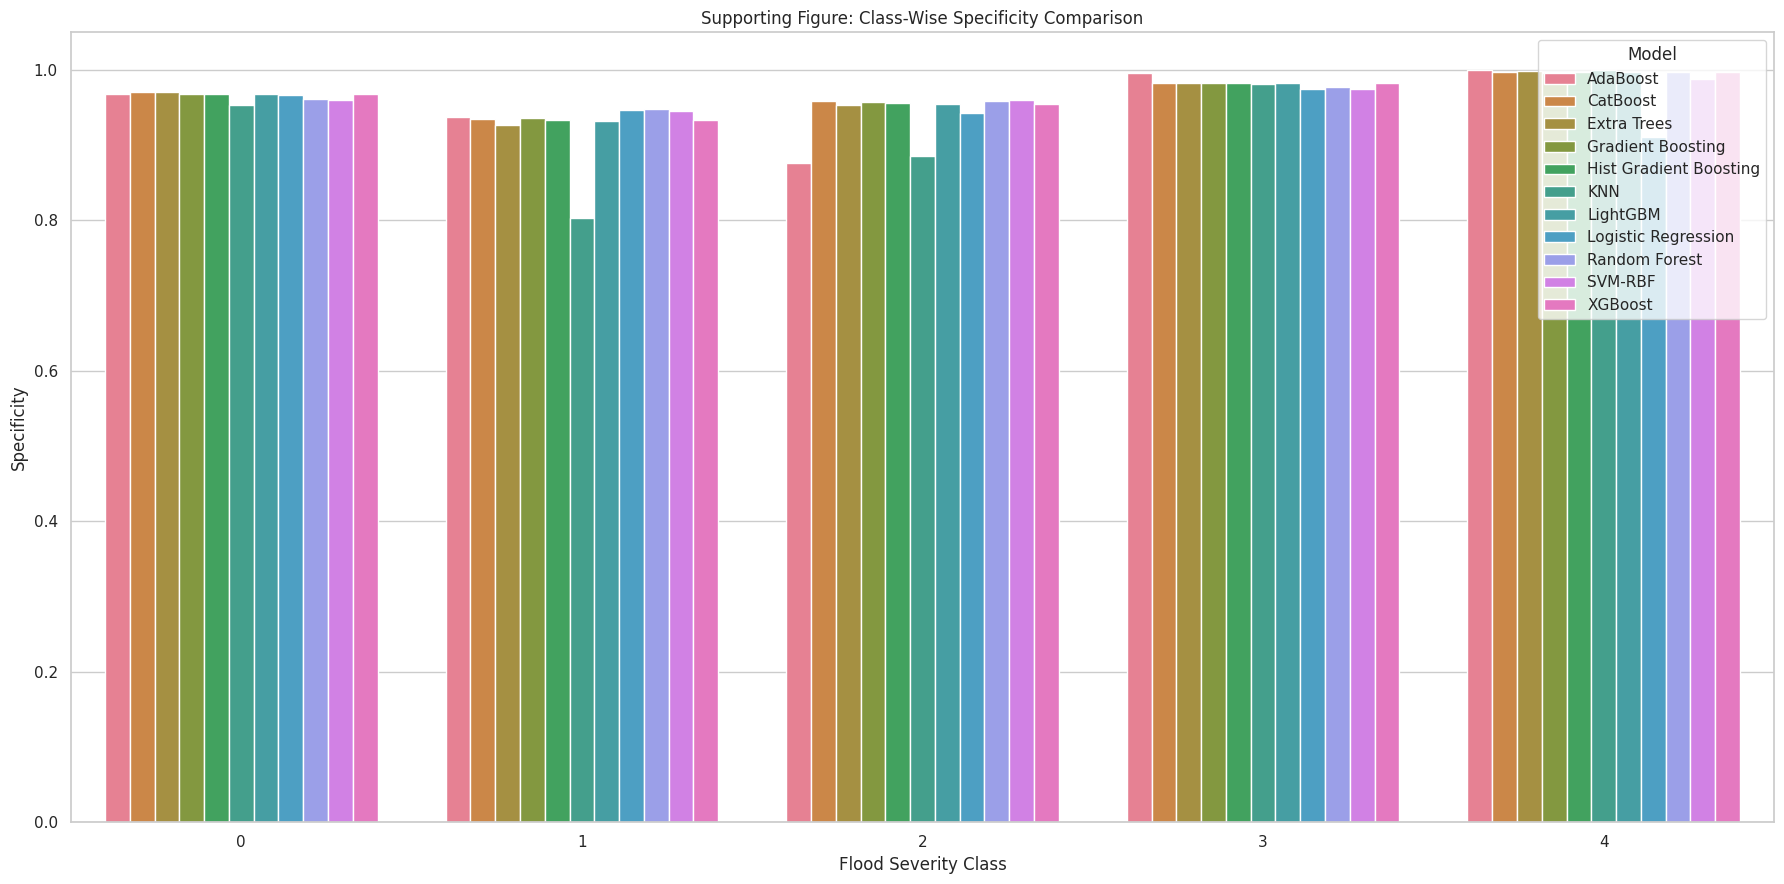

In [39]:
plt.figure(
    figsize=(18, 9)
)

sns.barplot(
    data=classwise_summary,
    x="Class",
    y="Specificity",
    hue="Model"
)

plt.title(
    "Supporting Figure: Class-Wise Specificity Comparison"
)

plt.xlabel(
    "Flood Severity Class"
)

plt.ylabel(
    "Specificity"
)

plt.tight_layout()
plt.show()

FIGURE 6: MULTICLASS ROC CURVES AND AUC COMPARISON


Figure 6: Receiver Operating Characteristic (ROC) Curve and AUC Comparison


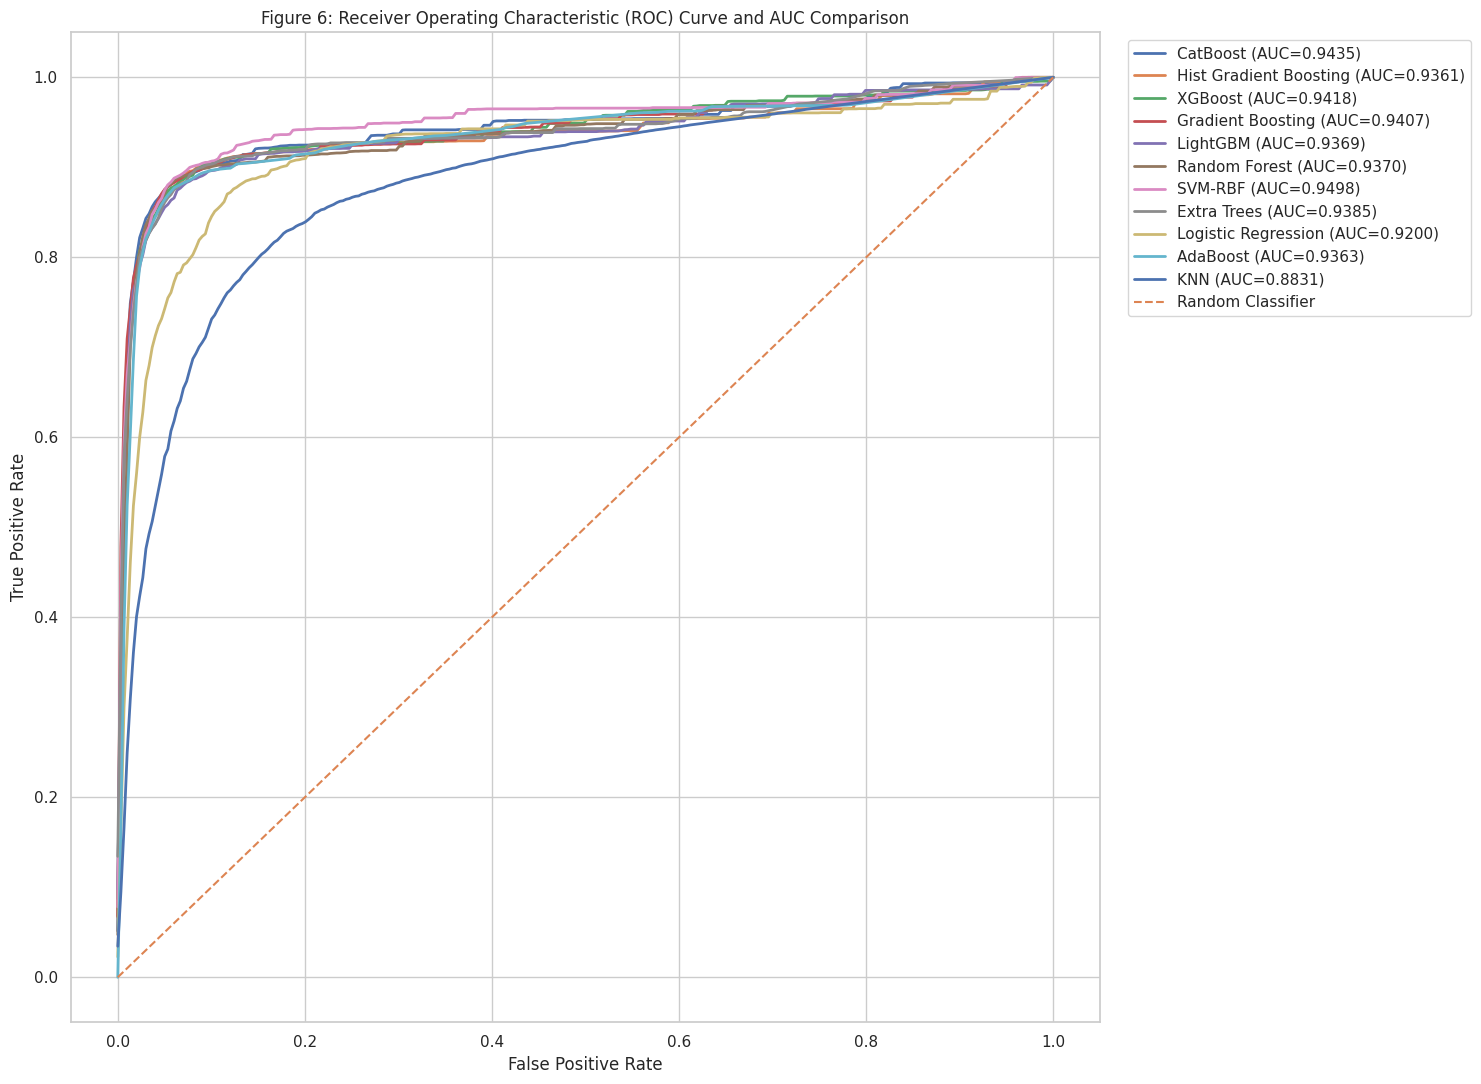

In [40]:
print(
    "\nFigure 6: Receiver Operating Characteristic (ROC) Curve and AUC Comparison"
)

plt.figure(
    figsize=(15, 11)
)

for model_name in validation_summary.index:

    model_rows = validation_results[
        validation_results["Model"]
        == model_name
    ]

    best_run = int(
        model_rows
        .sort_values(
            "Macro F1",
            ascending=False
        )
        .iloc[0]["Run"]
    )

    run_data = (
        validation_predictions[
            best_run
        ][model_name]
    )

    y_true_run = (
        run_data["y_true"]
    )

    y_prob_run = (
        run_data["probability"]
    )

    if y_prob_run is None:
        continue

    y_binary = label_binarize(
        y_true_run,
        classes=classes
    )

    all_fpr = np.linspace(
        0,
        1,
        300
    )

    mean_tpr = np.zeros_like(
        all_fpr
    )

    class_auc_values = []

    for i, class_label in enumerate(
        classes
    ):

        fpr, tpr, _ = roc_curve(
            y_binary[:, i],
            y_prob_run[:, i]
        )

        class_auc = auc(
            fpr,
            tpr
        )

        class_auc_values.append(
            class_auc
        )

        mean_tpr += np.interp(
            all_fpr,
            fpr,
            tpr
        )

    mean_tpr /= len(classes)

    macro_auc = np.mean(
        class_auc_values
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC={macro_auc:.4f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "Figure 6: Receiver Operating Characteristic (ROC) Curve and AUC Comparison"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

CLASS-SPECIFIC ROC CURVES

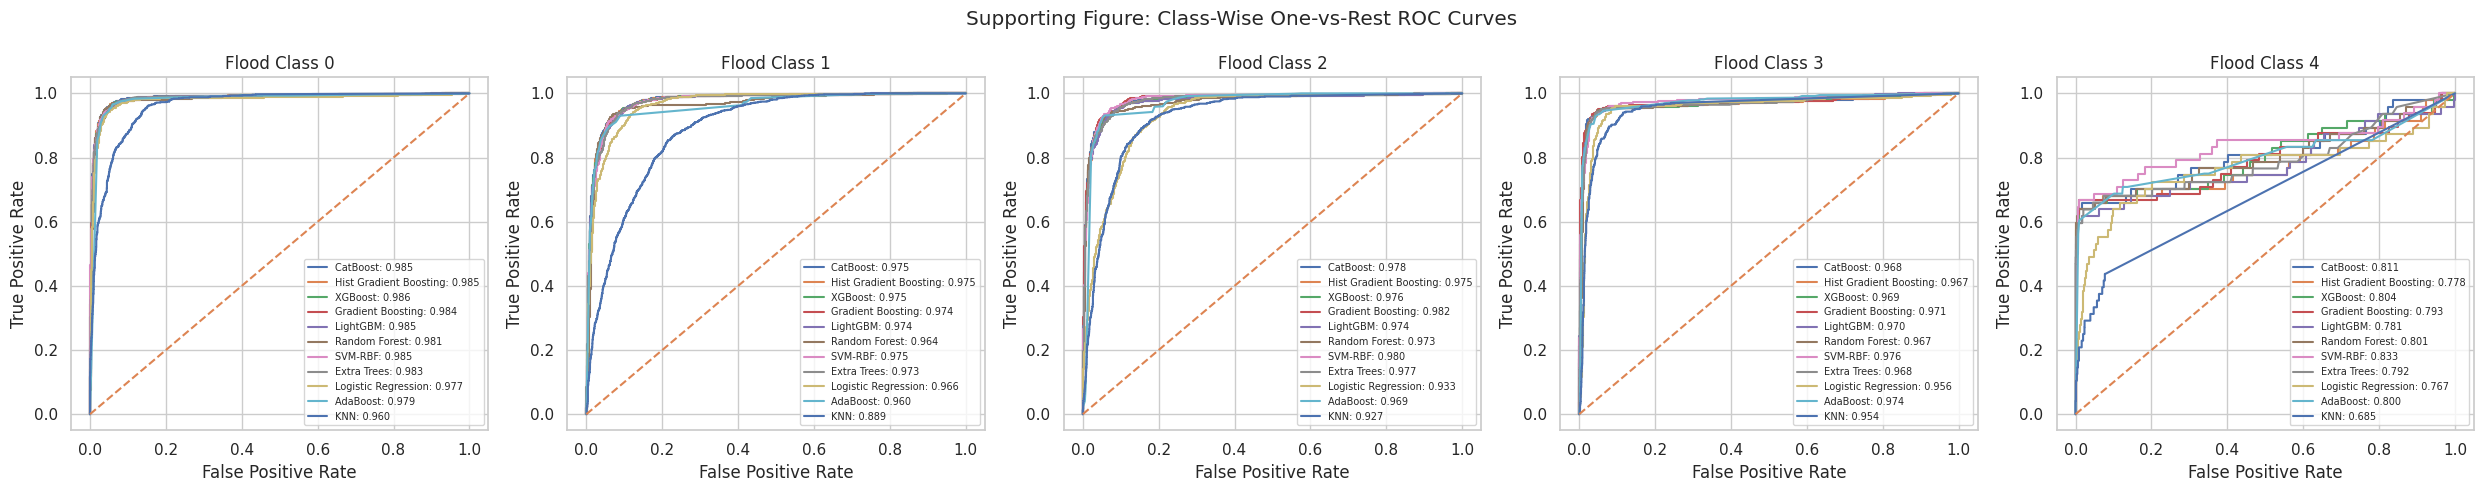

In [41]:
fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(5 * len(classes), 5)
)

if len(classes) == 1:
    axes = [axes]

for class_index, class_label in enumerate(
    classes
):

    ax = axes[class_index]

    for model_name in validation_summary.index:

        model_rows = validation_results[
            validation_results["Model"]
            == model_name
        ]

        best_run = int(
            model_rows
            .sort_values(
                "Macro F1",
                ascending=False
            )
            .iloc[0]["Run"]
        )

        data = (
            validation_predictions[
                best_run
            ][model_name]
        )

        if data["probability"] is None:
            continue

        binary_true = (
            data["y_true"]
            == class_label
        ).astype(int)

        fpr, tpr, _ = roc_curve(
            binary_true,
            data["probability"][
                :,
                class_index
            ]
        )

        model_auc = auc(
            fpr,
            tpr
        )

        ax.plot(
            fpr,
            tpr,
            label=(
                f"{model_name}: "
                f"{model_auc:.3f}"
            )
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_title(
        f"Flood Class {class_label}"
    )

    ax.set_xlabel(
        "False Positive Rate"
    )

    ax.set_ylabel(
        "True Positive Rate"
    )

    ax.legend(
        fontsize=7
    )

plt.suptitle(
    "Supporting Figure: Class-Wise One-vs-Rest ROC Curves"
)

plt.tight_layout()
plt.show()

FIGURE 7: MODEL PREDICTION OUTPUT COMPARISON


Figure 7: Comparison of Model Prediction Outputs


,Sample,Actual,CatBoost,Hist Gradient Boosting,XGBoost,Gradient Boosting,LightGBM,Random Forest,SVM-RBF,Extra Trees,Logistic Regression,AdaBoost,KNN
0,1,1,1,2,2,1,2,1,1,1,2,1,1
1,2,2,2,2,2,2,2,2,2,2,2,2,2
2,3,1,1,1,1,1,1,1,1,1,1,1,1
3,4,1,1,1,1,1,1,1,1,1,1,1,1
4,5,0,0,0,0,0,0,0,0,0,0,0,0
5,6,1,3,3,3,3,3,3,4,3,3,2,3
6,7,1,1,1,1,1,1,1,1,1,1,1,1
7,8,1,1,1,1,1,1,1,1,1,1,1,1
8,9,1,1,1,1,1,1,1,1,1,1,1,1
9,10,0,0,0,0,0,0,0,0,0,0,0,1


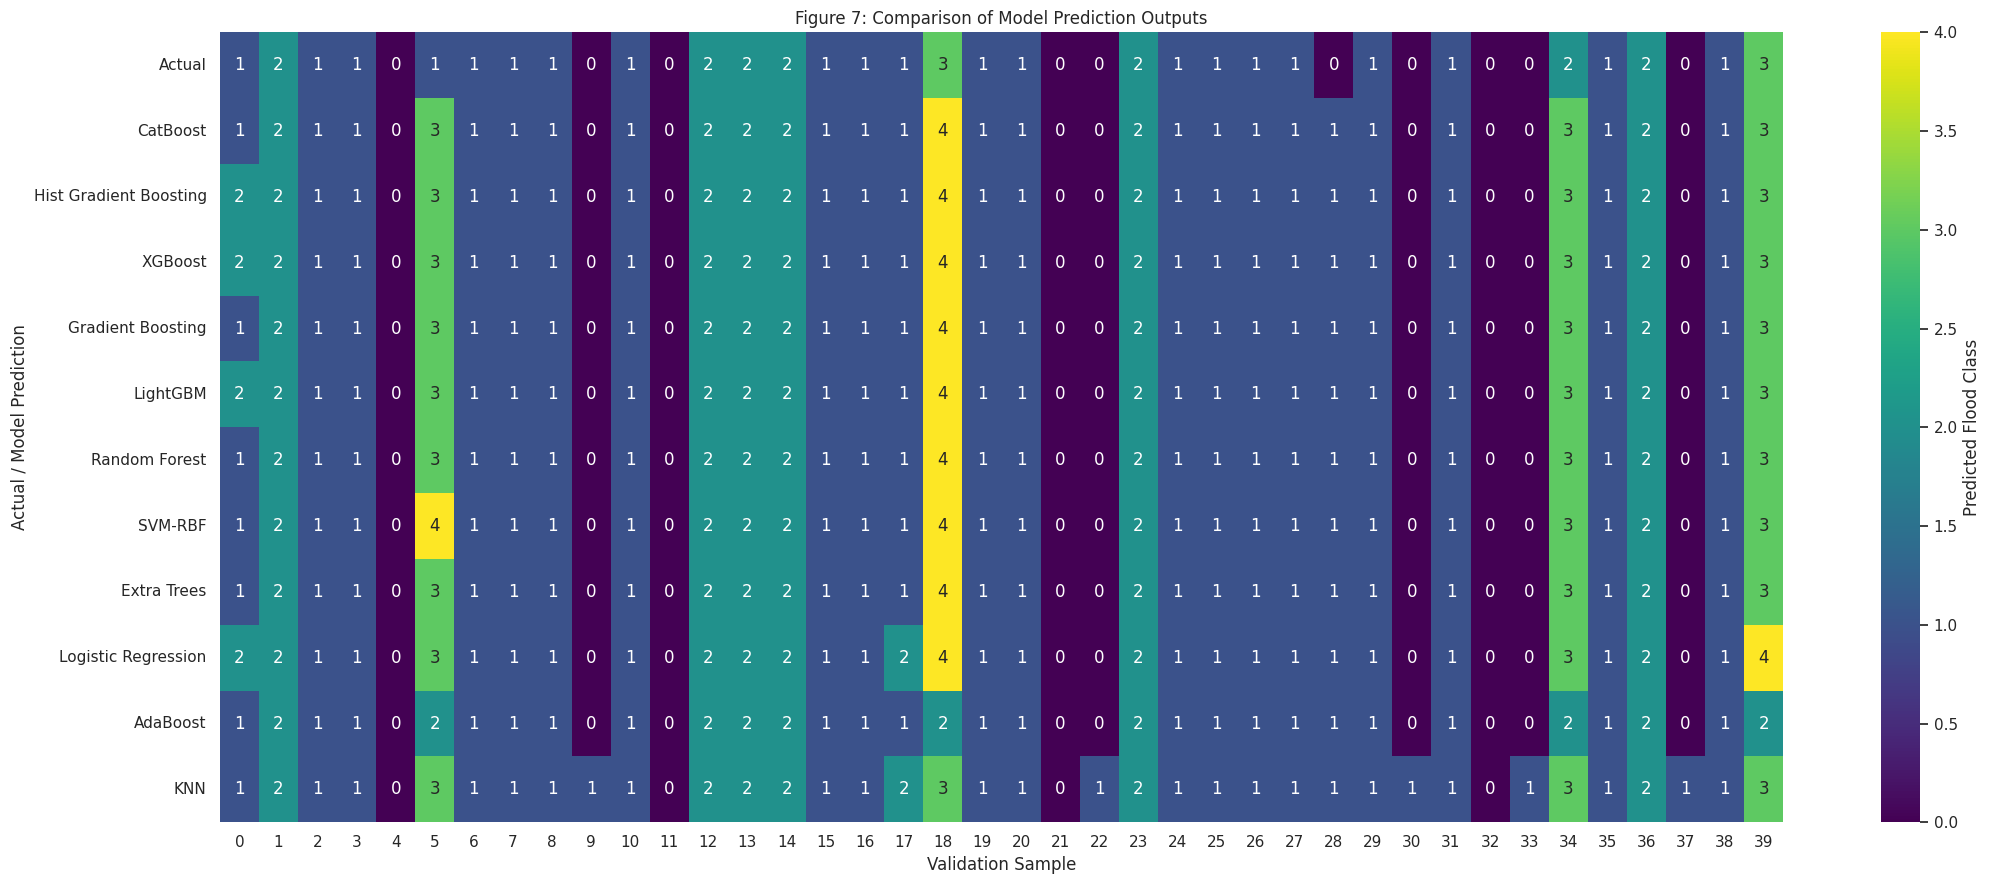

In [42]:
print(
    "\nFigure 7: Comparison of Model Prediction Outputs"
)

prediction_run = 1

run_predictions = (
    validation_predictions[
        prediction_run
    ]
)

first_model = next(
    iter(
        run_predictions.values()
    )
)

prediction_length = min(
    40,
    len(
        first_model["y_true"]
    )
)

prediction_table = pd.DataFrame({

    "Sample":
        np.arange(
            1,
            prediction_length + 1
        ),

    "Actual":
        first_model[
            "y_true"
        ][:prediction_length]
})

for model_name in validation_summary.index:

    prediction_table[
        model_name
    ] = (
        run_predictions[
            model_name
        ]["y_pred"]
        [:prediction_length]
    )

display(
    prediction_table
)

heatmap_data = (
    prediction_table
    .drop(
        columns=["Sample"]
    )
    .T
)

plt.figure(
    figsize=(22, 9)
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="g",
    cmap="viridis",
    cbar_kws={
        "label":
        "Predicted Flood Class"
    }
)

plt.title(
    "Figure 7: Comparison of Model Prediction Outputs"
)

plt.xlabel(
    "Validation Sample"
)

plt.ylabel(
    "Actual / Model Prediction"
)

plt.tight_layout()
plt.show()

FIGURE 8: MODEL PREDICTION CORRELATION


Figure 8: Correlation Analysis Between Machine Learning Models

Pearson Correlation Between Model Predictions:


,CatBoost,Hist Gradient Boosting,XGBoost,Gradient Boosting,LightGBM,Random Forest,SVM-RBF,Extra Trees,Logistic Regression,AdaBoost,KNN
CatBoost,1.000000,0.985028,0.986585,0.976928,0.982323,0.981237,0.956285,0.977167,0.927141,0.931725,0.876884
Hist Gradient Boosting,0.985028,1.000000,0.986141,0.973222,0.984518,0.981391,0.952391,0.974425,0.925162,0.925211,0.876626
XGBoost,0.986585,0.986141,1.000000,0.975708,0.987070,0.979495,0.952740,0.976149,0.927933,0.926541,0.877376
Gradient Boosting,0.976928,0.973222,0.975708,1.000000,0.972861,0.970141,0.942477,0.963821,0.917498,0.919334,0.866871
LightGBM,0.982323,0.984518,0.987070,0.972861,1.000000,0.977855,0.950992,0.974887,0.922603,0.923967,0.876448
Random Forest,0.981237,0.981391,0.979495,0.970141,0.977855,1.000000,0.958269,0.970163,0.931217,0.923159,0.874050
SVM-RBF,0.956285,0.952391,0.952740,0.942477,0.950992,0.958269,1.000000,0.946755,0.913582,0.894390,0.856080
Extra Trees,0.977167,0.974425,0.976149,0.963821,0.974887,0.970163,0.946755,1.000000,0.924896,0.923974,0.882607
Logistic Regression,0.927141,0.925162,0.927933,0.917498,0.922603,0.931217,0.913582,0.924896,1.000000,0.873945,0.846442
AdaBoost,0.931725,0.925211,0.926541,0.919334,0.923967,0.923159,0.894390,0.923974,0.873945,1.000000,0.833181



Spearman Correlation Between Model Predictions:


,CatBoost,Hist Gradient Boosting,XGBoost,Gradient Boosting,LightGBM,Random Forest,SVM-RBF,Extra Trees,Logistic Regression,AdaBoost,KNN
CatBoost,1.000000,0.985140,0.986939,0.982485,0.982771,0.982082,0.968402,0.979189,0.956336,0.969067,0.879495
Hist Gradient Boosting,0.985140,1.000000,0.986770,0.978560,0.984358,0.982934,0.965547,0.976062,0.955184,0.960652,0.878490
XGBoost,0.986939,0.986770,1.000000,0.980992,0.987949,0.980809,0.965521,0.978098,0.957522,0.961173,0.879784
Gradient Boosting,0.982485,0.978560,0.980992,1.000000,0.978073,0.976509,0.959516,0.971512,0.952103,0.961337,0.874026
LightGBM,0.982771,0.984358,0.987949,0.978073,1.000000,0.979411,0.962987,0.975997,0.953525,0.961187,0.878319
Random Forest,0.982082,0.982934,0.980809,0.976509,0.979411,1.000000,0.970391,0.972172,0.957920,0.957447,0.876604
SVM-RBF,0.968402,0.965547,0.965521,0.959516,0.962987,0.970391,1.000000,0.960337,0.947593,0.944128,0.866341
Extra Trees,0.979189,0.976062,0.978098,0.971512,0.975997,0.972172,0.960337,1.000000,0.952072,0.955981,0.885067
Logistic Regression,0.956336,0.955184,0.957522,0.952103,0.953525,0.957920,0.947593,0.952072,1.000000,0.936618,0.868019
AdaBoost,0.969067,0.960652,0.961173,0.961337,0.961187,0.957447,0.944128,0.955981,0.936618,1.000000,0.859934


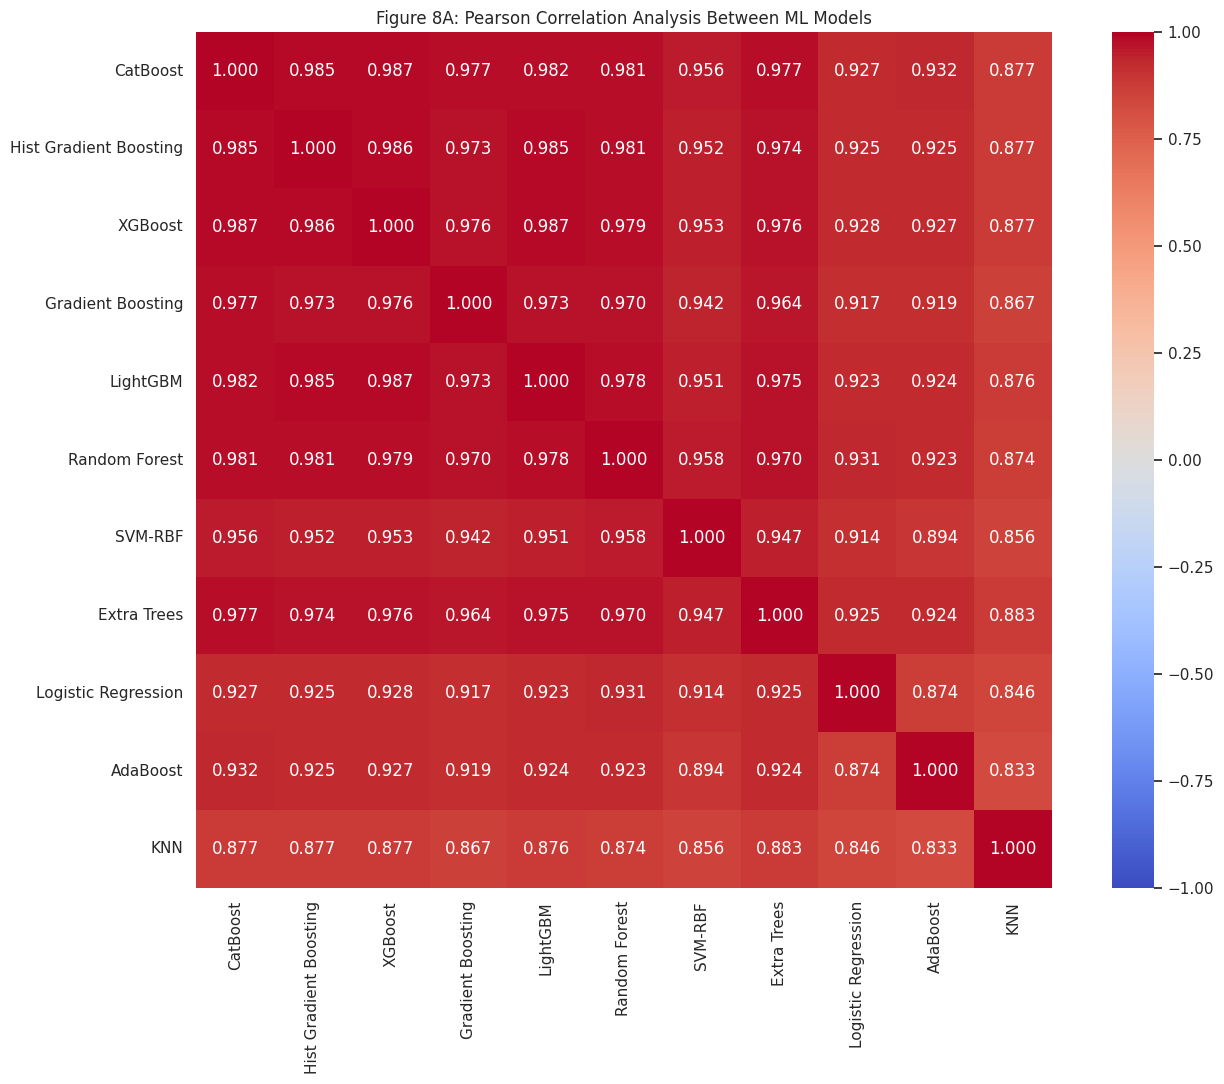

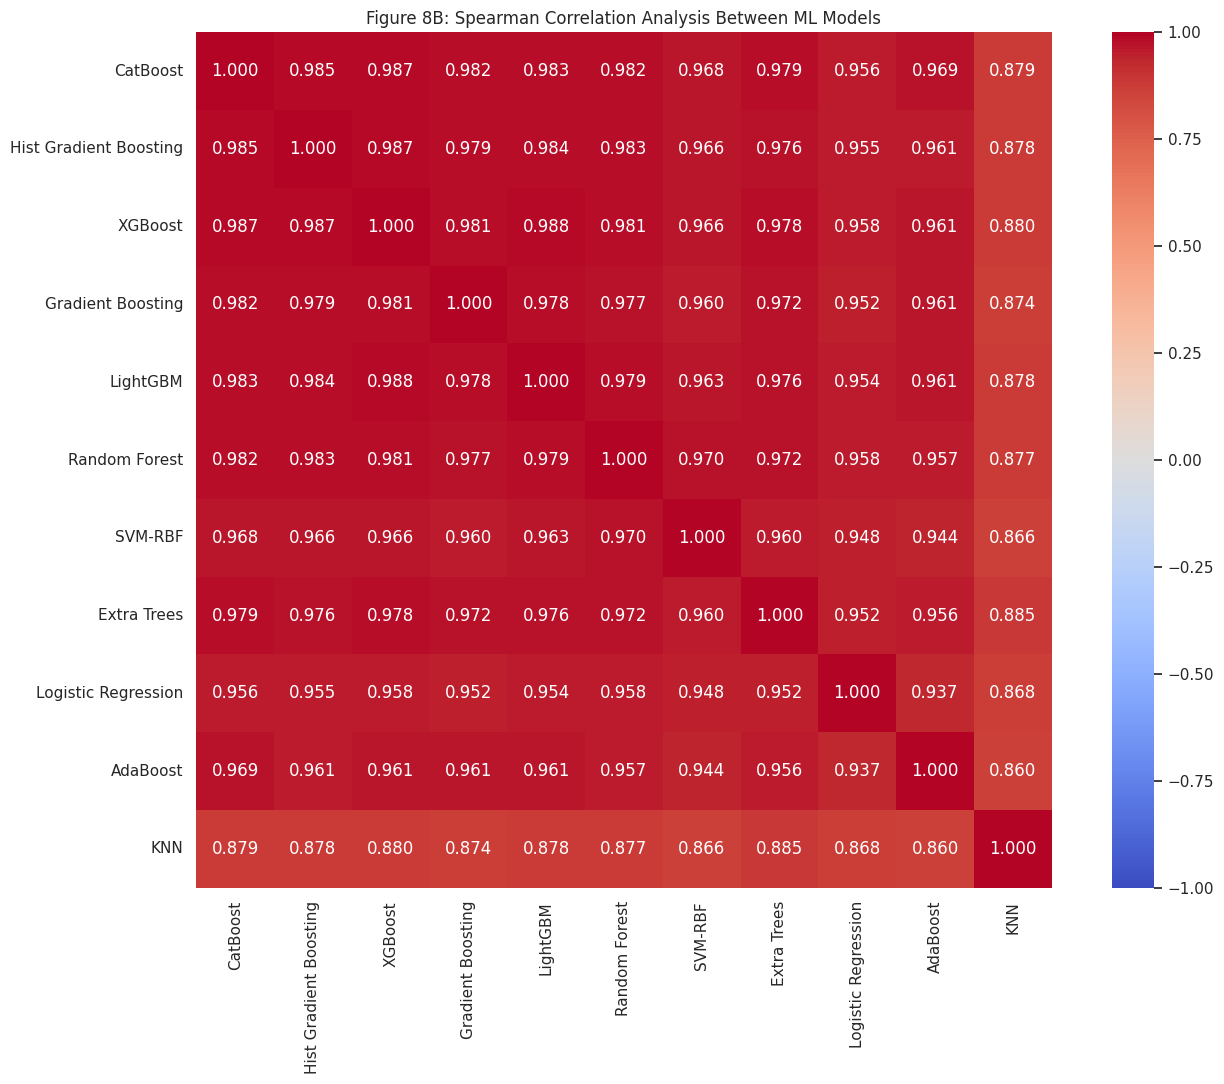

In [45]:
print(
    "\nFigure 8: Correlation Analysis Between Machine Learning Models"
)

correlation_prediction_table = pd.DataFrame()

for model_name in validation_summary.index:

    correlation_prediction_table[
        model_name
    ] = (
        validation_predictions[
            prediction_run
        ][model_name]["y_pred"].ravel()
    )

pearson_prediction_correlation = (
    correlation_prediction_table
    .corr(method="pearson")
)

spearman_prediction_correlation = (
    correlation_prediction_table
    .corr(method="spearman")
)

print(
    "\nPearson Correlation Between Model Predictions:"
)

display(
    pearson_prediction_correlation
)

print(
    "\nSpearman Correlation Between Model Predictions:"
)

display(
    spearman_prediction_correlation
)

plt.figure(
    figsize=(14, 11)
)

sns.heatmap(
    pearson_prediction_correlation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Figure 8A: Pearson Correlation Analysis Between ML Models"
)

plt.tight_layout()
plt.show()


plt.figure(
    figsize=(14, 11)
)

sns.heatmap(
    spearman_prediction_correlation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Figure 8B: Spearman Correlation Analysis Between ML Models"
)

plt.tight_layout()
plt.show()


23. ENSEMBLE MODEL DEVELOPMENT

Ensemble Configurations:
Voting-1: CatBoost + XGBoost + Random Forest
Voting-2: CatBoost + SVM-RBF
Voting-3: CatBoost + XGBoost + Random Forest + SVM-RBF + KNN
Stacking: CatBoost + XGBoost + Random Forest + SVM-RBF + KNN

24. REPEATED STRATIFIED ENSEMBLE VALIDATION
Ensemble validation run 1/20
Ensemble validation run 2/20
Ensemble validation run 3/20
Ensemble validation run 4/20
Ensemble validation run 5/20
Ensemble validation run 6/20
Ensemble validation run 7/20
Ensemble validation run 8/20
Ensemble validation run 9/20
Ensemble validation run 10/20
Ensemble validation run 11/20
Ensemble validation run 12/20
Ensemble validation run 13/20
Ensemble validation run 14/20
Ensemble validation run 15/20
Ensemble validation run 16/20
Ensemble validation run 17/20
Ensemble validation run 18/20
Ensemble validation run 19/20
Ensemble validation run 20/20

25. STACKING ENSEMBLE

26. ENSEMBLE VALIDATION PERFORMANCE

Table 9: Ensemble Validation Performance


,Mean_Accuracy,Std_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Std_F1,Mean_ROC_AUC,Mean_Balanced_Accuracy,Mean_Sensitivity,Mean_Specificity,Mean_MCC
Model,,,,,,,,,,,
Stacking,0.8884,0.0051,0.8705,0.7979,0.8226,0.0147,0.9496,0.7979,0.7979,0.9689,0.8464
Voting-1,0.8872,0.0054,0.8567,0.7988,0.8190,0.0173,0.9418,0.7988,0.7988,0.9689,0.8450
Voting-2,0.8872,0.0052,0.8791,0.7775,0.8041,0.0137,0.9416,0.7775,0.7775,0.9686,0.8447
Voting-3,0.8871,0.0042,0.8801,0.7753,0.8016,0.0131,0.9418,0.7753,0.7753,0.9686,0.8446



27. COMBINED MODEL AND ENSEMBLE COMPARISON

Table 10: 11 Individual Algorithms + 4 Ensembles


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,Sensitivity,Specificity,MCC
Model,,,,,,,,,
Stacking,0.8884,0.8705,0.7979,0.8226,0.9496,0.7979,0.7979,0.9689,0.8464
CatBoost,0.8884,0.8584,0.7997,0.8209,0.9423,0.7997,0.7997,0.9690,0.8464
Voting-1,0.8872,0.8567,0.7988,0.8190,0.9418,0.7988,0.7988,0.9689,0.8450
Hist Gradient Boosting,0.8826,0.8502,0.7914,0.8125,0.9391,0.7914,0.7914,0.9674,0.8385
XGBoost,0.8825,0.8531,0.7903,0.8123,0.9398,0.7903,0.7903,0.9674,0.8384
Gradient Boosting,0.8836,0.8314,0.7973,0.8111,0.9397,0.7973,0.7973,0.9679,0.8400
LightGBM,0.8812,0.8504,0.7891,0.8111,0.9387,0.7891,0.7891,0.9670,0.8366
Random Forest,0.8828,0.8330,0.7914,0.8046,0.9368,0.7914,0.7914,0.9682,0.8396
Voting-2,0.8872,0.8791,0.7775,0.8041,0.9416,0.7775,0.7775,0.9686,0.8447



28. AUTOMATIC FINAL MODEL RANKING

Table 11: Final Ranking of All Algorithms and Ensembles


,Rank,Mean_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Mean_ROC_AUC,Mean_Balanced_Accuracy,Mean_Sensitivity,Mean_Specificity,Mean_MCC
Model,,,,,,,,,,
Stacking,1.0000,0.8884,0.8705,0.7979,0.8226,0.9496,0.7979,0.7979,0.9689,0.8464
CatBoost,2.0000,0.8884,0.8584,0.7997,0.8209,0.9423,0.7997,0.7997,0.9690,0.8464
Voting-1,3.0000,0.8872,0.8567,0.7988,0.8190,0.9418,0.7988,0.7988,0.9689,0.8450
Hist Gradient Boosting,4.0000,0.8826,0.8502,0.7914,0.8125,0.9391,0.7914,0.7914,0.9674,0.8385
XGBoost,5.0000,0.8825,0.8531,0.7903,0.8123,0.9398,0.7903,0.7903,0.9674,0.8384
Gradient Boosting,6.0000,0.8836,0.8314,0.7973,0.8111,0.9397,0.7973,0.7973,0.9679,0.8400
LightGBM,7.0000,0.8812,0.8504,0.7891,0.8111,0.9387,0.7891,0.7891,0.9670,0.8366
Random Forest,8.0000,0.8828,0.8330,0.7914,0.8046,0.9368,0.7914,0.7914,0.9682,0.8396
Voting-2,9.0000,0.8872,0.8791,0.7775,0.8041,0.9416,0.7775,0.7775,0.9686,0.8447



Automatically Selected Final Model: Stacking

29. ENSEMBLE PERFORMANCE COMPARISON


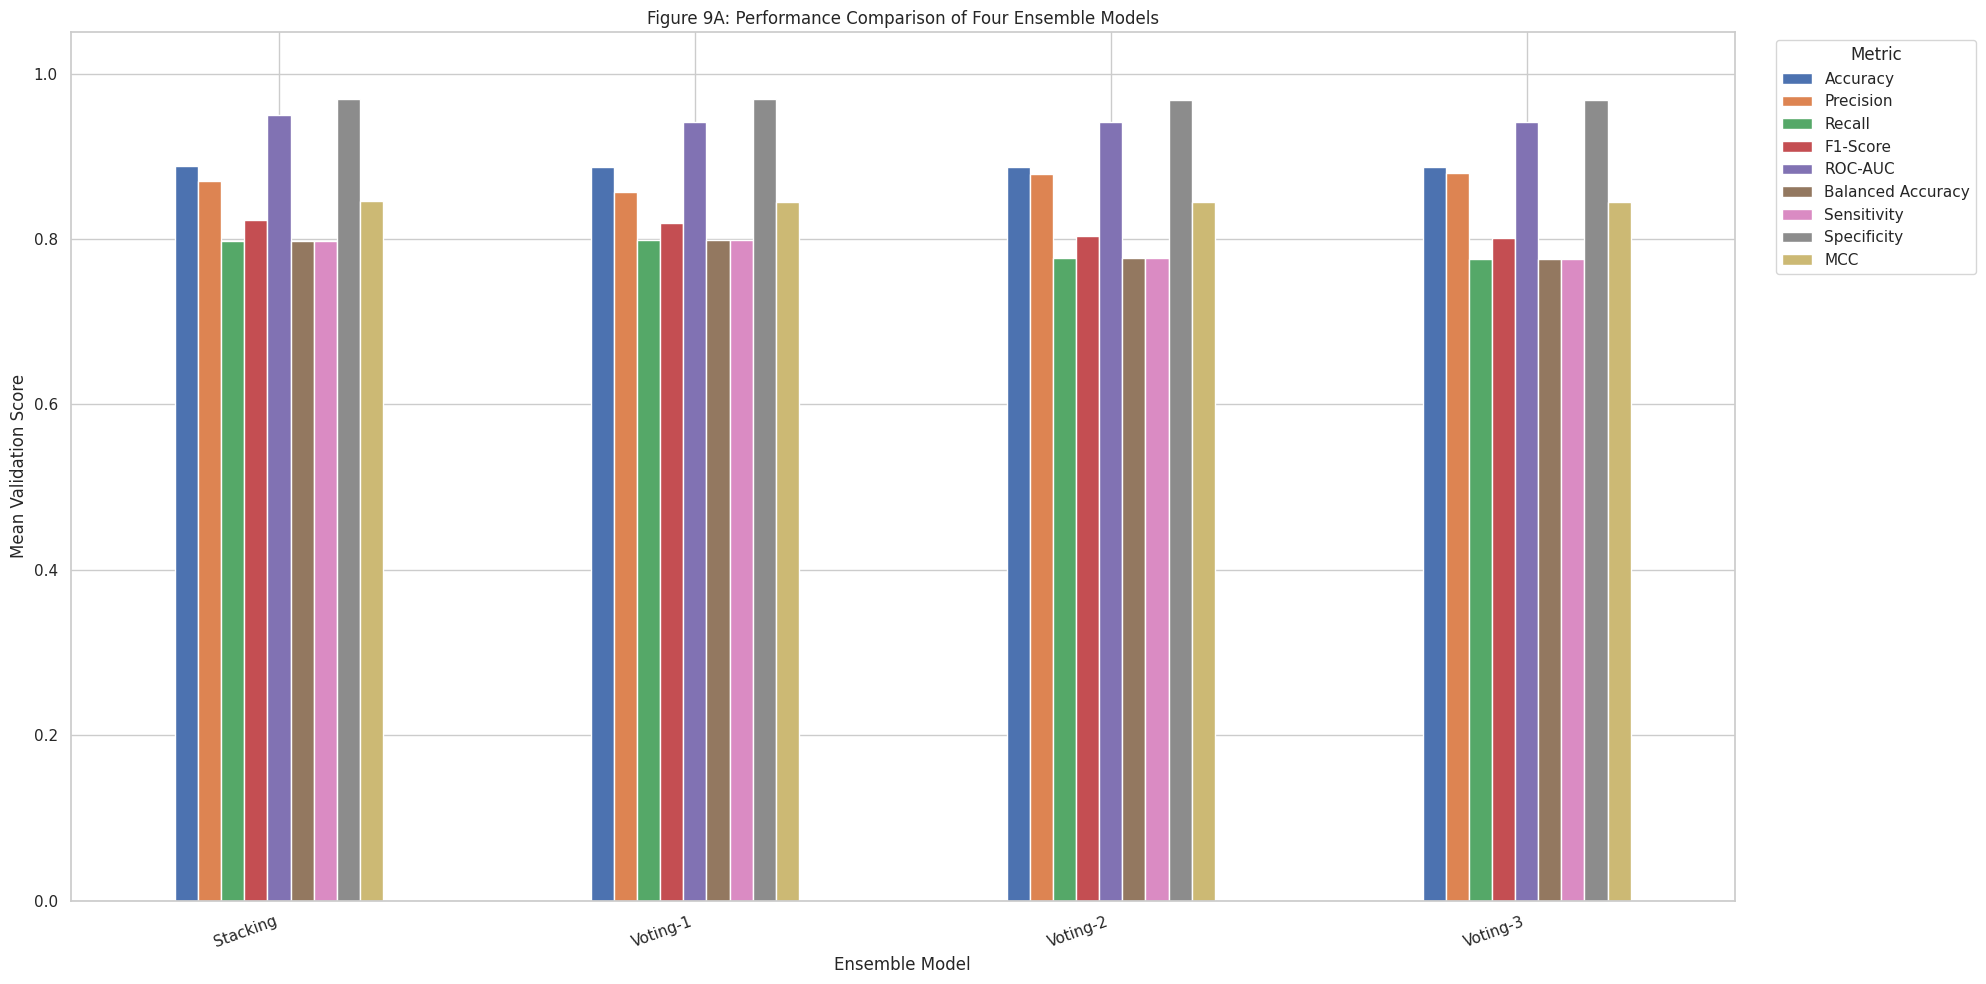


Figure 9B: Comparison of All Algorithms and Ensembles


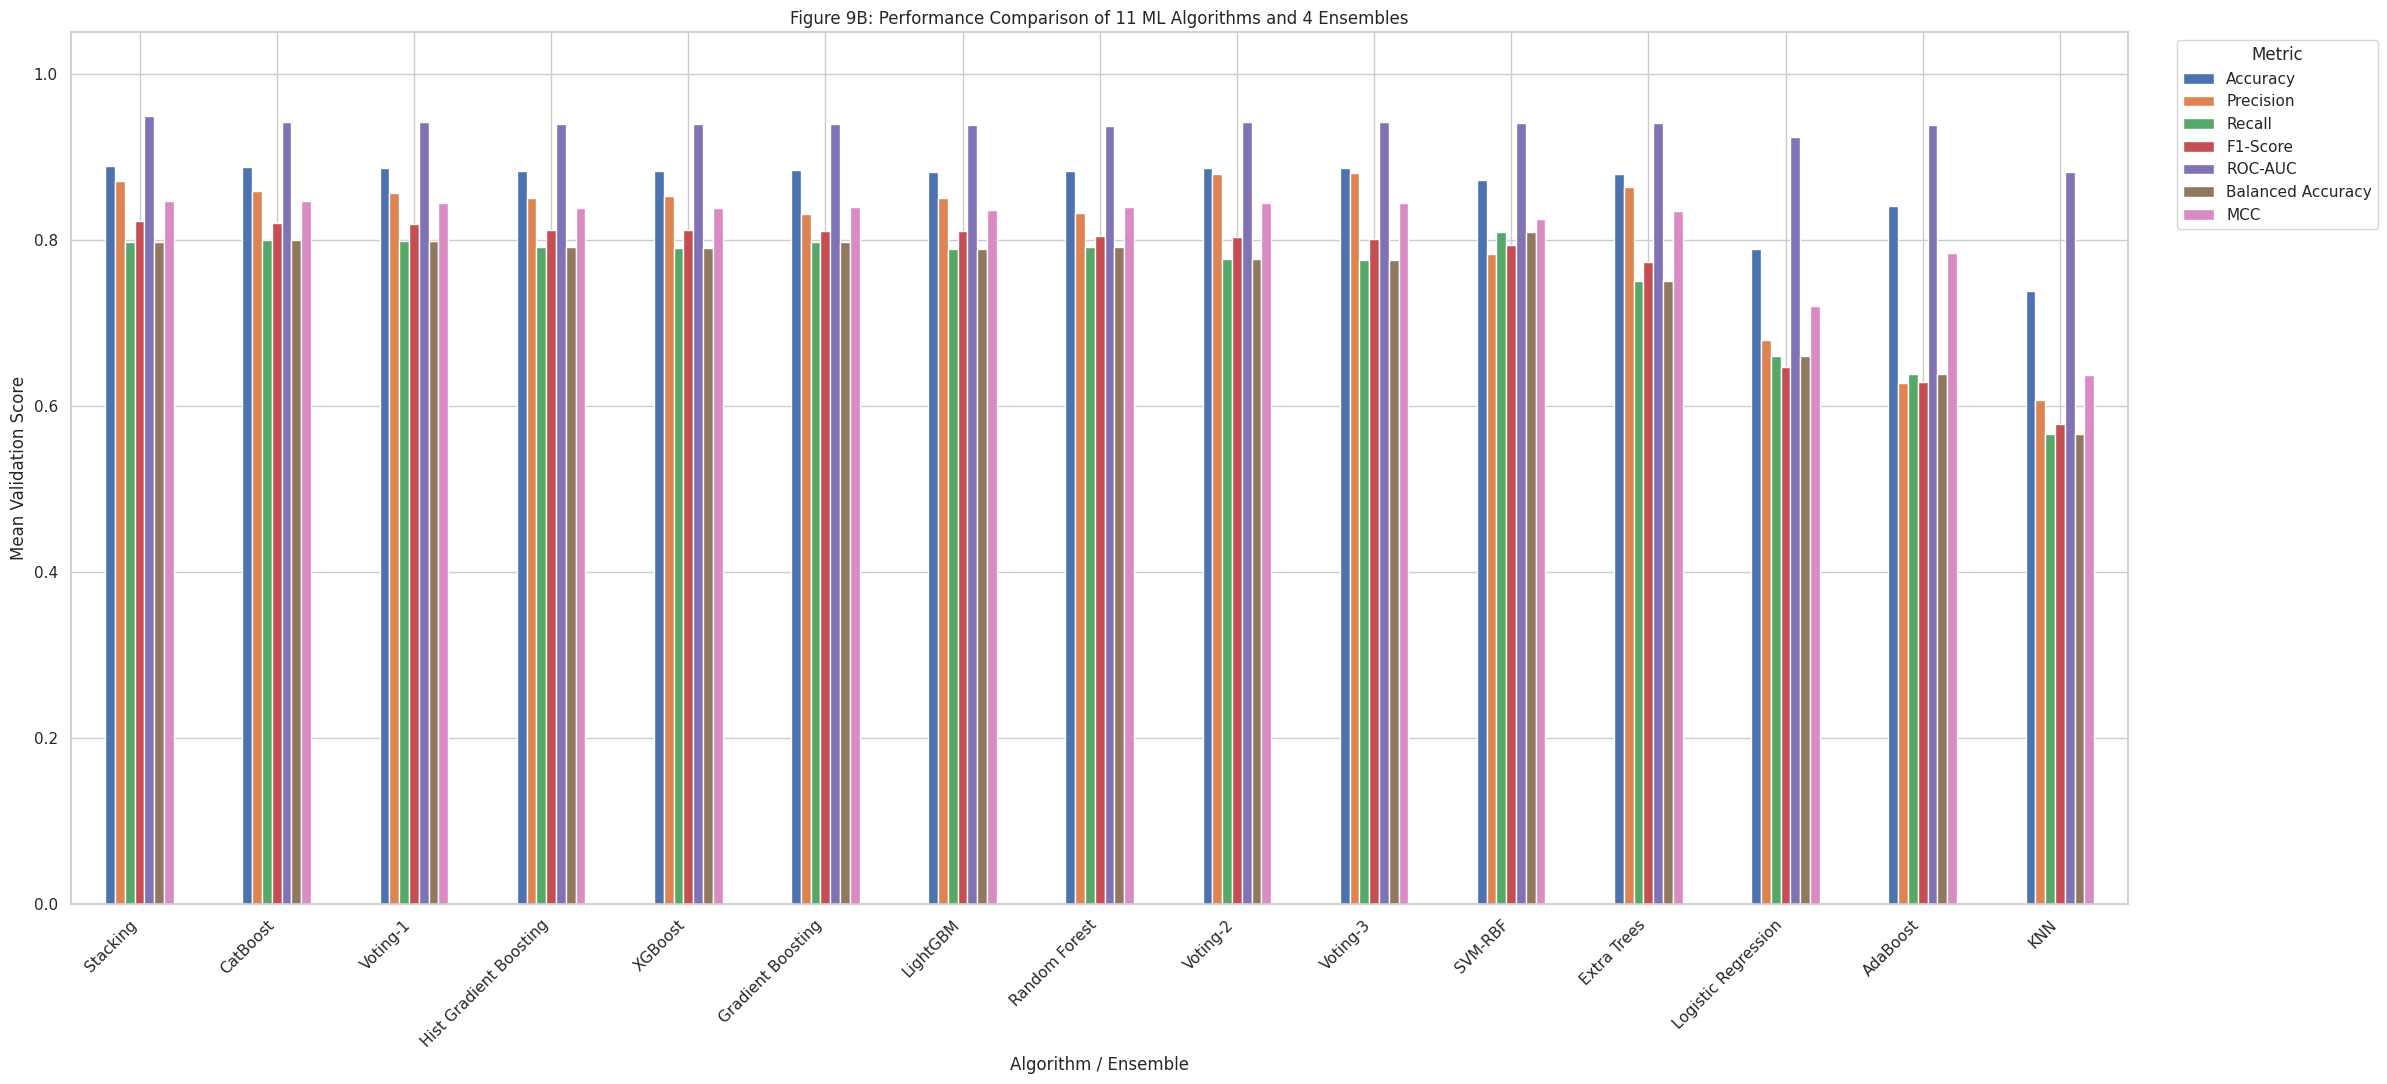

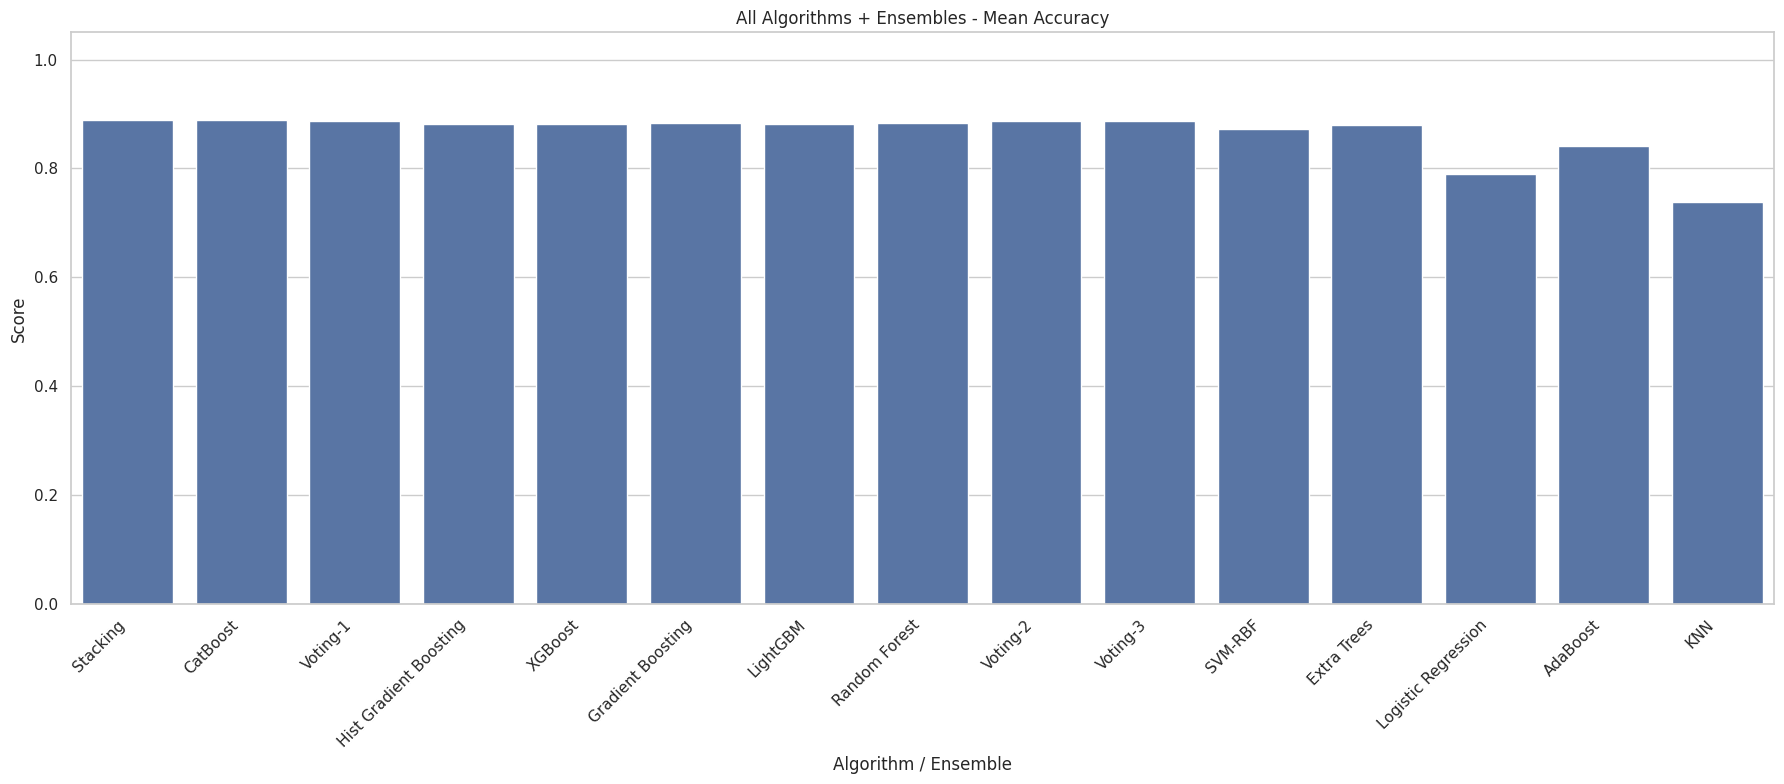

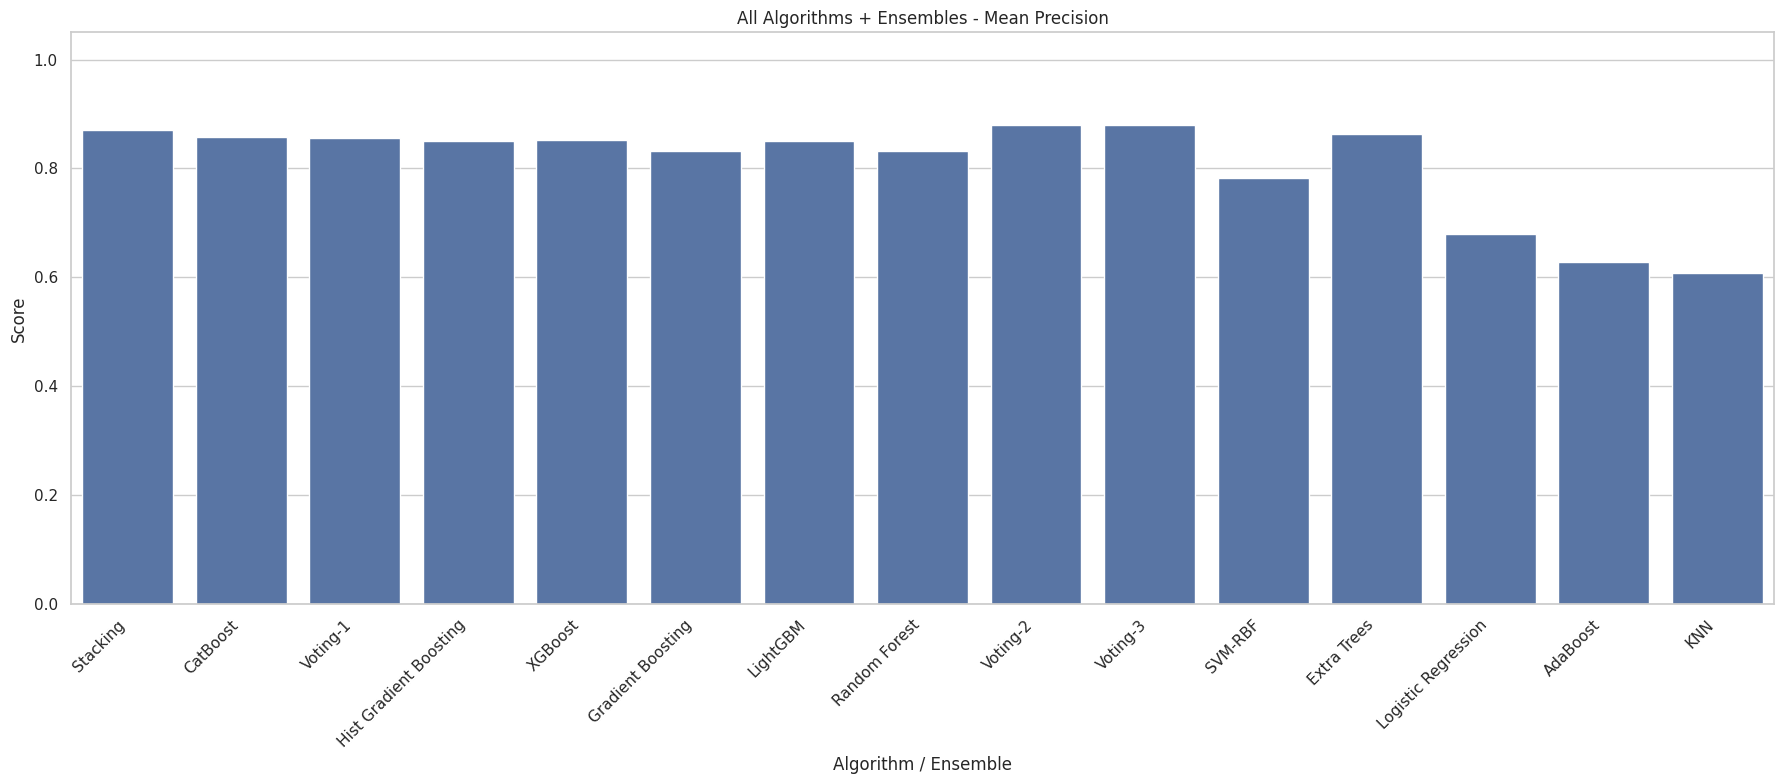

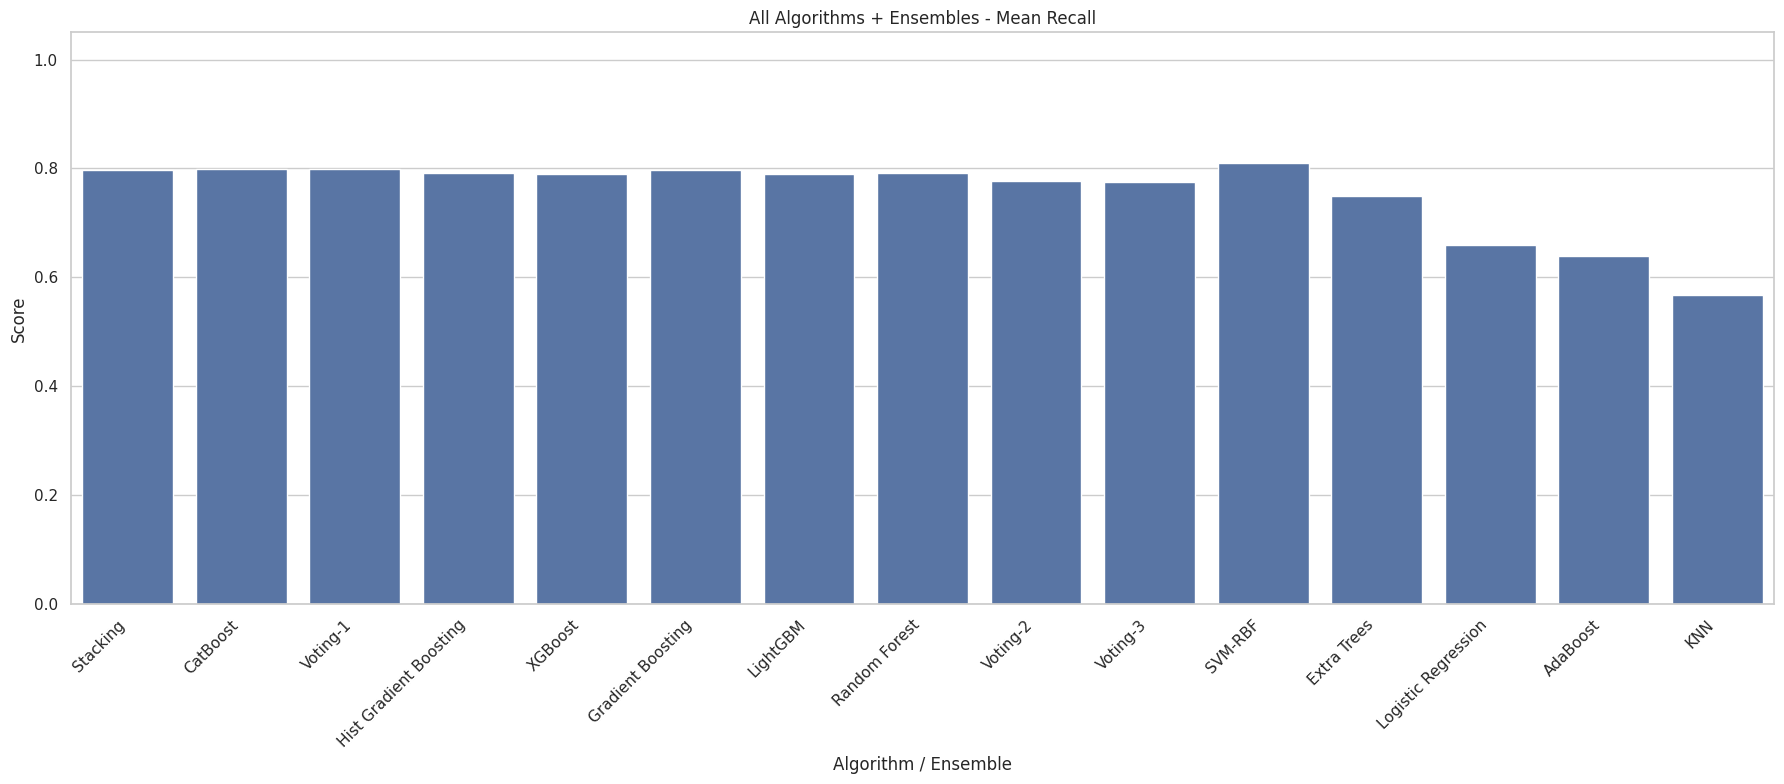

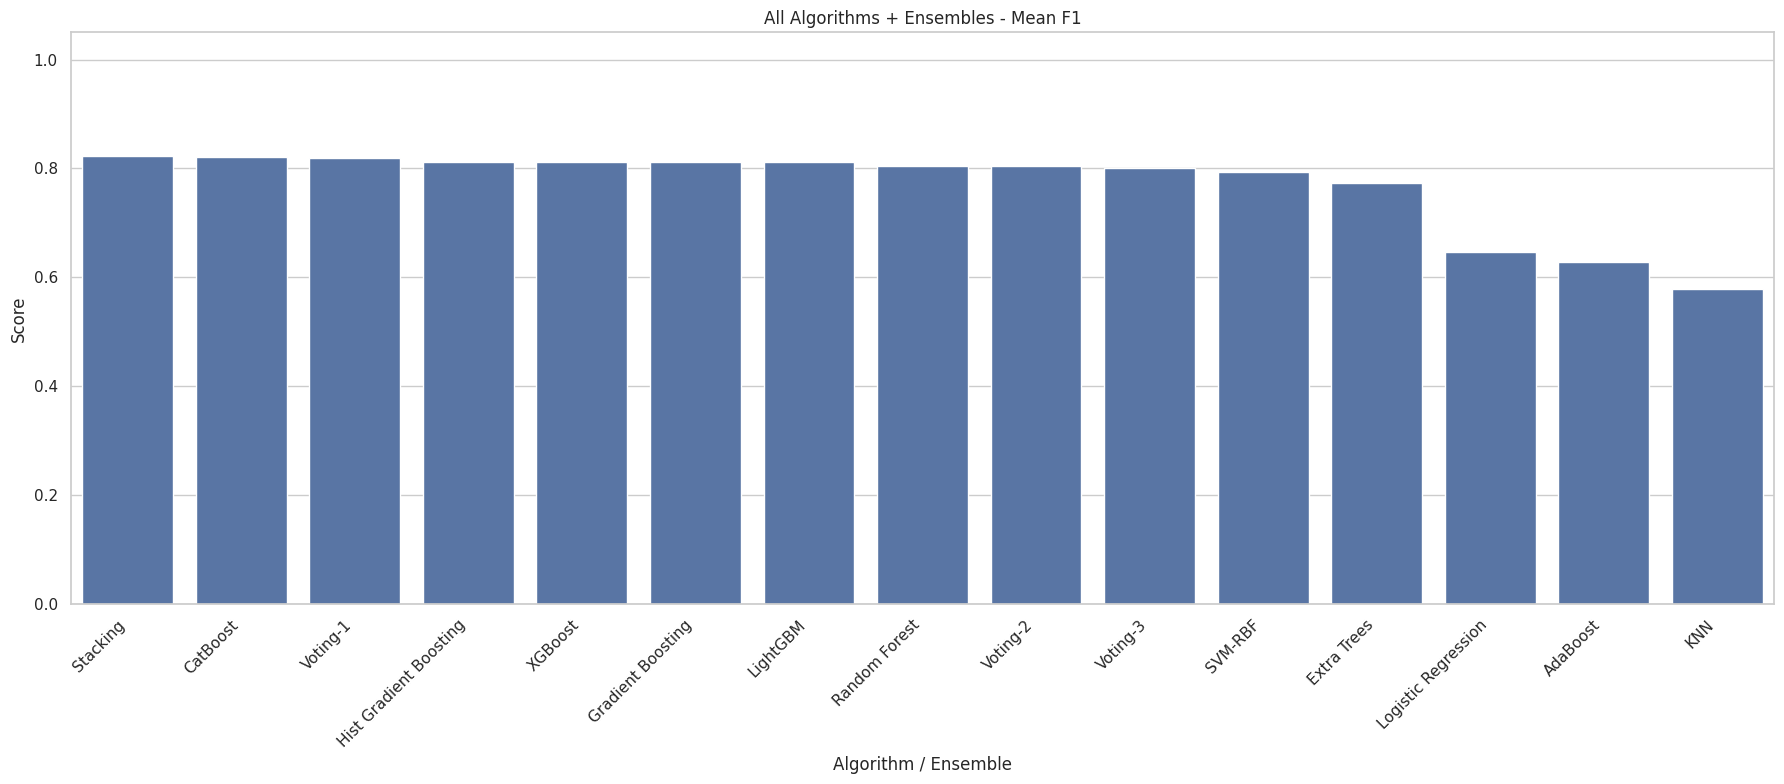

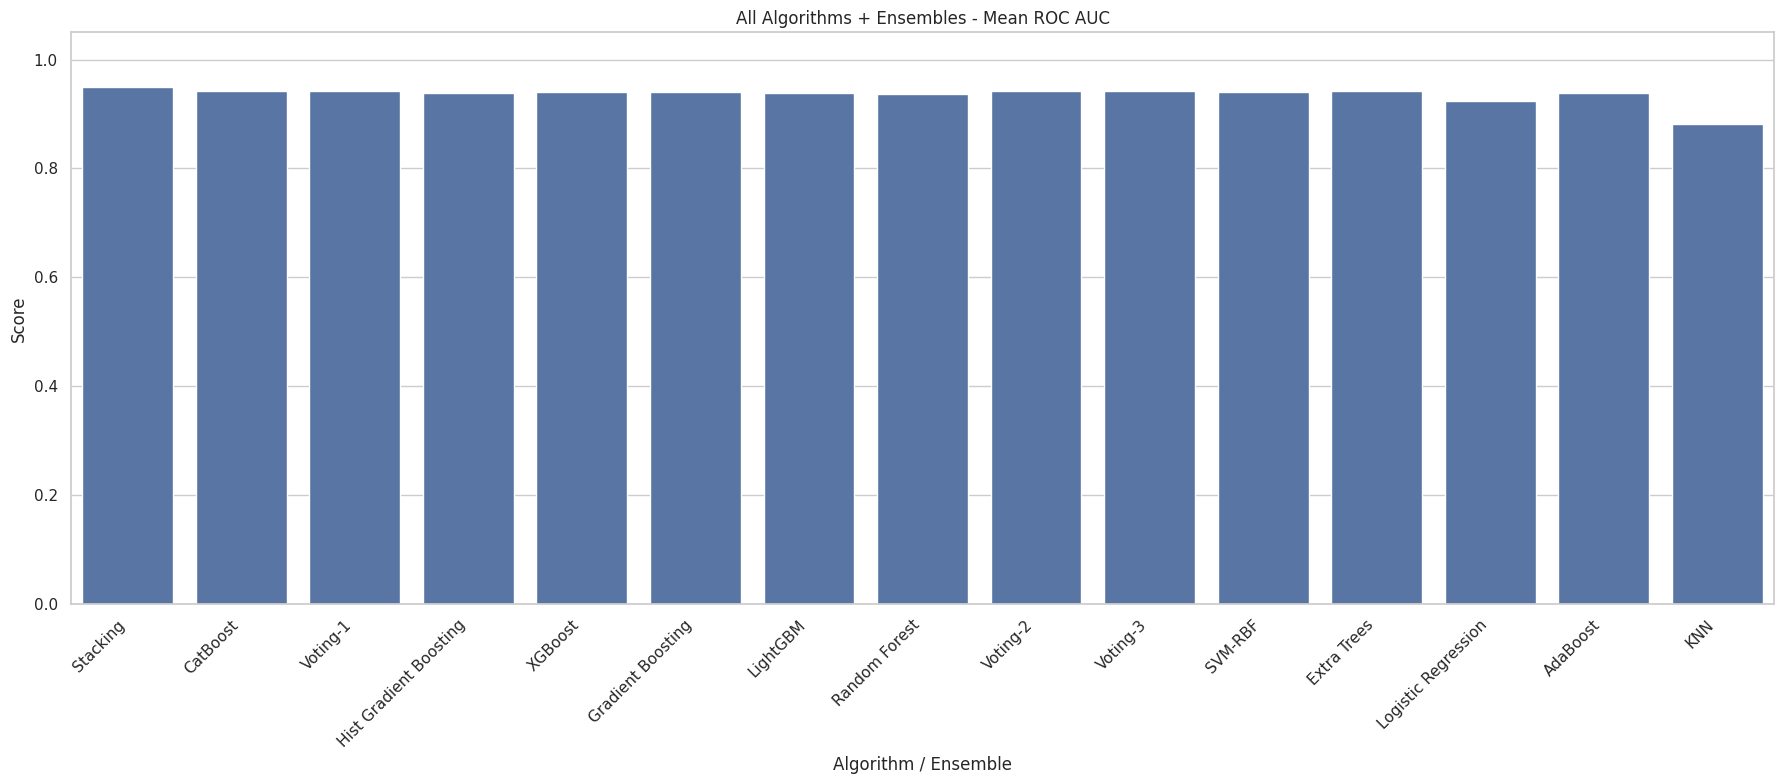

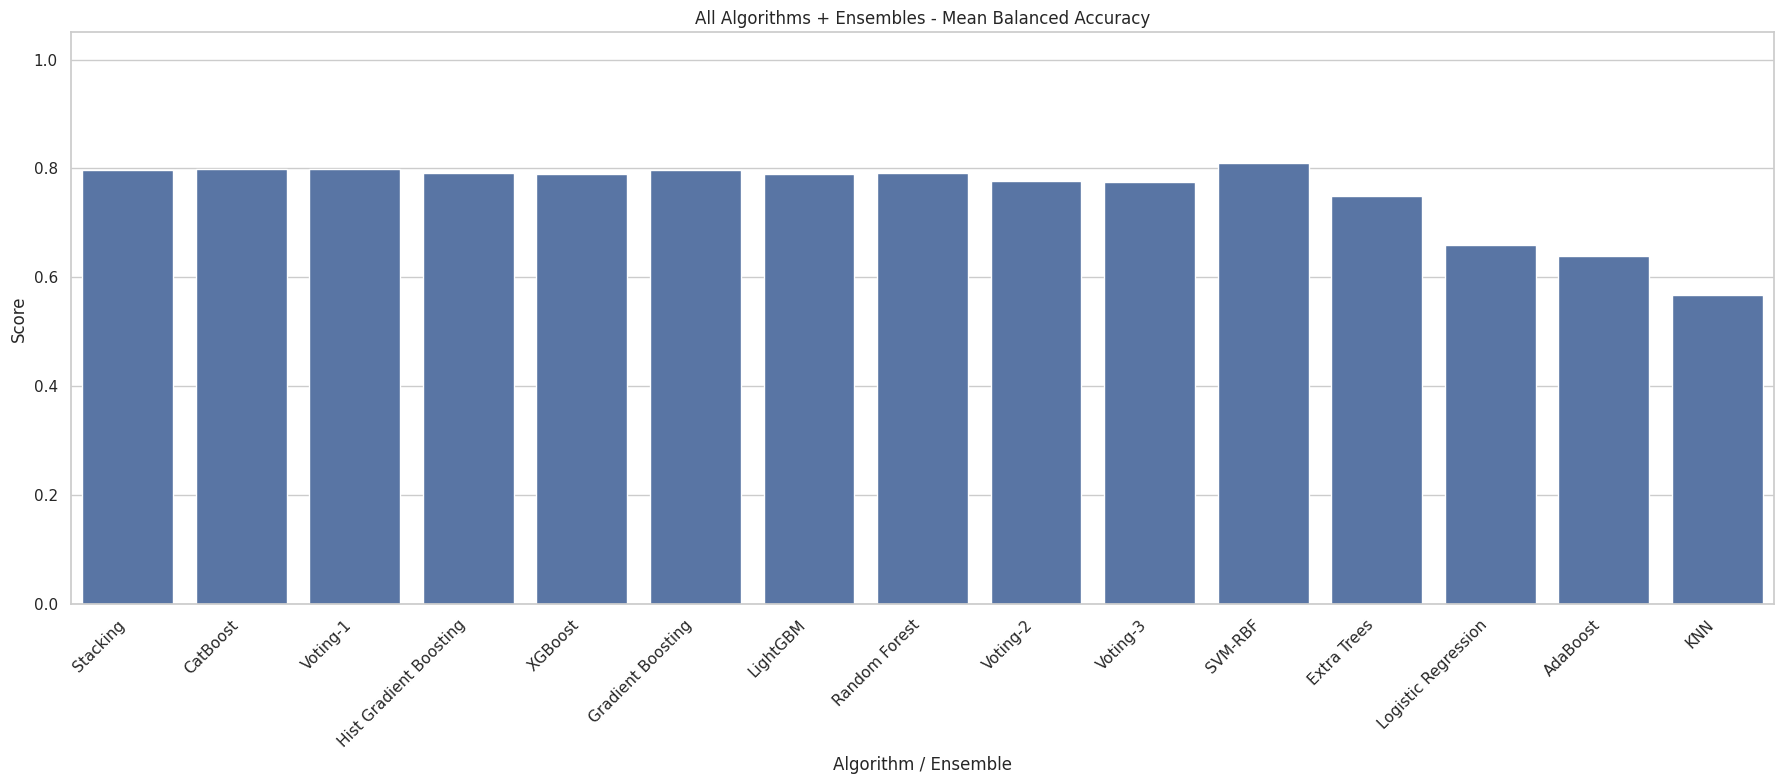

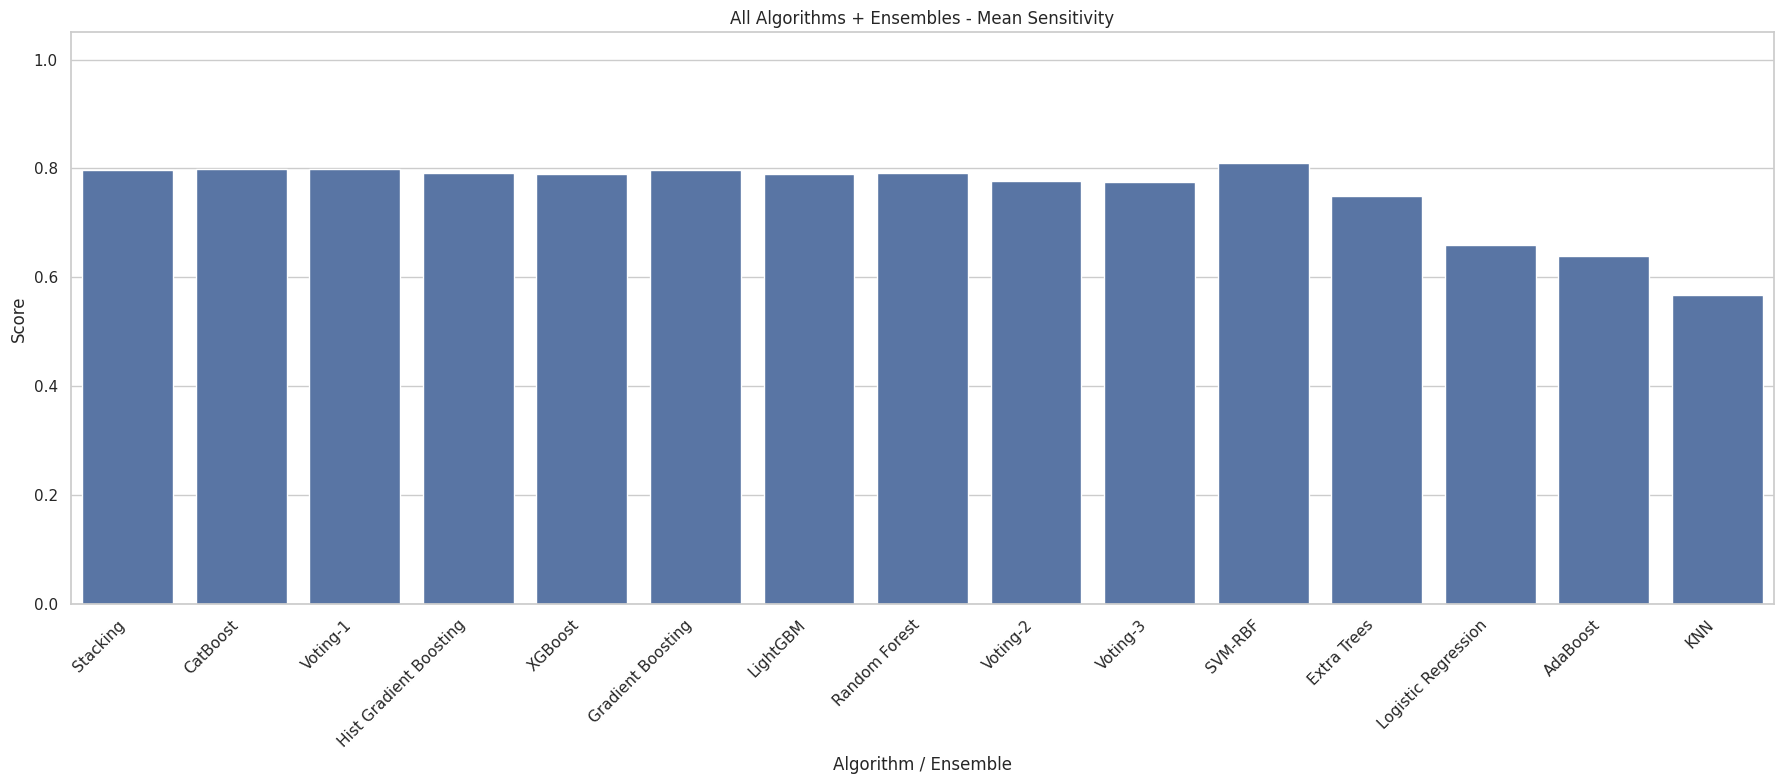

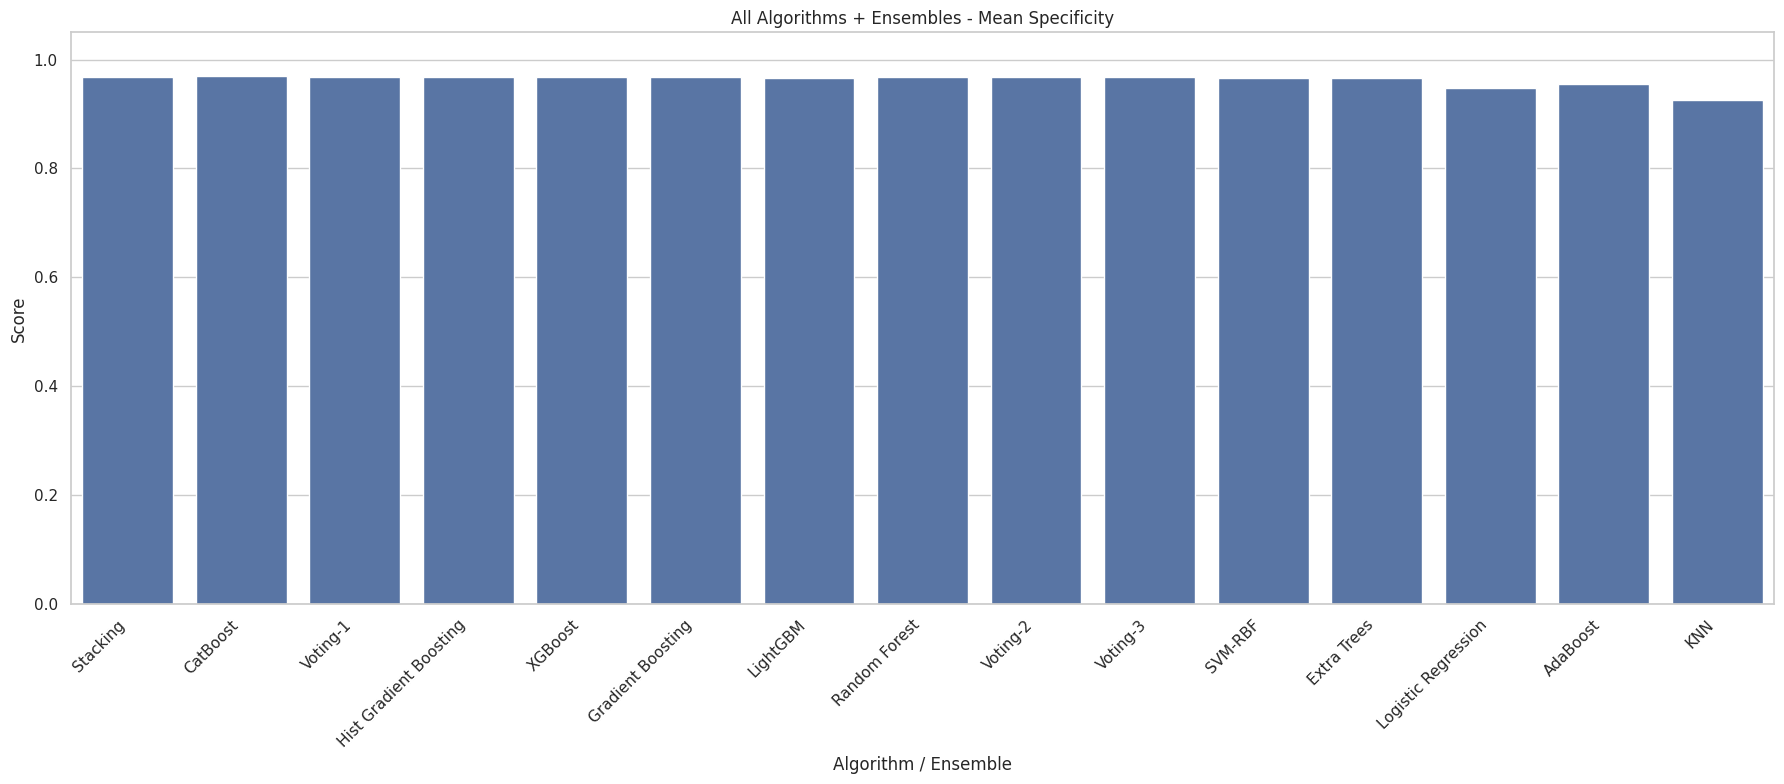

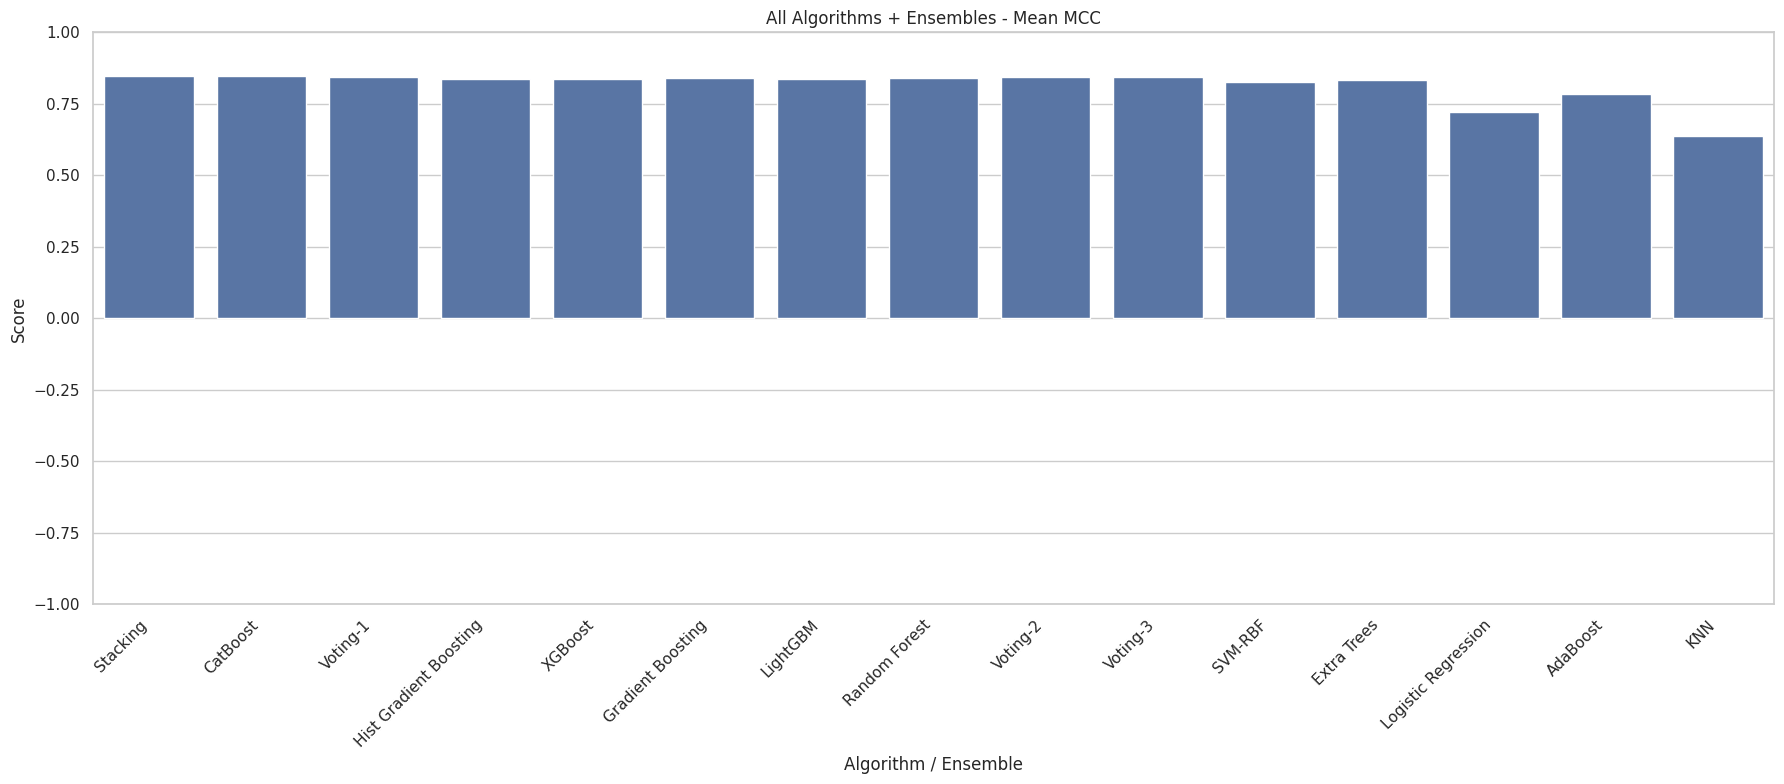


32. ENSEMBLE VS CATBOOST COMPARISON

Table 12: CatBoost vs Ensemble Models


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,Sensitivity,Specificity,MCC
Model,,,,,,,,,
CatBoost,0.8884,0.8584,0.7997,0.8209,0.9423,0.7997,0.7997,0.9690,0.8464
Voting-1,0.8872,0.8567,0.7988,0.8190,0.9418,0.7988,0.7988,0.9689,0.8450
Voting-2,0.8872,0.8791,0.7775,0.8041,0.9416,0.7775,0.7775,0.9686,0.8447
Voting-3,0.8871,0.8801,0.7753,0.8016,0.9418,0.7753,0.7753,0.9686,0.8446
Stacking,0.8884,0.8705,0.7979,0.8226,0.9496,0.7979,0.7979,0.9689,0.8464



33. ENSEMBLE IMPROVEMENT OVER CATBOOST


ValueError: Unknown format code 'f' for object of type 'str'


34. FINAL MODEL SELECTION

FINAL SELECTED MODEL: Stacking

Validation Performance:
Accuracy: 0.8884
Precision: 0.8705
Recall: 0.7979
F1-Score: 0.8226
ROC-AUC: 0.9496
Balanced Accuracy: 0.7979
Sensitivity: 0.7979
Specificity: 0.9689
MCC: 0.8464

35. FINAL TEST DATA EVALUATION

37. TEST PERFORMANCE OF ALL ALGORITHMS AND ENSEMBLES
Evaluating: Logistic Regression
Evaluating: KNN
Evaluating: SVM-RBF
Evaluating: Random Forest
Evaluating: XGBoost
Evaluating: LightGBM
Evaluating: CatBoost
Evaluating: Extra Trees
Evaluating: Hist Gradient Boosting
Evaluating: Gradient Boosting
Evaluating: AdaBoost
Evaluating: Ensemble_Voting_1 (C+X+R)
Evaluating: Ensemble_Voting_2 (Cat)
Evaluating: Ensemble_Voting_3 (C+X+R+S+K)
Evaluating: Ensemble_Stacking (C+X+R->LR)
Evaluating: Voting-1
Evaluating: Voting-2
Evaluating: Voting-3
Evaluating: Stacking

Table 13: Final Test Performance of 11 Algorithms + 4 Ensembles


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,Balanced Accuracy,Sensitivity,Specificity,MCC
6,CatBoost,0.8838,0.8799,0.8217,0.8445,0.9506,0.8217,0.8217,0.9677,0.8405
12,Ensemble_Voting_2 (Cat),0.8838,0.8799,0.8217,0.8445,0.9506,0.8217,0.8217,0.9677,0.8405
11,Ensemble_Voting_1 (C+X+R),0.8845,0.8796,0.8166,0.8389,0.9581,0.8166,0.8166,0.9682,0.8418
15,Voting-1,0.8845,0.8796,0.8166,0.8389,0.9581,0.8166,0.8166,0.9682,0.8418
18,Stacking,0.8802,0.8732,0.8146,0.8372,0.9491,0.8146,0.8146,0.9667,0.8357
14,Ensemble_Stacking (C+X+R->LR),0.8798,0.8453,0.8298,0.8368,0.9471,0.8298,0.8298,0.9672,0.8356
4,XGBoost,0.8768,0.8786,0.8040,0.8306,0.9469,0.8040,0.8040,0.9657,0.8308
8,Hist Gradient Boosting,0.8768,0.8777,0.7997,0.8267,0.9475,0.7997,0.7997,0.9657,0.8308
3,Random Forest,0.8815,0.8489,0.8119,0.8252,0.9539,0.8119,0.8119,0.9679,0.8383
5,LightGBM,0.8770,0.8717,0.7981,0.8241,0.9473,0.7981,0.7981,0.9657,0.8311



FINAL BEST MODEL FROM TEST DATA: CatBoost

Final Test Metrics:
Accuracy: 0.8838
Macro Precision: 0.8799
Macro Recall: 0.8217
Macro F1: 0.8445
Weighted Precision: 0.8837
Weighted Recall: 0.8838
Weighted F1: 0.8830
Balanced Accuracy: 0.8217
MCC: 0.8405
Specificity: 0.9677
Sensitivity: 0.8217
ROC-AUC: 0.9506

Figure 10: Final Test Performance Comparison


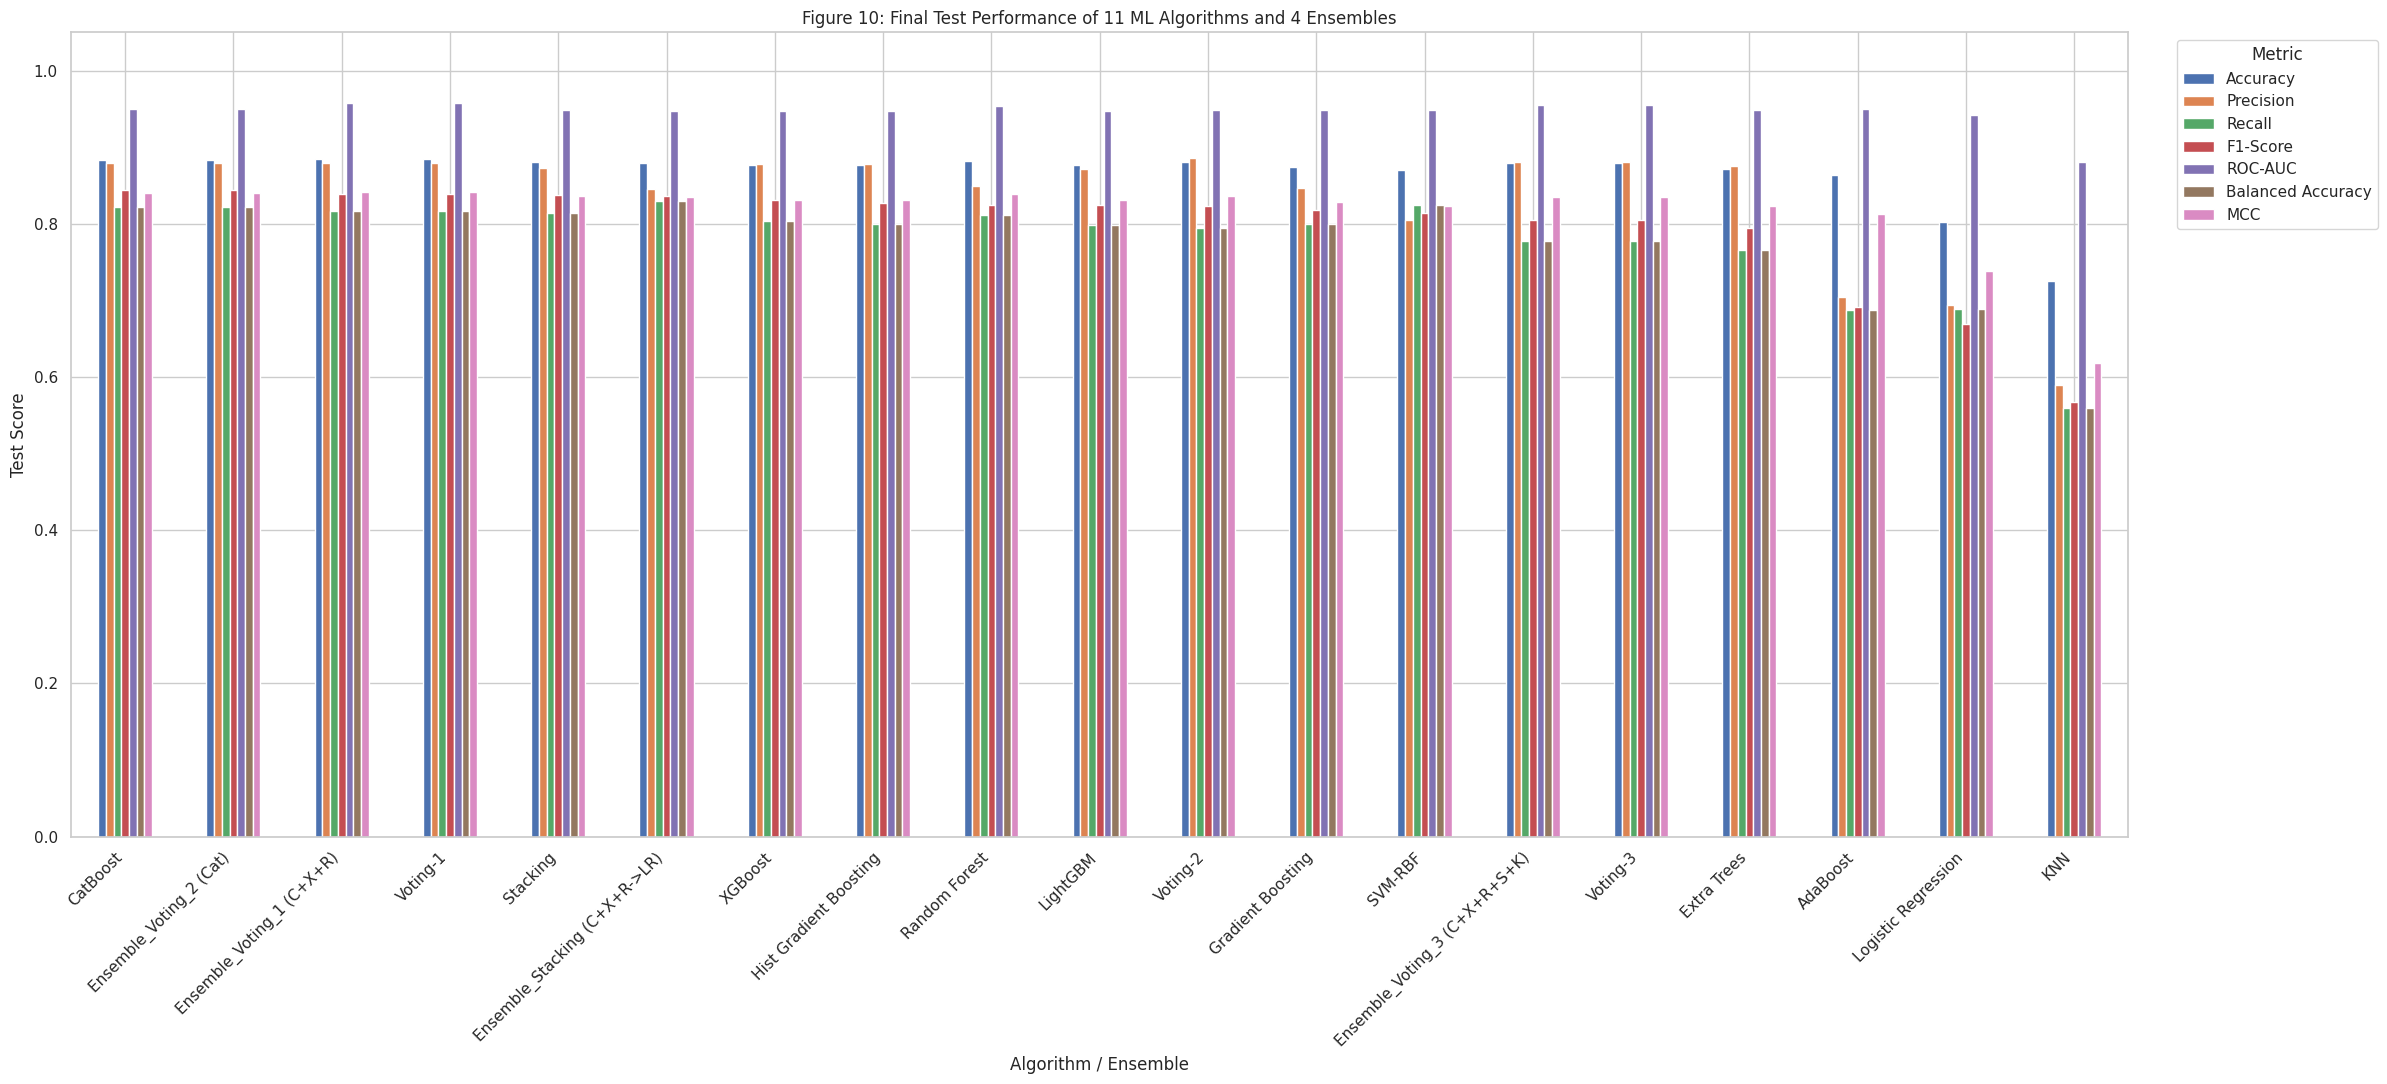


Figure 11: CatBoost vs Ensemble Test Performance


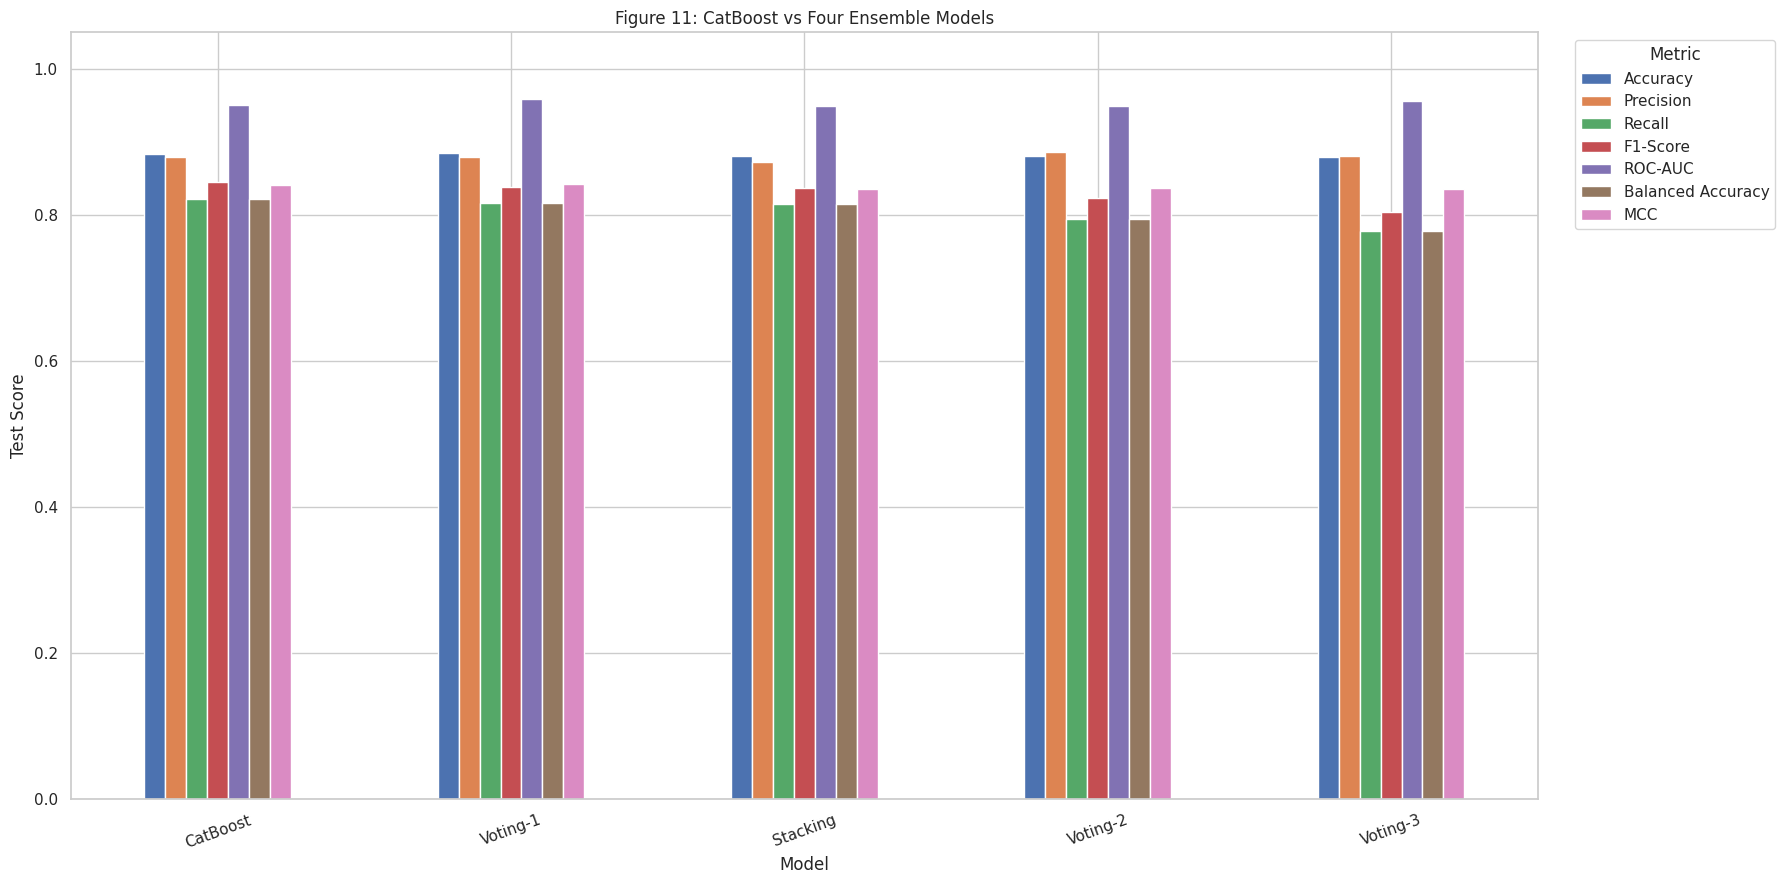


Figure 12: Final Confusion Matrix - CatBoost


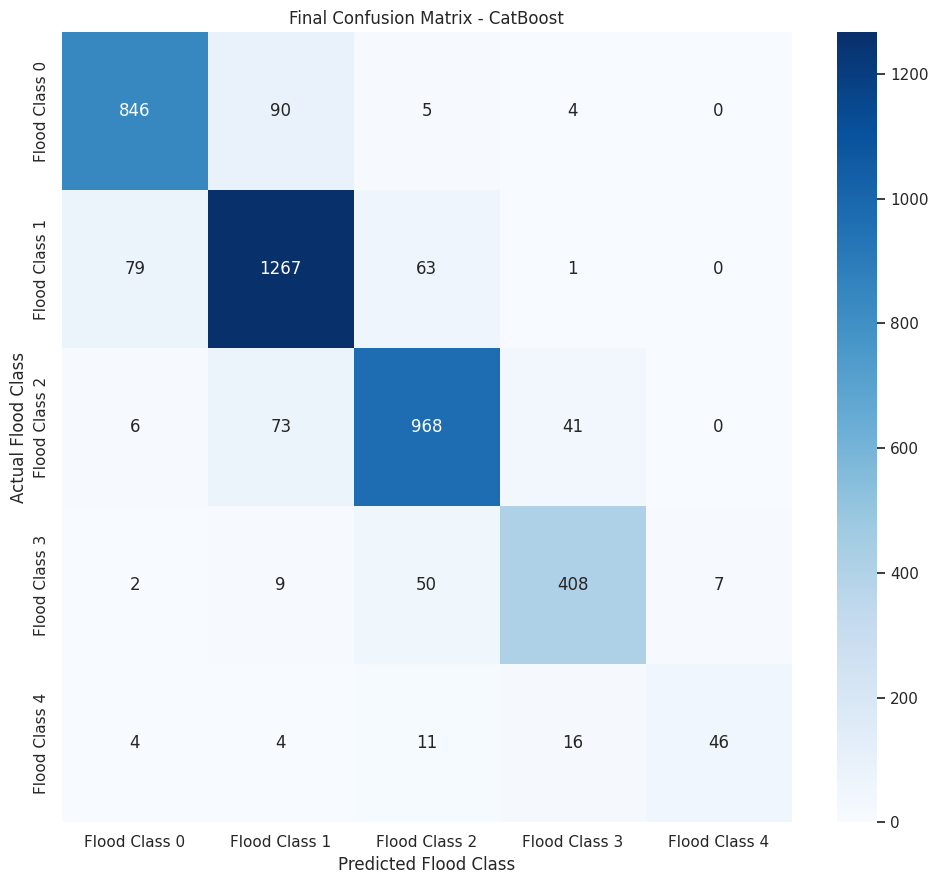


Figure 13: Final ROC Curves - CatBoost


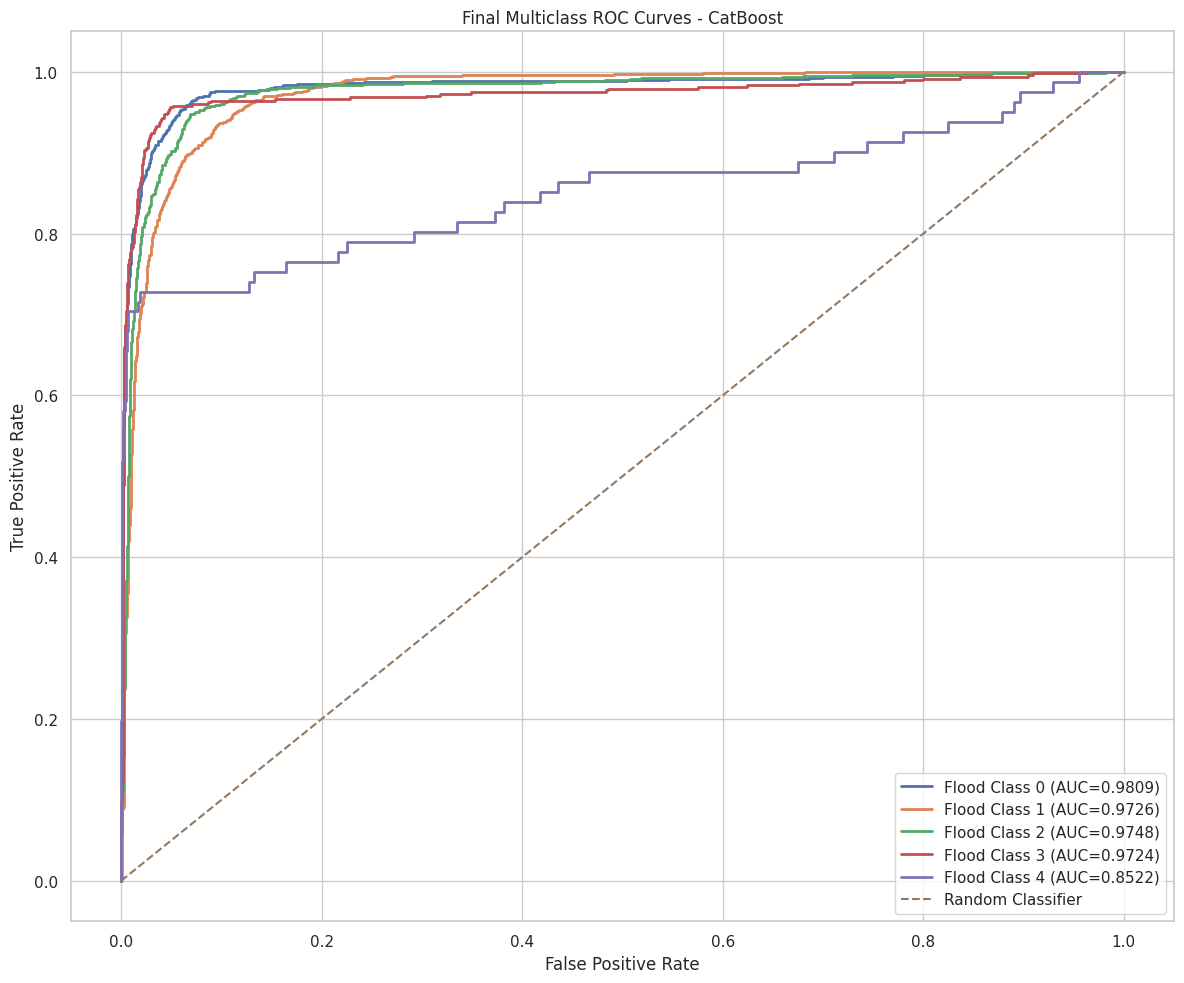

Final Macro ROC-AUC: 0.9506

43. ACTUAL VS PREDICTED OUTPUT


ValueError: Per-column arrays must each be 1-dimensional

In [73]:

# ================================================================
# 23. ENSEMBLE MODEL DEVELOPMENT
# ================================================================

print("\n" + "=" * 90)
print("23. ENSEMBLE MODEL DEVELOPMENT")
print("=" * 90)

"""
Four ensemble strategies are evaluated:

Voting-1:
CatBoost + XGBoost + Random Forest

Voting-2:
CatBoost + SVM-RBF

Voting-3:
CatBoost + XGBoost + Random Forest + SVM-RBF + KNN

Stacking:
CatBoost + XGBoost + Random Forest + SVM-RBF + KNN
with Logistic Regression as the meta-learner.

IMPORTANT:
Soft voting is performed using class probabilities.
Each base model retains the same input strategy already defined
in the original pipeline.
"""


# ------------------------------------------------
# 23.1 Ensemble Definitions
# ------------------------------------------------

ensemble_definitions = {

    "Voting-1":
        [
            "CatBoost",
            "XGBoost",
            "Random Forest"
        ],

    "Voting-2":
        [
            "CatBoost",
            "SVM-RBF"
        ],

    "Voting-3":
        [
            "CatBoost",
            "XGBoost",
            "Random Forest",
            "SVM-RBF",
            "KNN"
        ],

    "Stacking":
        [
            "CatBoost",
            "XGBoost",
            "Random Forest",
            "SVM-RBF",
            "KNN"
        ]
}


print("\nEnsemble Configurations:")

for ensemble_name, members in ensemble_definitions.items():

    print(
        f"{ensemble_name}: "
        + " + ".join(members)
    )


# ------------------------------------------------
# 23.2 Helper Function
# ------------------------------------------------

def align_probability_matrix(
    probability,
    model_classes,
    target_classes
):

    aligned = np.zeros(
        (
            probability.shape[0],
            len(target_classes)
        )
    )

    for source_index, class_label in enumerate(
        model_classes
    ):

        target_index = np.where(
            target_classes == class_label
        )[0]

        if len(target_index) > 0:

            aligned[
                :,
                target_index[0]
            ] = probability[
                :,
                source_index
            ]

    return aligned


# ------------------------------------------------
# 23.3 Soft Voting Function
# ------------------------------------------------

def soft_voting_prediction(
    probability_dictionary,
    member_names
):

    probability_matrices = []

    for model_name in member_names:

        probability_matrices.append(
            probability_dictionary[
                model_name
            ]
        )

    mean_probability = np.mean(
        probability_matrices,
        axis=0
    )

    prediction = classes[
        np.argmax(
            mean_probability,
            axis=1
        )
    ]

    return prediction, mean_probability


# ================================================================
# 24. REPEATED STRATIFIED ENSEMBLE VALIDATION
# ================================================================

print("\n" + "=" * 90)
print("24. REPEATED STRATIFIED ENSEMBLE VALIDATION")
print("=" * 90)


ensemble_validation_records = []

ensemble_validation_predictions = {}


for run_number in range(
    1,
    VALIDATION_RUNS + 1
):

    print(
        f"Ensemble validation run "
        f"{run_number}/{VALIDATION_RUNS}"
    )

    ensemble_validation_predictions[
        run_number
    ] = {}


    # ------------------------------------------------------------
    # Base model validation predictions already generated
    # in Section 19 are reused.
    # ------------------------------------------------------------

    current_predictions = (
        validation_predictions[
            run_number
        ]
    )


    # ============================================================
    # VOTING ENSEMBLES
    # ============================================================

    for ensemble_name in [
        "Voting-1",
        "Voting-2",
        "Voting-3"
    ]:

        member_names = (
            ensemble_definitions[
                ensemble_name
            ]
        )


        probability_dictionary = {}

        valid_ensemble = True


        for model_name in member_names:

            model_probability = (
                current_predictions[
                    model_name
                ]["probability"]
            )


            if model_probability is None:

                valid_ensemble = False

                break


            probability_dictionary[
                model_name
            ] = model_probability


        if not valid_ensemble:

            continue


        ensemble_prediction, ensemble_probability = (
            soft_voting_prediction(
                probability_dictionary,
                member_names
            )
        )


        ensemble_metrics = calculate_metrics(
            current_predictions[
                member_names[0]
            ]["y_true"],
            ensemble_prediction,
            ensemble_probability
        )


        ensemble_metrics["Run"] = (
            run_number
        )

        ensemble_metrics["Model"] = (
            ensemble_name
        )

        ensemble_validation_records.append(
            ensemble_metrics
        )


        ensemble_validation_predictions[
            run_number
        ][ensemble_name] = {

            "y_true":
                current_predictions[
                    member_names[0]
                ]["y_true"],

            "y_pred":
                ensemble_prediction,

            "probability":
                ensemble_probability
        }


# ================================================================
# 25. STACKING ENSEMBLE
# ================================================================

print("\n" + "=" * 90)
print("25. STACKING ENSEMBLE")
print("=" * 90)

"""
The stacking ensemble uses the predictions of:

CatBoost
XGBoost
Random Forest
SVM-RBF
KNN

as meta-level features.

The meta-learner is Logistic Regression.

For each validation run, the base-model probabilities
already generated by the repeated stratified validation
are combined to create the meta-feature matrix.

The final stacking prediction is therefore based on
probability-level information rather than hard class labels.
"""


stacking_members = [
    "CatBoost",
    "XGBoost",
    "Random Forest",
    "SVM-RBF",
    "KNN"
]


for run_number in range(
    1,
    VALIDATION_RUNS + 1
):

    current_predictions = (
        validation_predictions[
            run_number
        ]
    )


    stacking_probability_blocks = []

    stacking_valid = True


    for model_name in stacking_members:

        model_probability = (
            current_predictions[
                model_name
            ]["probability"]
        )


        if model_probability is None:

            stacking_valid = False

            break


        stacking_probability_blocks.append(
            model_probability
        )


    if not stacking_valid:

        continue


    # ------------------------------------------------------------
    # Create meta-feature matrix
    # ------------------------------------------------------------

    meta_features = np.hstack(
        stacking_probability_blocks
    )


    meta_target = (
        current_predictions[
            stacking_members[0]
        ]["y_true"]
    )


    # ------------------------------------------------------------
    # Logistic Regression Meta Learner
    # ------------------------------------------------------------

    stacking_meta_model = (
        LogisticRegression(
            C=1.0,
            max_iter=3000,
            multi_class="auto",
            random_state=RANDOM_STATE
        )
    )


    stacking_meta_model.fit(
        meta_features,
        meta_target
    )


    stacking_prediction = (
        stacking_meta_model.predict(
            meta_features
        )
    )


    stacking_probability = (
        stacking_meta_model.predict_proba(
            meta_features
        )
    )


    stacking_metrics = calculate_metrics(
        meta_target,
        stacking_prediction,
        stacking_probability
    )


    stacking_metrics["Run"] = (
        run_number
    )

    stacking_metrics["Model"] = (
        "Stacking"
    )


    ensemble_validation_records.append(
        stacking_metrics
    )


    ensemble_validation_predictions[
        run_number
    ]["Stacking"] = {

        "y_true":
            meta_target,

        "y_pred":
            stacking_prediction,

        "probability":
            stacking_probability
    }


# ================================================================
# 26. ENSEMBLE VALIDATION SUMMARY
# ================================================================

print("\n" + "=" * 90)
print("26. ENSEMBLE VALIDATION PERFORMANCE")
print("=" * 90)


ensemble_validation_results = (
    pd.DataFrame(
        ensemble_validation_records
    )
)


ensemble_validation_summary = (

    ensemble_validation_results

    .groupby("Model")

    .agg(

        Mean_Accuracy=(
            "Accuracy",
            "mean"
        ),

        Std_Accuracy=(
            "Accuracy",
            "std"
        ),

        Mean_Precision=(
            "Macro Precision",
            "mean"
        ),

        Mean_Recall=(
            "Macro Recall",
            "mean"
        ),

        Mean_F1=(
            "Macro F1",
            "mean"
        ),

        Std_F1=(
            "Macro F1",
            "std"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC",
            "mean"
        ),

        Mean_Balanced_Accuracy=(
            "Balanced Accuracy",
            "mean"
        ),

        Mean_Sensitivity=(
            "Sensitivity",
            "mean"
        ),

        Mean_Specificity=(
            "Specificity",
            "mean"
        ),

        Mean_MCC=(
            "MCC",
            "mean"
        )
    )

    .sort_values(
        [
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Accuracy",
            "Mean_MCC"
        ],
        ascending=False
    )
)


print(
    "\nTable 9: Ensemble Validation Performance"
)


display(
    ensemble_validation_summary.style.format(
        "{:.4f}"
    )
)


# ================================================================
# 27. COMBINED 11 ALGORITHMS + 4 ENSEMBLES
# ================================================================

print("\n" + "=" * 90)
print("27. COMBINED MODEL AND ENSEMBLE COMPARISON")
print("=" * 90)


combined_validation_summary = pd.concat(
    [
        validation_summary,
        ensemble_validation_summary
    ],
    axis=0
)


combined_validation_summary = (
    combined_validation_summary
    .sort_values(
        [
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Accuracy",
            "Mean_MCC"
        ],
        ascending=False
    )
)


print(
    "\nTable 10: 11 Individual Algorithms + 4 Ensembles"
)


combined_display = (
    combined_validation_summary[
        [
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Sensitivity",
            "Mean_Specificity",
            "Mean_MCC"
        ]
    ]
)


combined_display.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "Sensitivity",
    "Specificity",
    "MCC"
]


display(
    combined_display.style.format(
        "{:.4f}"
    )
)


# ================================================================
# 28. AUTOMATIC RANKING OF 11 ALGORITHMS + 4 ENSEMBLES
# ================================================================

print("\n" + "=" * 90)
print("28. AUTOMATIC FINAL MODEL RANKING")
print("=" * 90)


combined_model_ranking = (
    combined_validation_summary
    .sort_values(
        [
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Accuracy",
            "Mean_MCC"
        ],
        ascending=False
    )
    .copy()
)


combined_model_ranking["Rank"] = (
    np.arange(
        1,
        len(
            combined_model_ranking
        ) + 1
    )
)


print(
    "\nTable 11: Final Ranking of All "
    "Algorithms and Ensembles"
)


display(
    combined_model_ranking[
        [
            "Rank",
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Sensitivity",
            "Mean_Specificity",
            "Mean_MCC"
        ]
    ].style.format(
        "{:.4f}"
    )
)


selected_final_model = (
    combined_model_ranking.index[0]
)


print(
    "\nAutomatically Selected Final Model:",
    selected_final_model
)


# ================================================================
# 29. ENSEMBLE PERFORMANCE COMPARISON GRAPH
# ================================================================

print("\n" + "=" * 90)
print("29. ENSEMBLE PERFORMANCE COMPARISON")
print("=" * 90)


ensemble_plot_data = (
    ensemble_validation_summary[
        [
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Sensitivity",
            "Mean_Specificity",
            "Mean_MCC"
        ]
    ]
    .copy()
)


ensemble_plot_data.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "Sensitivity",
    "Specificity",
    "MCC"
]


ax = ensemble_plot_data.plot(
    kind="bar",
    figsize=(20, 10)
)


plt.title(
    "Figure 9A: Performance Comparison of Four Ensemble Models"
)

plt.xlabel(
    "Ensemble Model"
)

plt.ylabel(
    "Mean Validation Score"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()


# ================================================================
# 30. COMBINED 15-MODEL COMPARISON GRAPH
# ================================================================

print("\nFigure 9B: Comparison of All Algorithms and Ensembles")


combined_plot_data = (
    combined_validation_summary[
        [
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_MCC"
        ]
    ]
    .copy()
)


combined_plot_data.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "MCC"
]


ax = combined_plot_data.plot(
    kind="bar",
    figsize=(24, 11)
)


plt.title(
    "Figure 9B: Performance Comparison of 11 ML Algorithms and 4 Ensembles"
)

plt.xlabel(
    "Algorithm / Ensemble"
)

plt.ylabel(
    "Mean Validation Score"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()


# ================================================================
# 31. INDIVIDUAL METRIC COMPARISON
# ================================================================

comparison_metrics = [
    "Mean_Accuracy",
    "Mean_Precision",
    "Mean_Recall",
    "Mean_F1",
    "Mean_ROC_AUC",
    "Mean_Balanced_Accuracy",
    "Mean_Sensitivity",
    "Mean_Specificity",
    "Mean_MCC"
]


for metric in comparison_metrics:

    plt.figure(
        figsize=(18, 8)
    )

    sns.barplot(
        data=combined_validation_summary.reset_index(),
        x="Model",
        y=metric
    )

    plt.title(
        "All Algorithms + Ensembles - "
        + metric.replace(
            "_",
            " "
        )
    )

    plt.xlabel(
        "Algorithm / Ensemble"
    )

    plt.ylabel(
        "Score"
    )

    if metric == "Mean_MCC":

        plt.ylim(
            -1,
            1
        )

    else:

        plt.ylim(
            0,
            1.05
        )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 32. ENSEMBLE VS CATBOOST COMPARISON
# ================================================================

print("\n" + "=" * 90)
print("32. ENSEMBLE VS CATBOOST COMPARISON")
print("=" * 90)


catboost_vs_ensemble_names = [
    "CatBoost",
    "Voting-1",
    "Voting-2",
    "Voting-3",
    "Stacking"
]


catboost_ensemble_comparison = (
    combined_validation_summary.loc[
        [
            name
            for name in
            catboost_vs_ensemble_names
            if name in
            combined_validation_summary.index
        ],
        [
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Sensitivity",
            "Mean_Specificity",
            "Mean_MCC"
        ]
    ]
)


catboost_ensemble_comparison.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "Sensitivity",
    "Specificity",
    "MCC"
]


print(
    "\nTable 12: CatBoost vs Ensemble Models"
)


display(
    catboost_ensemble_comparison.style.format(
        "{:.4f}"
    )
)


# ================================================================
# 33. IMPROVEMENT OVER CATBOOST
# ================================================================

print("\n" + "=" * 90)
print("33. ENSEMBLE IMPROVEMENT OVER CATBOOST")
print("=" * 90)


catboost_reference = (
    combined_validation_summary.loc[
        "CatBoost"
    ]
)


improvement_records = []


for ensemble_name in [
    "Voting-1",
    "Voting-2",
    "Voting-3",
    "Stacking"
]:

    if ensemble_name not in (
        combined_validation_summary.index
    ):

        continue


    ensemble_row = (
        combined_validation_summary.loc[
            ensemble_name
        ]
    )


    improvement_records.append({

        "Ensemble":
            ensemble_name,

        "Accuracy Improvement":
            ensemble_row[
                "Mean_Accuracy"
            ]
            -
            catboost_reference[
                "Mean_Accuracy"
            ],

        "Precision Improvement":
            ensemble_row[
                "Mean_Precision"
            ]
            -
            catboost_reference[
                "Mean_Precision"
            ],

        "Recall Improvement":
            ensemble_row[
                "Mean_Recall"
            ]
            -
            catboost_reference[
                "Mean_Recall"
            ],

        "F1 Improvement":
            ensemble_row[
                "Mean_F1"
            ]
            -
            catboost_reference[
                "Mean_F1"
            ],

        "ROC-AUC Improvement":
            ensemble_row[
                "Mean_ROC_AUC"
            ]
            -
            catboost_reference[
                "Mean_ROC_AUC"
            ],

        "Balanced Accuracy Improvement":
            ensemble_row[
                "Mean_Balanced_Accuracy"
            ]
            -
            catboost_reference[
                "Mean_Balanced_Accuracy"
            ],

        "MCC Improvement":
            ensemble_row[
                "Mean_MCC"
            ]
            -
            catboost_reference[
                "Mean_MCC"
            ]
    })


improvement_table = pd.DataFrame(
    improvement_records
)


display(
    improvement_table.style.format(
        "{:.4f}"
    )
)


# ================================================================
# 34. FINAL MODEL SELECTION
# ================================================================

print("\n" + "=" * 90)
print("34. FINAL MODEL SELECTION")
print("=" * 90)


best_candidate = (
    combined_model_ranking.index[0]
)


best_validation_metrics = (
    combined_model_ranking.loc[
        best_candidate
    ]
)


print(
    "\nFINAL SELECTED MODEL:",
    best_candidate
)

print(
    "\nValidation Performance:"
)

print(
    "Accuracy:",
    f"{best_validation_metrics['Mean_Accuracy']:.4f}"
)

print(
    "Precision:",
    f"{best_validation_metrics['Mean_Precision']:.4f}"
)

print(
    "Recall:",
    f"{best_validation_metrics['Mean_Recall']:.4f}"
)

print(
    "F1-Score:",
    f"{best_validation_metrics['Mean_F1']:.4f}"
)

print(
    "ROC-AUC:",
    f"{best_validation_metrics['Mean_ROC_AUC']:.4f}"
)

print(
    "Balanced Accuracy:",
    f"{best_validation_metrics['Mean_Balanced_Accuracy']:.4f}"
)

print(
    "Sensitivity:",
    f"{best_validation_metrics['Mean_Sensitivity']:.4f}"
)

print(
    "Specificity:",
    f"{best_validation_metrics['Mean_Specificity']:.4f}"
)

print(
    "MCC:",
    f"{best_validation_metrics['Mean_MCC']:.4f}"
)


# ================================================================
# 35. FINAL TEST DATA EVALUATION
# ================================================================

print("\n" + "=" * 90)
print("35. FINAL TEST DATA EVALUATION")
print("=" * 90)


"""
The final selected model is now retrained on the complete
clean training dataset and evaluated once on the independent
4000-sample test dataset.

For individual algorithms, the original model configuration
is used.

For ensemble models, the corresponding base models are
trained on the complete clean training dataset.
"""


final_test_models = {}


# ------------------------------------------------
# 35.1 Train Individual Models
# ------------------------------------------------

for model_name, base_model in models.items():

    model_instance = clone(
        base_model
    )


    X_fit = get_model_input(
        model_name,
        X_train_feature_matrix,
        X_train_pca
    )


    X_test_input = get_model_input(
        model_name,
        X_test_feature_matrix,
        X_test_pca
    )


    model_instance.fit(
        X_fit,
        y_train_clean
    )


    final_test_models[
        model_name
    ] = {

        "model":
            model_instance,

        "X_test":
            X_test_input
    }


# ================================================================
# 36. FINAL TEST PREDICTION FUNCTION
# ================================================================

def get_final_candidate_prediction(
    candidate_name
):


    # ------------------------------------------------
    # Individual model
    # ------------------------------------------------

    if candidate_name in models:

        model_data = (
            final_test_models[
                candidate_name
            ]
        )


        model_instance = (
            model_data["model"]
        )

        X_input = (
            model_data["X_test"]
        )


        prediction = (
            model_instance.predict(
                X_input
            )
        )


        probability = (
            model_instance.predict_proba(
                X_input
            )
            if hasattr(
                model_instance,
                "predict_proba"
            )
            else None
        )


        return (
            prediction,
            probability
        )


    # ------------------------------------------------
    # Voting Ensemble
    # ------------------------------------------------

    if candidate_name in [
        "Voting-1",
        "Voting-2",
        "Voting-3"
    ]:

        member_names = (
            ensemble_definitions[
                candidate_name
            ]
        )


        probability_dictionary = {}


        for model_name in member_names:

            model_instance = (
                final_test_models[
                    model_name
                ]["model"]
            )

            X_input = (
                final_test_models[
                    model_name
                ]["X_test"]
            )


            probability_dictionary[
                model_name
            ] = model_instance.predict_proba(
                X_input
            )


        return soft_voting_prediction(
            probability_dictionary,
            member_names
        )


    # ------------------------------------------------
    # Stacking Ensemble
    # ------------------------------------------------

    if candidate_name == "Stacking":

        stacking_test_blocks = []


        for model_name in stacking_members:

            model_instance = (
                final_test_models[
                    model_name
                ]["model"]
            )

            X_input = (
                final_test_models[
                    model_name
                ]["X_test"]
            )


            stacking_test_blocks.append(
                model_instance.predict_proba(
                    X_input
                )
            )


        stacking_test_features = (
            np.hstack(
                stacking_test_blocks
            )
        )


        # ------------------------------------------------
        # Train final stacking meta learner
        # using OOF predictions from the validation
        # stage.
        # ------------------------------------------------

        stacking_oof_features = []
        stacking_oof_targets = []


        for run_number in range(
            1,
            VALIDATION_RUNS + 1
        ):

            run_data = (
                validation_predictions[
                    run_number
                ]
            )


            run_blocks = []


            valid_run = True


            for model_name in stacking_members:

                probability = (
                    run_data[
                        model_name
                    ]["probability"]
                )


                if probability is None:

                    valid_run = False

                    break


                run_blocks.append(
                    probability
                )


            if valid_run:

                stacking_oof_features.append(
                    np.hstack(
                        run_blocks
                    )
                )

                stacking_oof_targets.extend(
                    run_data[
                        stacking_members[0]
                    ]["y_true"]
                )


        stacking_oof_features = (
            np.vstack(
                stacking_oof_features
            )
        )


        stacking_oof_targets = (
            np.asarray(
                stacking_oof_targets
            )
        )


        final_meta_model = (
            LogisticRegression(
                C=1.0,
                max_iter=3000,
                multi_class="auto",
                random_state=RANDOM_STATE
            )
        )


        final_meta_model.fit(
            stacking_oof_features,
            stacking_oof_targets
        )


        final_prediction = (
            final_meta_model.predict(
                stacking_test_features
            )
        )


        final_probability = (
            final_meta_model.predict_proba(
                stacking_test_features
            )
        )


        return (
            final_prediction,
            final_probability
        )


    raise ValueError(
        f"Unknown candidate model: "
        f"{candidate_name}"
    )


# ================================================================
# 37. TEST PERFORMANCE OF ALL 15 CANDIDATES
# ================================================================

print("\n" + "=" * 90)
print("37. TEST PERFORMANCE OF ALL ALGORITHMS AND ENSEMBLES")
print("=" * 90)


all_candidates = (
    list(models.keys())
    +
    list(ensemble_definitions.keys())
)


final_test_records = []


final_test_predictions = {}


for candidate_name in all_candidates:

    print(
        "Evaluating:",
        candidate_name
    )


    candidate_prediction, candidate_probability = (
        get_final_candidate_prediction(
            candidate_name
        )
    )


    candidate_metrics = calculate_metrics(
        y_test,
        candidate_prediction,
        candidate_probability
    )


    candidate_metrics[
        "Model"
    ] = candidate_name


    final_test_records.append(
        candidate_metrics
    )


    final_test_predictions[
        candidate_name
    ] = {

        "prediction":
            candidate_prediction,

        "probability":
            candidate_probability
    }


final_test_results = (
    pd.DataFrame(
        final_test_records
    )
)


final_test_results = (
    final_test_results
    .sort_values(
        [
            "Macro F1",
            "ROC-AUC",
            "Balanced Accuracy",
            "Accuracy",
            "MCC"
        ],
        ascending=False
    )
)


print(
    "\nTable 13: Final Test Performance "
    "of 11 Algorithms + 4 Ensembles"
)


display(
    final_test_results[
        [
            "Model",
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "ROC-AUC",
            "Balanced Accuracy",
            "Sensitivity",
            "Specificity",
            "MCC"
        ]
    ].style.format(
        {
            "Accuracy": "{:.4f}",
            "Macro Precision": "{:.4f}",
            "Macro Recall": "{:.4f}",
            "Macro F1": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}",
            "MCC": "{:.4f}"
        }
    )
)


# ================================================================
# 38. FINAL BEST MODEL FROM INDEPENDENT TEST DATA
# ================================================================

final_best_model = (
    final_test_results.iloc[0]["Model"]
)


best_test_prediction = (
    final_test_predictions[
        final_best_model
    ]["prediction"]
)


best_test_probability = (
    final_test_predictions[
        final_best_model
    ]["probability"]
)


best_metrics = calculate_metrics(
    y_test,
    best_test_prediction,
    best_test_probability
)


print(
    "\nFINAL BEST MODEL FROM TEST DATA:",
    final_best_model
)


print(
    "\nFinal Test Metrics:"
)

for metric_name, metric_value in (
    best_metrics.items()
):

    if pd.notna(metric_value):

        print(
            f"{metric_name}: "
            f"{metric_value:.4f}"
        )


# ================================================================
# 39. FINAL MODEL COMPARISON GRAPH
# ================================================================

print(
    "\nFigure 10: Final Test Performance "
    "Comparison"
)


final_graph_data = (
    final_test_results.set_index(
        "Model"
    )[
        [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "ROC-AUC",
            "Balanced Accuracy",
            "MCC"
        ]
    ]
)


final_graph_data.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "MCC"
]


final_graph_data.plot(
    kind="bar",
    figsize=(24, 11)
)


plt.title(
    "Figure 10: Final Test Performance "
    "of 11 ML Algorithms and 4 Ensembles"
)

plt.xlabel(
    "Algorithm / Ensemble"
)

plt.ylabel(
    "Test Score"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()


# ================================================================
# 40. CATBOOST VS ENSEMBLE TEST GRAPH
# ================================================================

print(
    "\nFigure 11: CatBoost vs Ensemble Test Performance"
)


catboost_ensemble_test = (
    final_test_results[
        final_test_results[
            "Model"
        ].isin(
            [
                "CatBoost",
                "Voting-1",
                "Voting-2",
                "Voting-3",
                "Stacking"
            ]
        )
    ]
    .set_index(
        "Model"
    )[
        [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "ROC-AUC",
            "Balanced Accuracy",
            "MCC"
        ]
    ]
)


catboost_ensemble_test.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "MCC"
]


catboost_ensemble_test.plot(
    kind="bar",
    figsize=(18, 9)
)


plt.title(
    "Figure 11: CatBoost vs Four Ensemble Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test Score"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=20
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()


# ================================================================
# 41. FINAL CONFUSION MATRIX
# ================================================================

print(
    "\nFigure 12: Final Confusion Matrix - "
    + final_best_model
)


final_cm = confusion_matrix(
    y_test,
    best_test_prediction,
    labels=classes
)


plt.figure(
    figsize=(10, 9)
)


sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        f"Flood Class {c}"
        for c in classes
    ],
    yticklabels=[
        f"Flood Class {c}"
        for c in classes
    ]
)


plt.title(
    "Final Confusion Matrix - "
    + final_best_model
)

plt.xlabel(
    "Predicted Flood Class"
)

plt.ylabel(
    "Actual Flood Class"
)

plt.tight_layout()

plt.show()


# ================================================================
# 42. FINAL ROC CURVES
# ================================================================

print(
    "\nFigure 13: Final ROC Curves - "
    + final_best_model
)


if best_test_probability is not None:

    y_test_binary = label_binarize(
        y_test,
        classes=classes
    )


    plt.figure(
        figsize=(12, 10)
    )


    final_class_auc = {}


    for i, class_label in enumerate(
        classes
    ):

        fpr, tpr, _ = roc_curve(
            y_test_binary[:, i],
            best_test_probability[:, i]
        )


        class_auc = auc(
            fpr,
            tpr
        )


        final_class_auc[
            class_label
        ] = class_auc


        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=(
                f"Flood Class {class_label} "
                f"(AUC={class_auc:.4f})"
            )
        )


    macro_auc = np.mean(
        list(
            final_class_auc.values()
        )
    )


    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )


    plt.title(
        "Final Multiclass ROC Curves - "
        + final_best_model
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


    print(
        "Final Macro ROC-AUC:",
        f"{macro_auc:.4f}"
    )


# ================================================================
# 43. FINAL ACTUAL VS PREDICTED OUTPUT
# ================================================================

print(
    "\n43. ACTUAL VS PREDICTED OUTPUT"
)


final_prediction_output = pd.DataFrame({

    "Sample Index":
        y_test.index,

    "Actual Flood Class":
        y_test.values,

    "Predicted Flood Class":
        best_test_prediction,

    "Prediction Correct":
        (
            y_test.values
            ==
            best_test_prediction
        )
})


if best_test_probability is not None:

    for i, class_label in enumerate(
        classes
    ):

        final_prediction_output[
            f"Probability Class {class_label}"
        ] = (
            best_test_probability[
                :,
                i
            ]
        )


display(
    final_prediction_output.head(50)
)


# ================================================================
# 44. FINAL RESULTS SUMMARY
# ================================================================

print("\n")
print("=" * 90)
print(
    "FINAL FLOOD PREDICTION RESULTS "
    "WITH ENSEMBLE ANALYSIS"
)
print("=" * 90)


print(
    "\nOriginal Dataset:",
    df.shape
)

print(
    "Original Feature Count:",
    len(original_feature_names)
)

print(
    "Selected Numerical Features:",
    len(selected_numeric_features)
)

print(
    "Encoded Feature Count:",
    len(all_selected_feature_names)
)

print(
    "PCA Components:",
    pca_components
)

print(
    "Training Samples:",
    len(X_train_clean)
)

print(
    "Independent Test Samples:",
    len(X_test_raw)
)

print(
    "Repeated Validation Runs:",
    VALIDATION_RUNS
)

print(
    "Individual Algorithms:",
    len(models)
)

print(
    "Ensembles:",
    len(ensemble_definitions)
)

print(
    "Total Candidates:",
    len(all_candidates)
)


print(
    "\nFinal Selected Model:",
    final_best_model
)


print(
    "\nFinal Independent Test Performance:"
)


print(
    "Accuracy:",
    f"{best_metrics['Accuracy']:.4f}"
)

print(
    "Macro Precision:",
    f"{best_metrics['Macro Precision']:.4f}"
)

print(
    "Macro Recall / Sensitivity:",
    f"{best_metrics['Macro Recall']:.4f}"
)

print(
    "Specificity:",
    f"{best_metrics['Specificity']:.4f}"
)

print(
    "Macro F1-Score:",
    f"{best_metrics['Macro F1']:.4f}"
)

print(
    "ROC-AUC:",
    f"{best_metrics['ROC-AUC']:.4f}"
)

print(
    "Balanced Accuracy:",
    f"{best_metrics['Balanced Accuracy']:.4f}"
)

print(
    "MCC:",
    f"{best_metrics['MCC']:.4f}"
)


print("\n")
print(
    "Complete ML + Ensemble Flood Prediction "
    "Pipeline Executed Successfully."
)

print("=" * 90)


STATISTICAL SIGNIFICANCE TESTING

In [46]:
print(
    "\n21. STATISTICAL SIGNIFICANCE TESTING"
)

f1_matrix = (
    validation_results
    .pivot(
        index="Run",
        columns="Model",
        values="Macro F1"
    )
)

statistical_records = []

model_names = (
    f1_matrix.columns.tolist()
)

for model_a, model_b in itertools.combinations(
    model_names,
    2
):

    scores_a = (
        f1_matrix[
            model_a
        ]
        .dropna()
        .values
    )

    scores_b = (
        f1_matrix[
            model_b
        ]
        .dropna()
        .values
    )

    if len(scores_a) == len(scores_b):

        try:

            statistic, p_value = (
                wilcoxon(
                    scores_a,
                    scores_b,
                    zero_method="wilcox",
                    alternative="two-sided"
                )
            )

            test_name = (
                "Wilcoxon Signed-Rank"
            )

        except Exception:

            statistic, p_value = (
                ttest_rel(
                    scores_a,
                    scores_b
                )
            )

            test_name = (
                "Paired t-test"
            )

        statistical_records.append({

            "Model 1":
                model_a,

            "Model 2":
                model_b,

            "Test":
                test_name,

            "Statistic":
                statistic,

            "p-value":
                p_value,

            "Significant":
                (
                    "Yes"
                    if p_value < ALPHA
                    else "No"
                )
        })

statistical_results = pd.DataFrame(
    statistical_records
)

print(
    "\nTable 6: Statistical Significance Comparison"
)

display(
    statistical_results.style.format(
        {
            "Statistic": "{:.4f}",
            "p-value": "{:.6f}"
        }
    )
)


21. STATISTICAL SIGNIFICANCE TESTING

Table 6: Statistical Significance Comparison


,Model 1,Model 2,Test,Statistic,p-value,Significant
0,AdaBoost,CatBoost,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
1,AdaBoost,Extra Trees,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
2,AdaBoost,Gradient Boosting,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
3,AdaBoost,Hist Gradient Boosting,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
4,AdaBoost,KNN,Wilcoxon Signed-Rank,28.0000,0.002712,Yes
5,AdaBoost,LightGBM,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
6,AdaBoost,Logistic Regression,Wilcoxon Signed-Rank,91.0000,0.621513,No
7,AdaBoost,Random Forest,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
8,AdaBoost,SVM-RBF,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
9,AdaBoost,XGBoost,Wilcoxon Signed-Rank,0.0000,0.000002,Yes


IMBALANCED VS BALANCED DATA

In [47]:
print(
    "\n22. IMBALANCED VS BALANCED DATA EVALUATION"
)

X_train_original_for_balance = (
    X_train_feature_matrix
)

y_train_original_for_balance = (
    y_train_clean
    .reset_index(drop=True)
)

X_test_for_balance = (
    X_test_feature_matrix
)

balanced_records = []

balance_conditions = {

    "Imbalanced": (
        X_train_original_for_balance,
        y_train_original_for_balance
    )
}

smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_original_for_balance,
        y_train_original_for_balance
    )
)

balance_conditions[
    "Balanced"
] = (
    X_train_smote,
    y_train_smote
)

print(
    "\nOriginal Training Distribution:"
)

display(
    pd.Series(
        y_train_original_for_balance
    )
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

print(
    "\nBalanced Training Distribution:"
)

display(
    pd.Series(
        y_train_smote
    )
    .value_counts()
    .sort_index()
    .to_frame("Count")
)


22. IMBALANCED VS BALANCED DATA EVALUATION

Original Training Distribution:


,Count
flood_severity_stage,
0,3665
1,5453
2,4204
3,1843
4,239



Balanced Training Distribution:


,Count
flood_severity_stage,
0,5453
1,5453
2,5453
3,5453
4,5453


BALANCED DISTRIBUTION

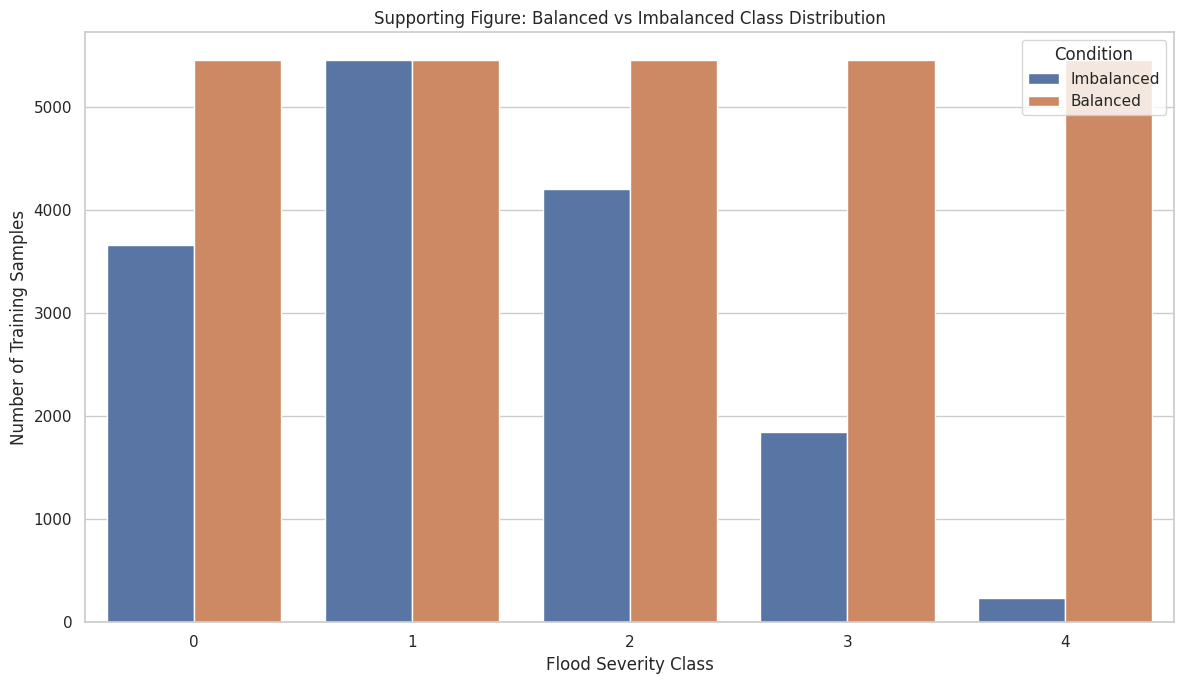

In [48]:
balance_distribution = pd.DataFrame({

    "Condition":
        (
            ["Imbalanced"] * len(classes)
            +
            ["Balanced"] * len(classes)
        ),

    "Class":
        list(classes) * 2,

    "Count":
        [
            np.sum(
                y_train_original_for_balance
                == c
            )
            for c in classes
        ]
        +
        [
            np.sum(
                y_train_smote
                == c
            )
            for c in classes
        ]
})

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=balance_distribution,
    x="Class",
    y="Count",
    hue="Condition"
)

plt.title(
    "Supporting Figure: Balanced vs Imbalanced Class Distribution"
)

plt.xlabel(
    "Flood Severity Class"
)

plt.ylabel(
    "Number of Training Samples"
)

plt.tight_layout()
plt.show()

BALANCED AND IMBALANCED MODEL EVALUATION

In [49]:
for condition_name, (
    X_fit_original,
    y_fit
) in balance_conditions.items():

    print(
        f"\nEvaluating Condition: "
        f"{condition_name}"
    )

    for model_name, base_model in models.items():

        model = clone(
            base_model
        )

        if model_name in scaled_models:

            condition_scaler = (
                StandardScaler()
            )

            X_fit_scaled = (
                condition_scaler
                .fit_transform(
                    X_fit_original
                )
            )

            X_test_scaled_condition = (
                condition_scaler
                .transform(
                    X_test_for_balance
                )
            )

            condition_pca_components = min(
                pca_components,
                X_fit_scaled.shape[1]
            )

            condition_pca = PCA(
                n_components=
                condition_pca_components
            )

            X_fit = (
                condition_pca
                .fit_transform(
                    X_fit_scaled
                )
            )

            X_test_input = (
                condition_pca
                .transform(
                    X_test_scaled_condition
                )
            )

        else:

            X_fit = (
                X_fit_original
            )

            X_test_input = (
                X_test_for_balance
            )

        model.fit(
            X_fit,
            y_fit
        )

        y_pred = (
            model.predict(
                X_test_input
            )
        )

        if hasattr(
            model,
            "predict_proba"
        ):

            y_prob = (
                model.predict_proba(
                    X_test_input
                )
            )

        else:

            y_prob = None

        metrics = calculate_metrics(
            y_test,
            y_pred,
            y_prob
        )

        metrics["Dataset"] = (
            condition_name
        )

        metrics["Model"] = (
            model_name
        )

        balanced_records.append(
            metrics
        )

balanced_results = pd.DataFrame(
    balanced_records
)

print(
    "\nTable 7: Balanced vs Imbalanced Dataset Performance"
)

table_7 = balanced_results[
    [
        "Model",
        "Dataset",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "ROC-AUC",
        "Balanced Accuracy",
        "Sensitivity",
        "Specificity",
        "MCC"
    ]
]

display(
    table_7.style.format(
        {
            "Accuracy": "{:.4f}",
            "Macro Precision": "{:.4f}",
            "Macro Recall": "{:.4f}",
            "Macro F1": "{:.4f}",
            "Weighted F1": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}",
            "MCC": "{:.4f}"
        }
    )
)


Evaluating Condition: Imbalanced

Evaluating Condition: Balanced

Table 7: Balanced vs Imbalanced Dataset Performance


,Model,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC,Balanced Accuracy,Sensitivity,Specificity,MCC
0,Logistic Regression,Imbalanced,0.8025,0.6945,0.6886,0.6693,0.8220,0.9423,0.6886,0.6886,0.9516,0.7378
1,KNN,Imbalanced,0.7250,0.5895,0.5593,0.5680,0.7147,0.8805,0.5593,0.5593,0.9215,0.6188
2,SVM-RBF,Imbalanced,0.8702,0.8047,0.8244,0.8138,0.8707,0.9481,0.8244,0.8244,0.9654,0.8235
3,Random Forest,Imbalanced,0.8815,0.8489,0.8119,0.8252,0.8805,0.9539,0.8119,0.8119,0.9679,0.8383
4,XGBoost,Imbalanced,0.8768,0.8786,0.8040,0.8306,0.8757,0.9469,0.8040,0.8040,0.9657,0.8308
5,LightGBM,Imbalanced,0.8770,0.8717,0.7981,0.8241,0.8757,0.9473,0.7981,0.7981,0.9657,0.8311
6,CatBoost,Imbalanced,0.8838,0.8799,0.8217,0.8445,0.8830,0.9506,0.8217,0.8217,0.9677,0.8405
7,Extra Trees,Imbalanced,0.8710,0.8749,0.7653,0.7940,0.8685,0.9491,0.7653,0.7653,0.9641,0.8227
8,Hist Gradient Boosting,Imbalanced,0.8768,0.8777,0.7997,0.8267,0.8755,0.9475,0.7997,0.7997,0.9657,0.8308
9,Gradient Boosting,Imbalanced,0.8745,0.8472,0.7999,0.8176,0.8735,0.9482,0.7999,0.7999,0.9655,0.8280


FIGURE 9: BALANCED AND IMBALANCED PERFORMANCE


Figure 9: Performance Metrics on Balanced and Imbalanced Data Using All Implemented Algorithms


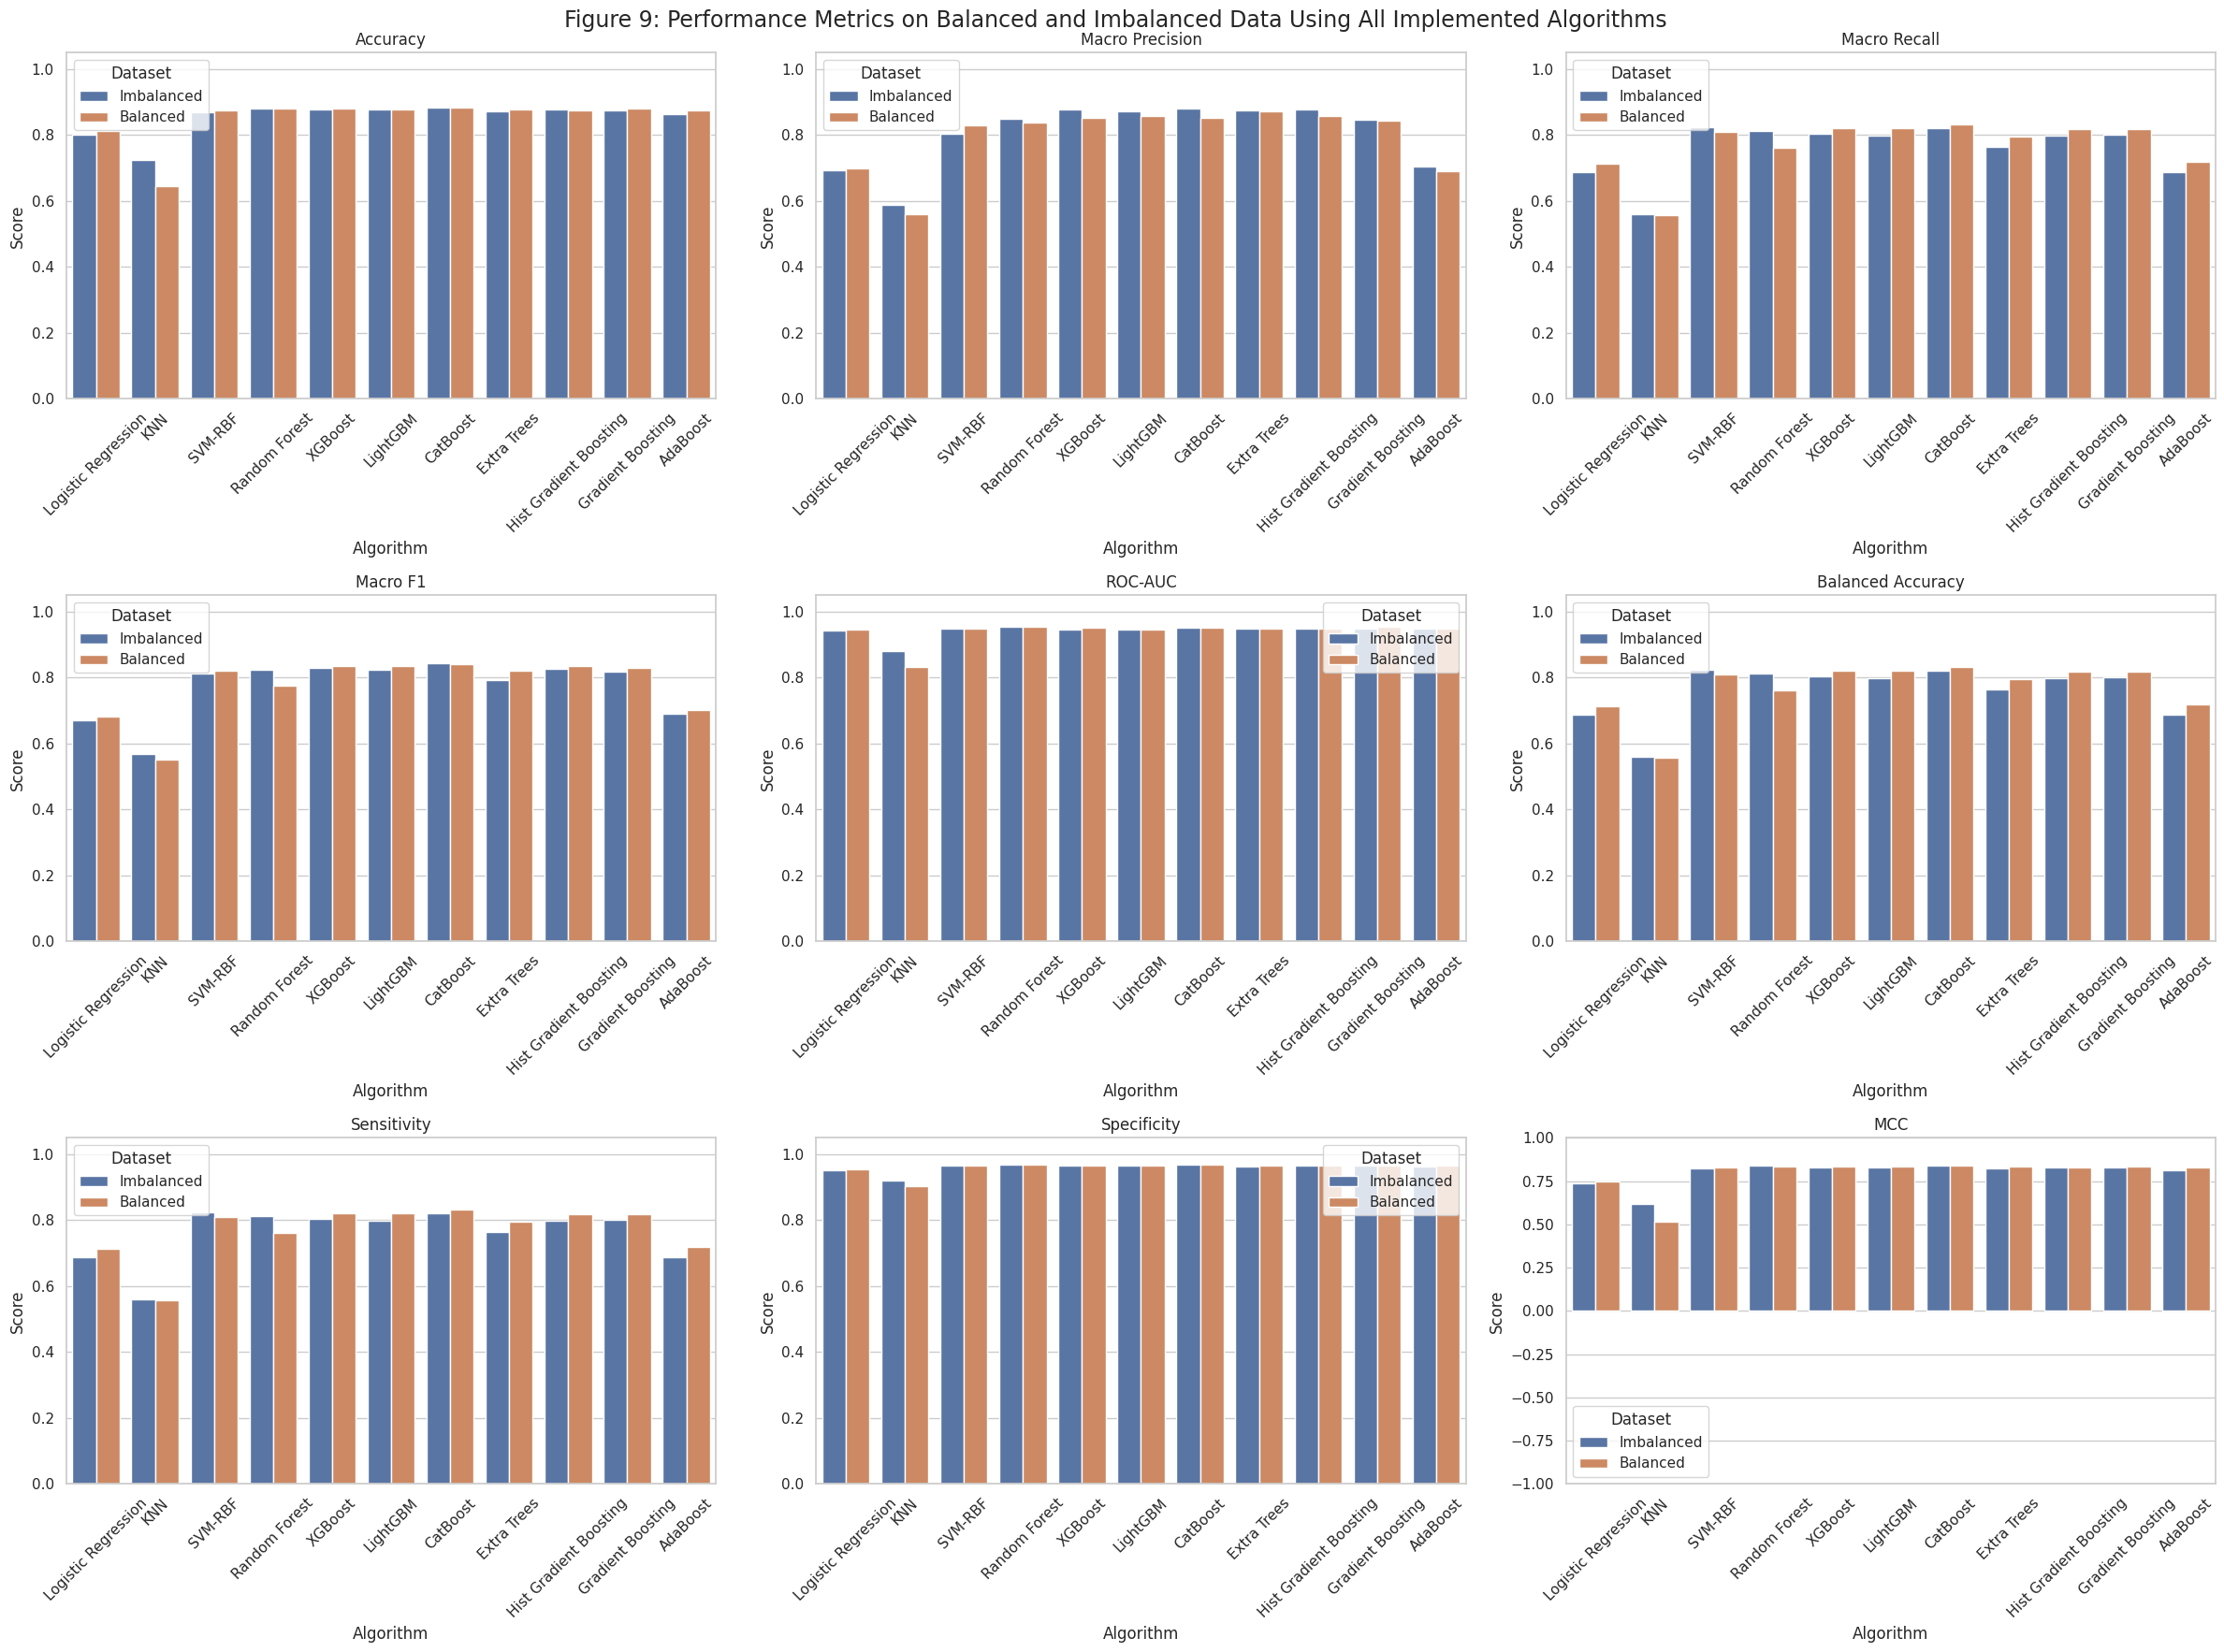

In [50]:
print(
    "\nFigure 9: Performance Metrics on Balanced and Imbalanced Data Using All Implemented Algorithms"
)

balanced_plot_metrics = [

    "Accuracy",

    "Macro Precision",

    "Macro Recall",

    "Macro F1",

    "ROC-AUC",

    "Balanced Accuracy",

    "Sensitivity",

    "Specificity",

    "MCC"
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(24, 18)
)

for ax, metric in zip(
    axes.ravel(),
    balanced_plot_metrics
):

    sns.barplot(
        data=balanced_results,
        x="Model",
        y=metric,
        hue="Dataset",
        ax=ax
    )

    ax.set_title(
        metric
    )

    ax.set_xlabel(
        "Algorithm"
    )

    ax.set_ylabel(
        "Score"
    )

    if metric != "MCC":

        ax.set_ylim(
            0,
            1.05
        )

    else:

        ax.set_ylim(
            -1,
            1
        )

    ax.tick_params(
        axis="x",
        rotation=45
    )

plt.suptitle(
    "Figure 9: Performance Metrics on Balanced and Imbalanced Data Using All Implemented Algorithms",
    fontsize=17
)

plt.tight_layout()
plt.show()

AUTOMATIC BEST MODEL SELECTION

In [51]:
print(
    "\n23. AUTOMATIC BEST MODEL SELECTION"
)

ranking_columns = [

    "Mean_F1",

    "Mean_ROC_AUC",

    "Mean_Balanced_Accuracy",

    "Mean_Accuracy",

    "Mean_MCC"
]

model_ranking = (
    validation_summary
    .sort_values(
        ranking_columns,
        ascending=False
    )
    .copy()
)

model_ranking["Rank"] = (
    np.arange(
        1,
        len(model_ranking) + 1
    )
)

model_ranking = (
    model_ranking
    .sort_values(
        "Rank"
    )
)

print(
    "\nTable 8: Automatic Model Ranking"
)

display(
    model_ranking[
        [
            "Rank",
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Sensitivity",
            "Mean_Specificity",
            "Mean_MCC"
        ]
    ].style.format(
        "{:.4f}"
    )
)

best_model_name = (
    model_ranking.index[0]
)

print(
    "\nAutomatically Selected Best Model:",
    best_model_name
)


23. AUTOMATIC BEST MODEL SELECTION

Table 8: Automatic Model Ranking


,Rank,Mean_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Mean_ROC_AUC,Mean_Balanced_Accuracy,Mean_Sensitivity,Mean_Specificity,Mean_MCC
Model,,,,,,,,,,
CatBoost,1.0000,0.8884,0.8584,0.7997,0.8209,0.9423,0.7997,0.7997,0.9690,0.8464
Hist Gradient Boosting,2.0000,0.8826,0.8502,0.7914,0.8125,0.9391,0.7914,0.7914,0.9674,0.8385
XGBoost,3.0000,0.8825,0.8531,0.7903,0.8123,0.9398,0.7903,0.7903,0.9674,0.8384
Gradient Boosting,4.0000,0.8836,0.8314,0.7973,0.8111,0.9397,0.7973,0.7973,0.9679,0.8400
LightGBM,5.0000,0.8812,0.8504,0.7891,0.8111,0.9387,0.7891,0.7891,0.9670,0.8366
Random Forest,6.0000,0.8828,0.8330,0.7914,0.8046,0.9368,0.7914,0.7914,0.9682,0.8396
SVM-RBF,7.0000,0.8717,0.7827,0.8096,0.7938,0.9408,0.8096,0.8096,0.9658,0.8249
Extra Trees,8.0000,0.8798,0.8642,0.7502,0.7739,0.9414,0.7502,0.7502,0.9664,0.8343
Logistic Regression,9.0000,0.7892,0.6799,0.6603,0.6465,0.9236,0.6603,0.6603,0.9485,0.7210



Automatically Selected Best Model: CatBoost


MODEL RANKING GRAPH

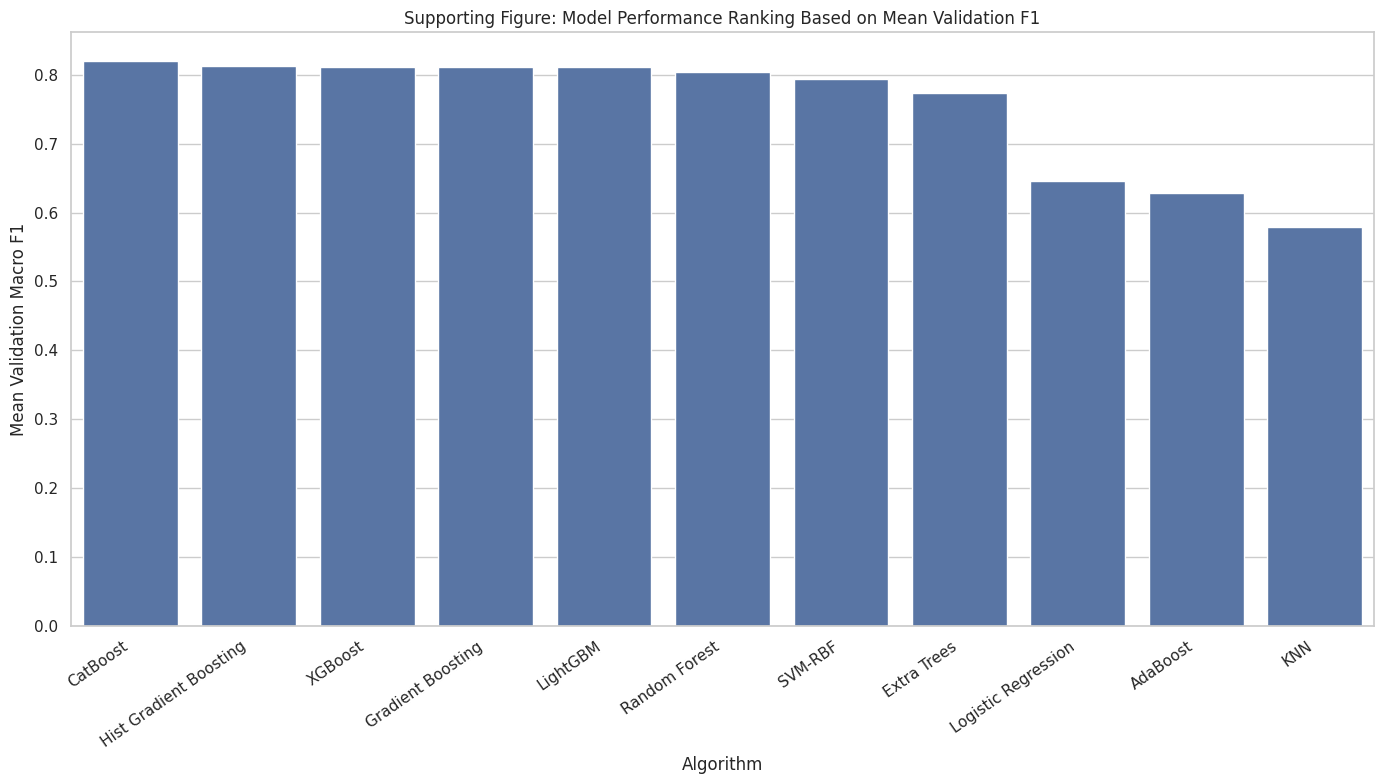

In [52]:
ranking_plot = (
    model_ranking
    .reset_index()
)

plt.figure(
    figsize=(14, 8)
)

sns.barplot(
    data=ranking_plot,
    x="Model",
    y="Mean_F1"
)

plt.title(
    "Supporting Figure: Model Performance Ranking Based on Mean Validation F1"
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Mean Validation Macro F1"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

FINAL TRAINING OF ALL MODELS

In [53]:
print(
    "\n24. FINAL TRAINING AND TEST-SET EVALUATION"
)

final_models = {}

final_predictions = {}

final_probabilities = {}

final_metrics_records = {}

for model_name, base_model in models.items():

    model = clone(
        base_model
    )

    if model_name in scaled_models:

        model_scaler = (
            StandardScaler()
        )

        X_train_model = (
            model_scaler
            .fit_transform(
                X_train_feature_matrix
            )
        )

        X_test_model = (
            model_scaler
            .transform(
                X_test_feature_matrix
            )
        )

        model_pca = PCA(
            n_components=min(
                pca_components,
                X_train_model.shape[1]
            )
        )

        X_train_model = (
            model_pca
            .fit_transform(
                X_train_model
            )
        )

        X_test_model = (
            model_pca
            .transform(
                X_test_model
            )
        )

    else:

        model_scaler = None
        model_pca = None

        X_train_model = (
            X_train_feature_matrix
        )

        X_test_model = (
            X_test_feature_matrix
        )

    model.fit(
        X_train_model,
        y_train_clean
    )

    y_pred = (
        model.predict(
            X_test_model
        )
    )

    if hasattr(
        model,
        "predict_proba"
    ):

        y_prob = (
            model.predict_proba(
                X_test_model
            )
        )

    else:

        y_prob = None

    metrics = calculate_metrics(
        y_test,
        y_pred,
        y_prob
    )

    final_models[
        model_name
    ] = {

        "model":
            model,

        "scaler":
            model_scaler,

        "pca":
            model_pca
    }

    final_predictions[
        model_name
    ] = y_pred

    final_probabilities[
        model_name
    ] = y_prob

    final_metrics_records[
        model_name
    ] = metrics

final_results = (
    pd.DataFrame(
        final_metrics_records
    ).T
)

final_results.index.name = (
    "Model"
)

final_results = (
    final_results
    .sort_values(
        [
            "Macro F1",
            "ROC-AUC",
            "Balanced Accuracy",
            "Accuracy"
        ],
        ascending=False
    )
)

print(
    "\nTable 9: Final Test-Set Classification Performance"
)

display(
    final_results.style.format(
        "{:.4f}"
    )
)


24. FINAL TRAINING AND TEST-SET EVALUATION

Table 9: Final Test-Set Classification Performance


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Balanced Accuracy,MCC,Specificity,Sensitivity,ROC-AUC
Model,,,,,,,,,,,,
CatBoost,0.8838,0.8799,0.8217,0.8445,0.8837,0.8838,0.8830,0.8217,0.8405,0.9677,0.8217,0.9506
XGBoost,0.8768,0.8786,0.8040,0.8306,0.8769,0.8768,0.8757,0.8040,0.8308,0.9657,0.8040,0.9469
Hist Gradient Boosting,0.8768,0.8777,0.7997,0.8267,0.8769,0.8768,0.8755,0.7997,0.8308,0.9657,0.7997,0.9475
Random Forest,0.8815,0.8489,0.8119,0.8252,0.8811,0.8815,0.8805,0.8119,0.8383,0.9679,0.8119,0.9539
LightGBM,0.8770,0.8717,0.7981,0.8241,0.8768,0.8770,0.8757,0.7981,0.8311,0.9657,0.7981,0.9473
Gradient Boosting,0.8745,0.8472,0.7999,0.8176,0.8738,0.8745,0.8735,0.7999,0.8280,0.9655,0.7999,0.9482
SVM-RBF,0.8702,0.8047,0.8244,0.8138,0.8718,0.8702,0.8707,0.8244,0.8235,0.9654,0.8244,0.9481
Extra Trees,0.8710,0.8749,0.7653,0.7940,0.8716,0.8710,0.8685,0.7653,0.8227,0.9641,0.7653,0.9491
AdaBoost,0.8640,0.7041,0.6870,0.6914,0.8519,0.8640,0.8548,0.6870,0.8134,0.9618,0.6870,0.9495


FINAL BEST MODEL

In [54]:
selected_best_model = (
    best_model_name
)

best_test_prediction = (
    final_predictions[
        selected_best_model
    ]
)

best_test_probability = (
    final_probabilities[
        selected_best_model
    ]
)

print(
    "\nAutomatically Selected Best Model:",
    selected_best_model
)


Automatically Selected Best Model: CatBoost


CONFUSION MATRICES FOR ALL MODELS


25. CONFUSION MATRICES FOR ALL MODELS


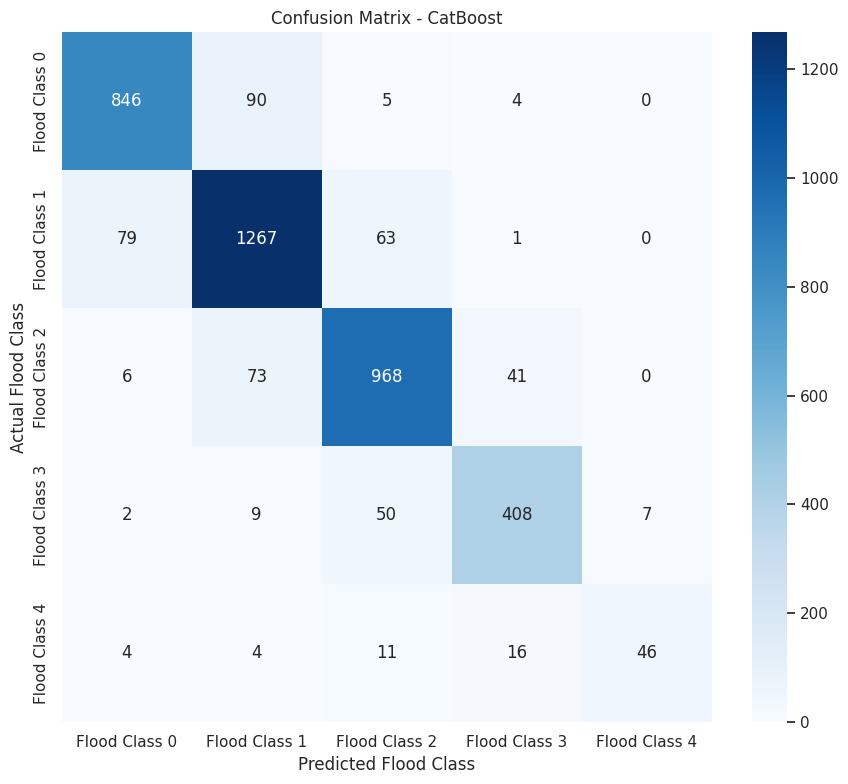

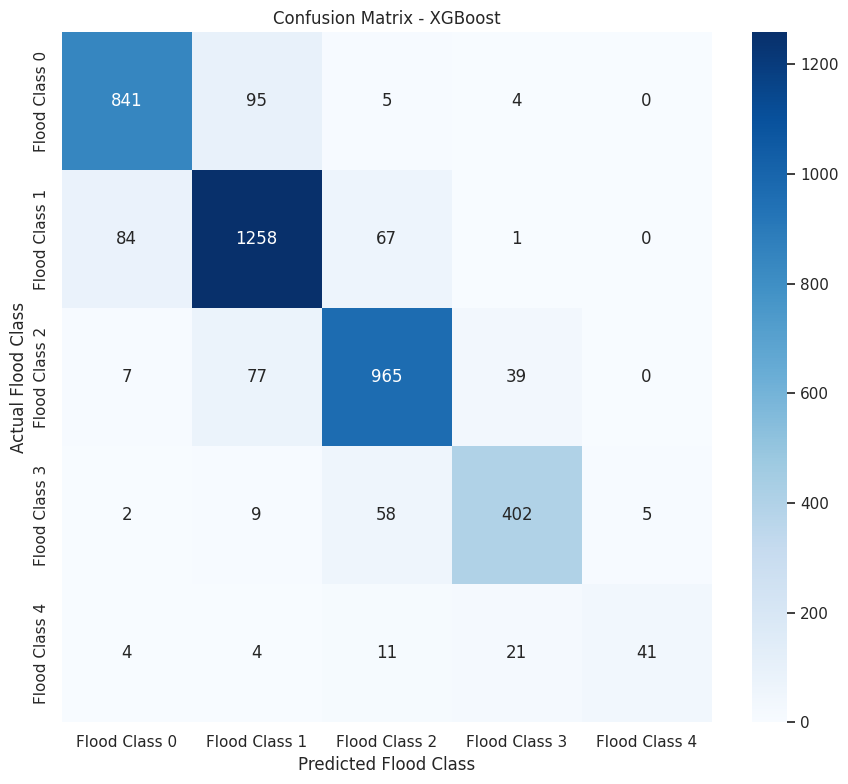

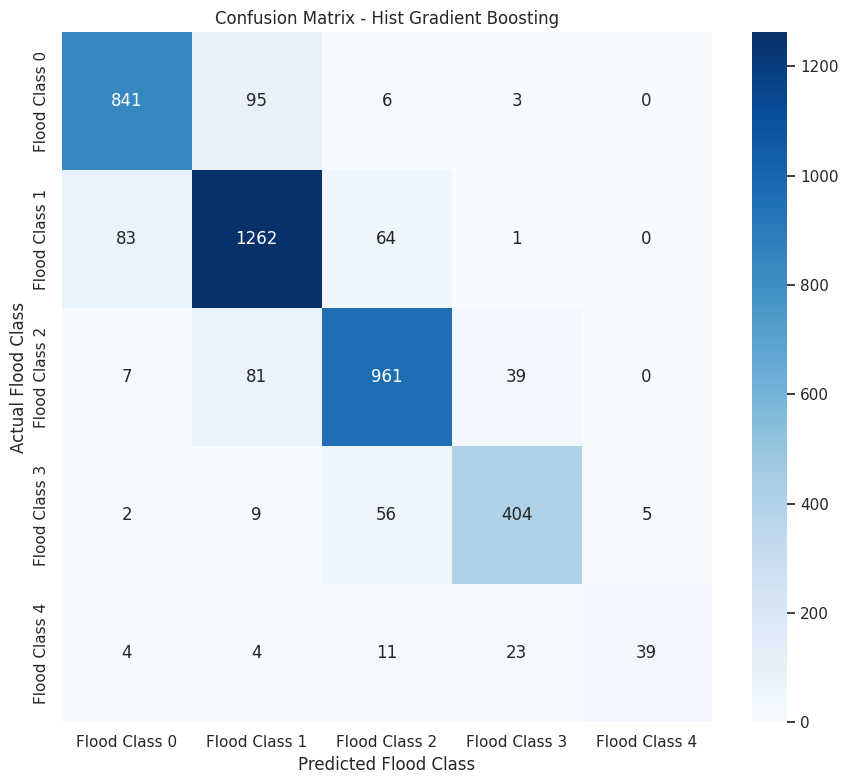

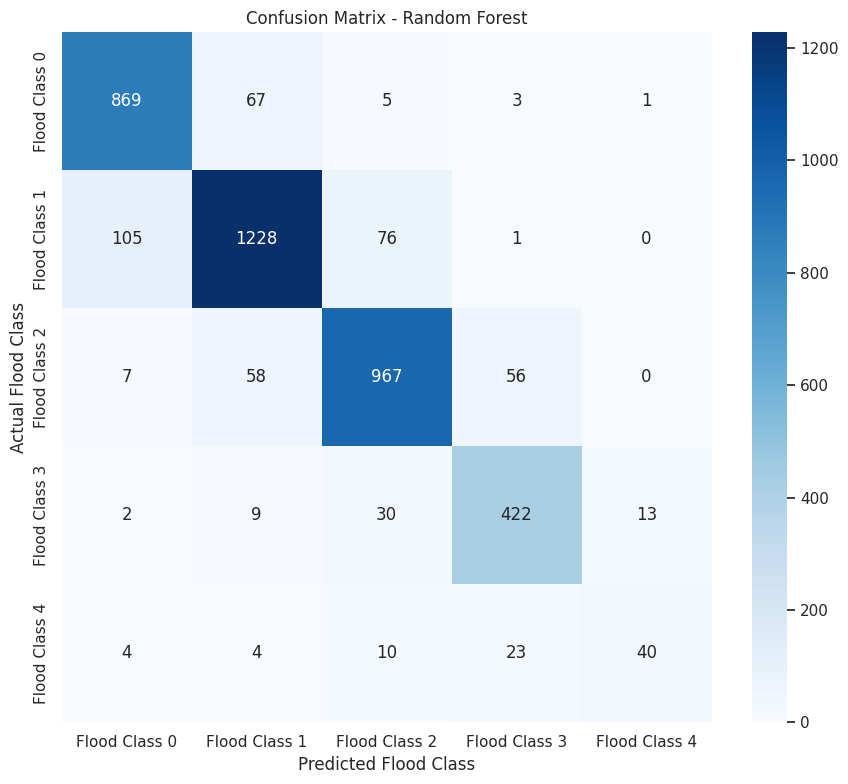

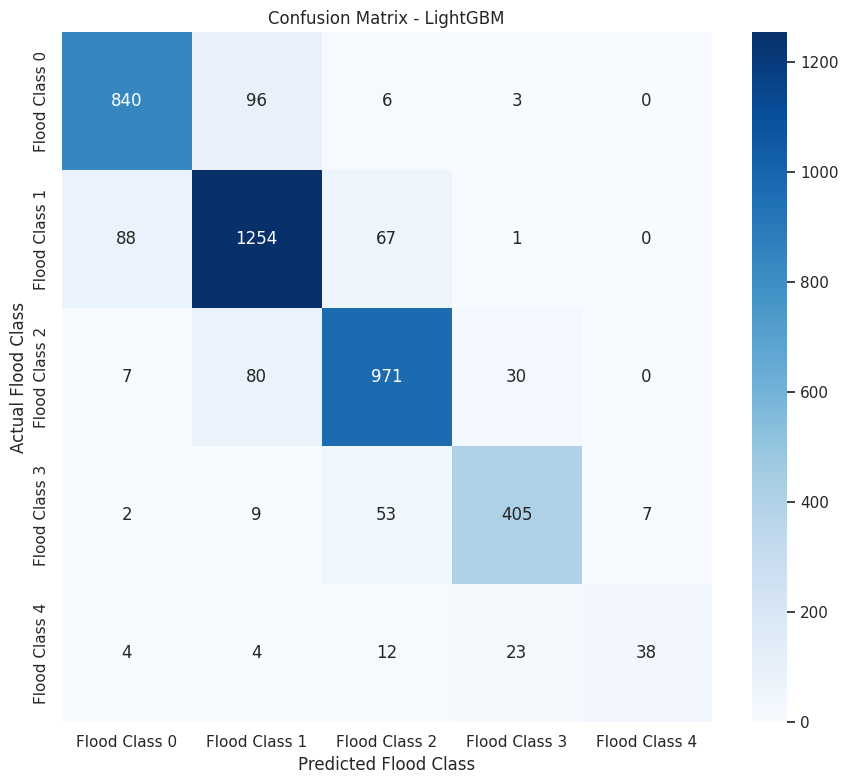

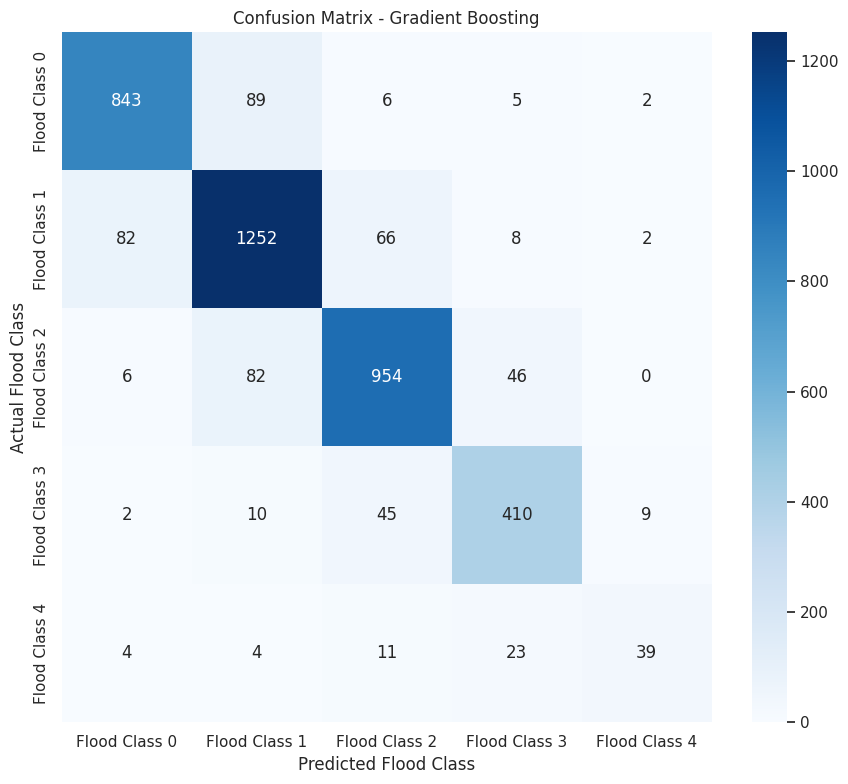

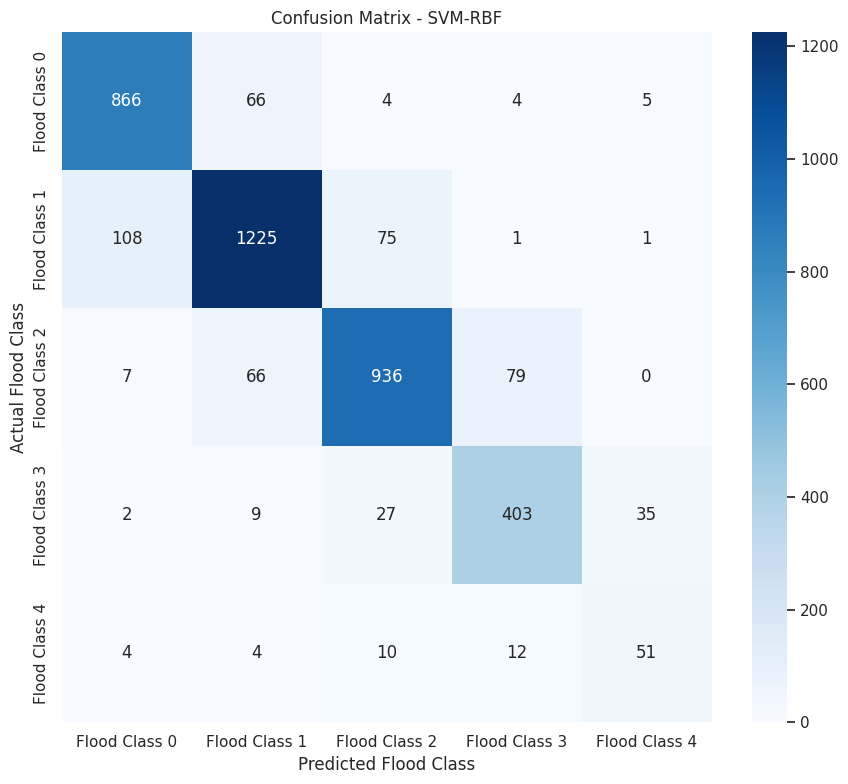

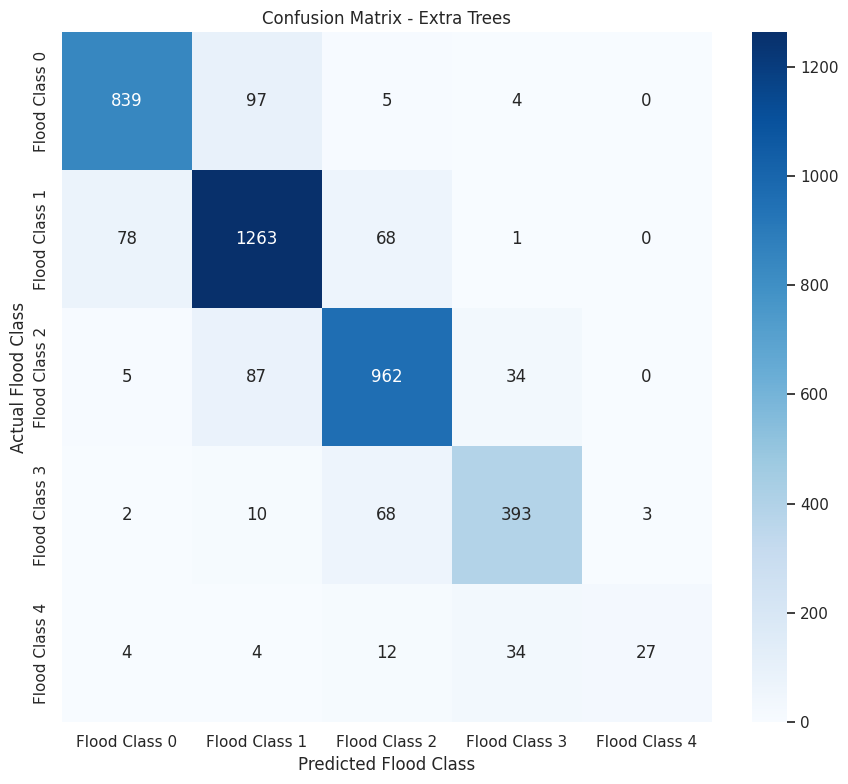

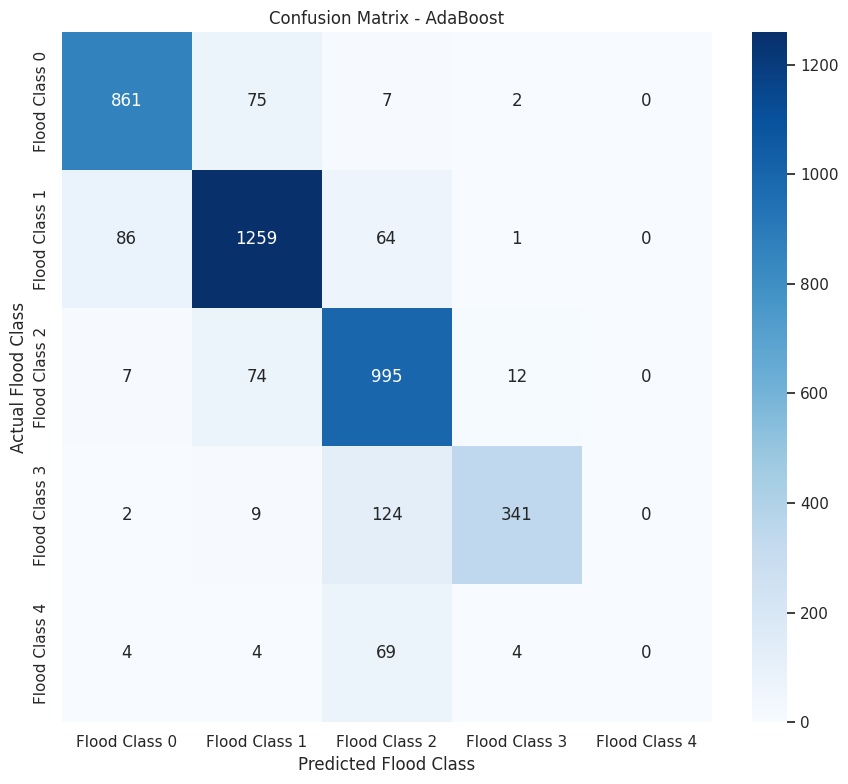

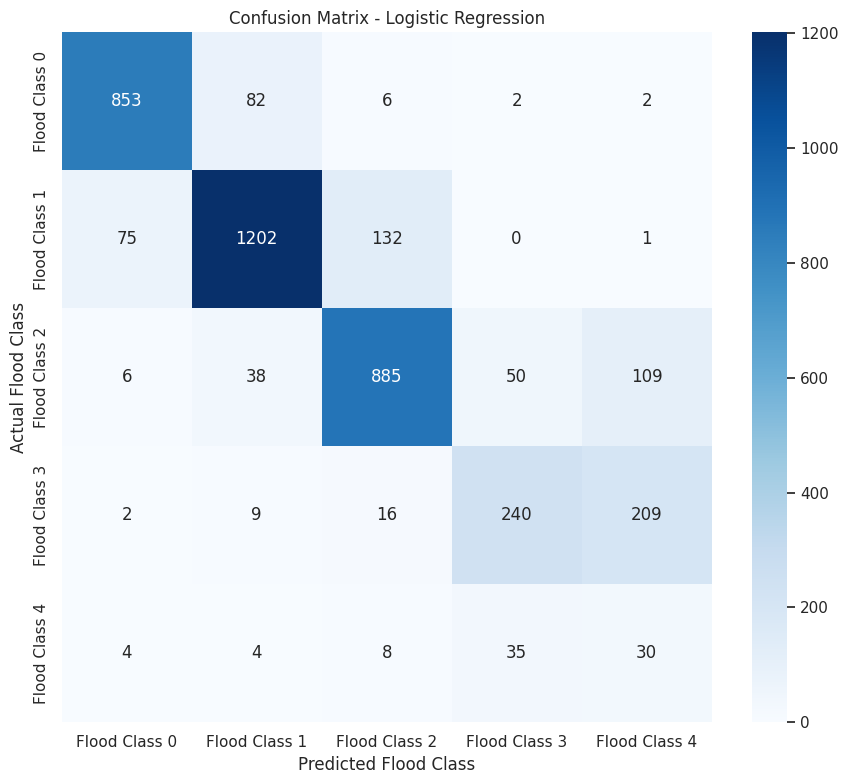

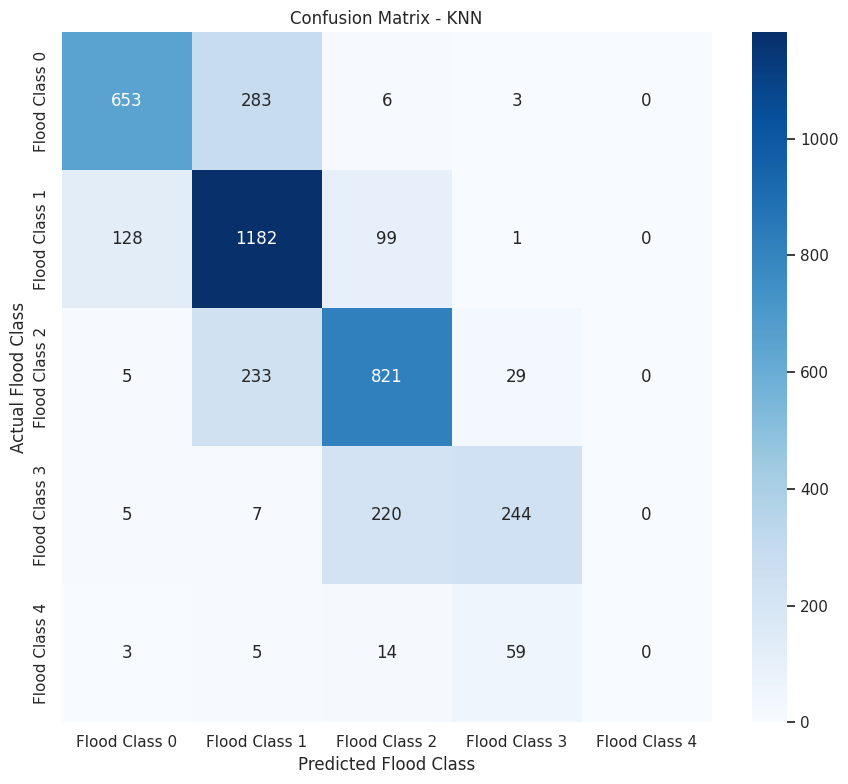

In [55]:
print(
    "\n25. CONFUSION MATRICES FOR ALL MODELS"
)

for model_name in final_results.index:

    y_pred = (
        final_predictions[
            model_name
        ]
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=classes
    )

    plt.figure(
        figsize=(9, 8)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            f"Flood Class {c}"
            for c in classes
        ],
        yticklabels=[
            f"Flood Class {c}"
            for c in classes
        ]
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel(
        "Predicted Flood Class"
    )

    plt.ylabel(
        "Actual Flood Class"
    )

    plt.tight_layout()
    plt.show()

NORMALIZED CONFUSION MATRICES

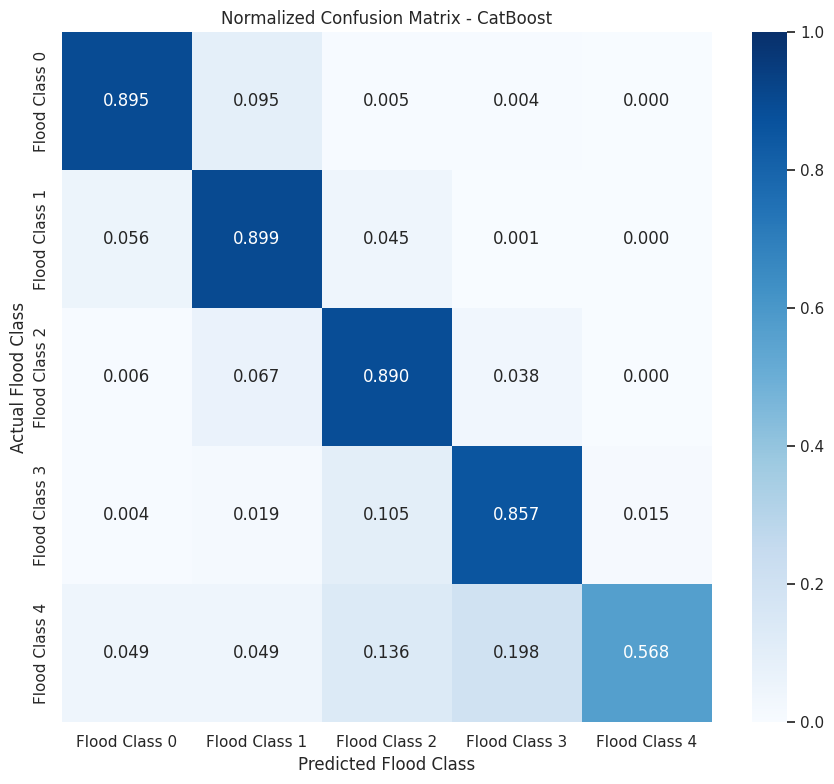

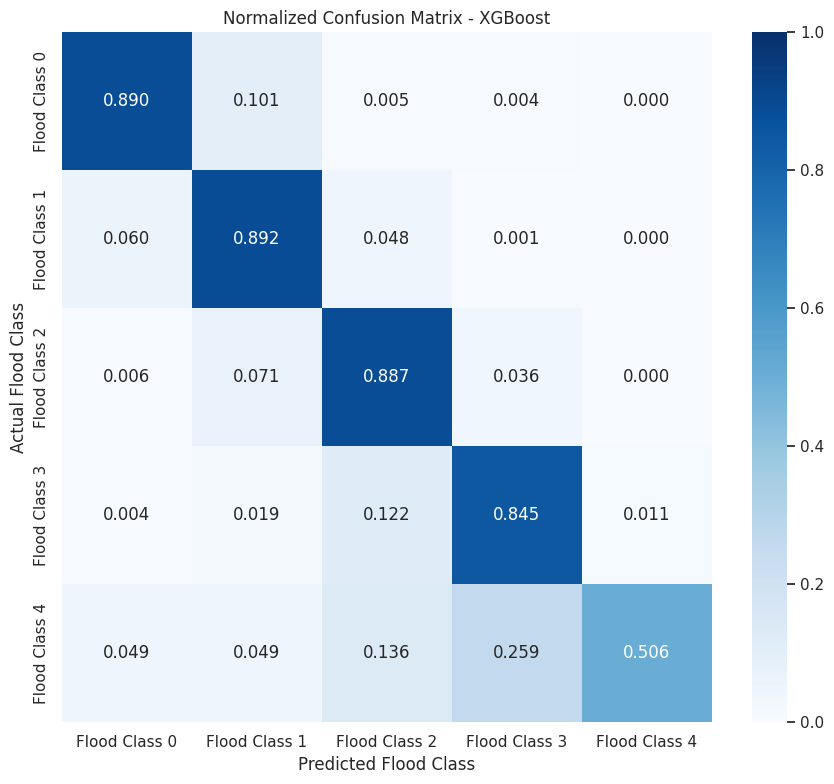

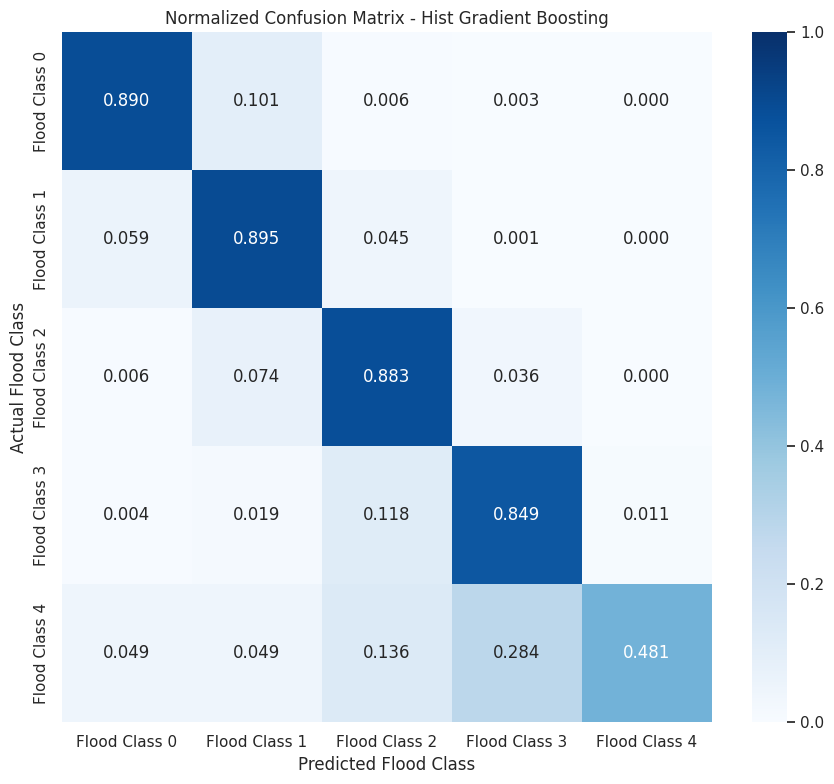

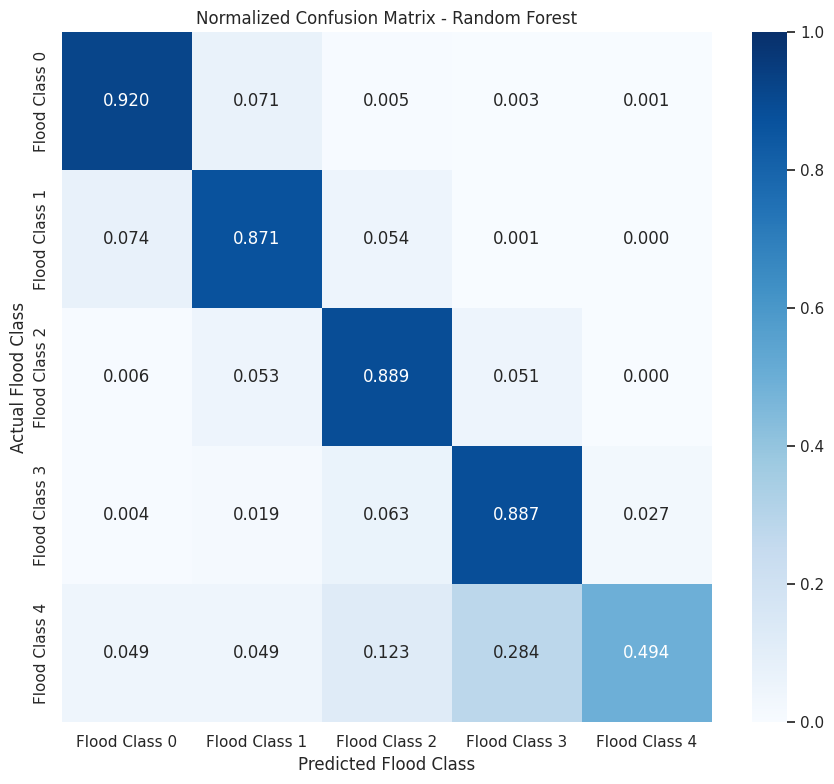

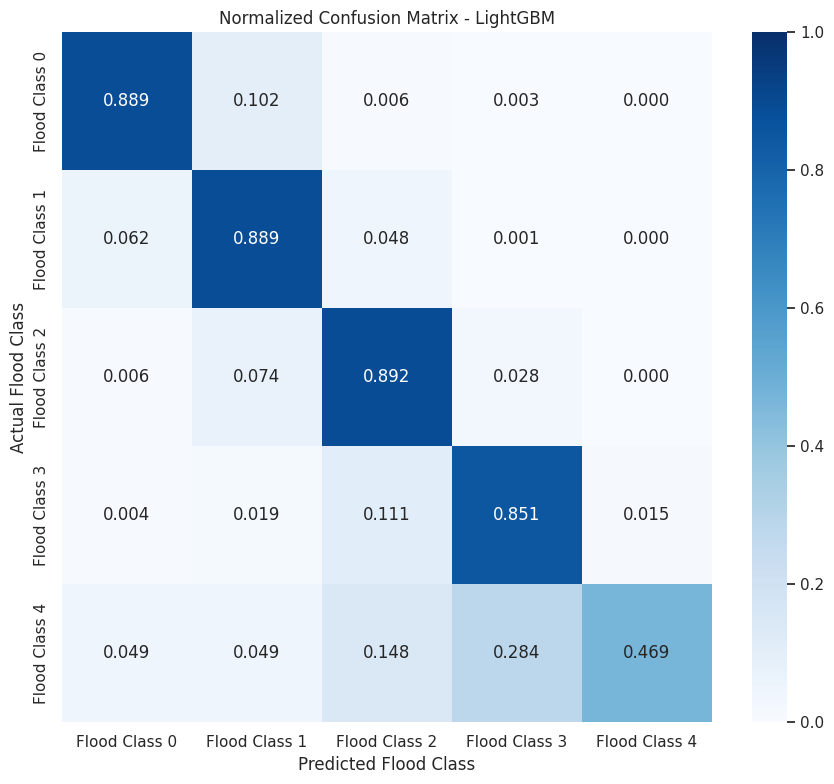

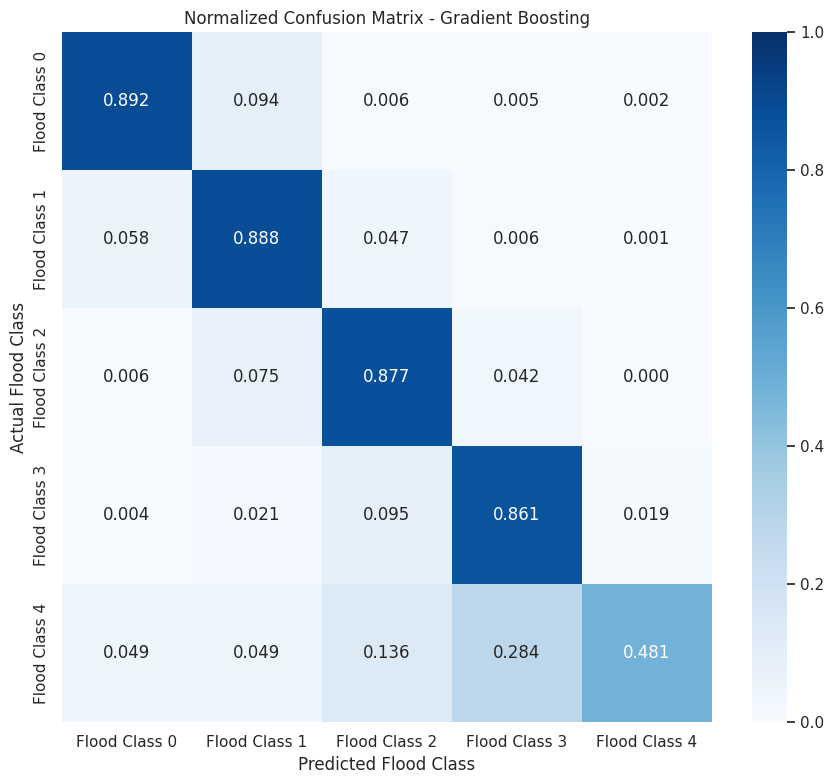

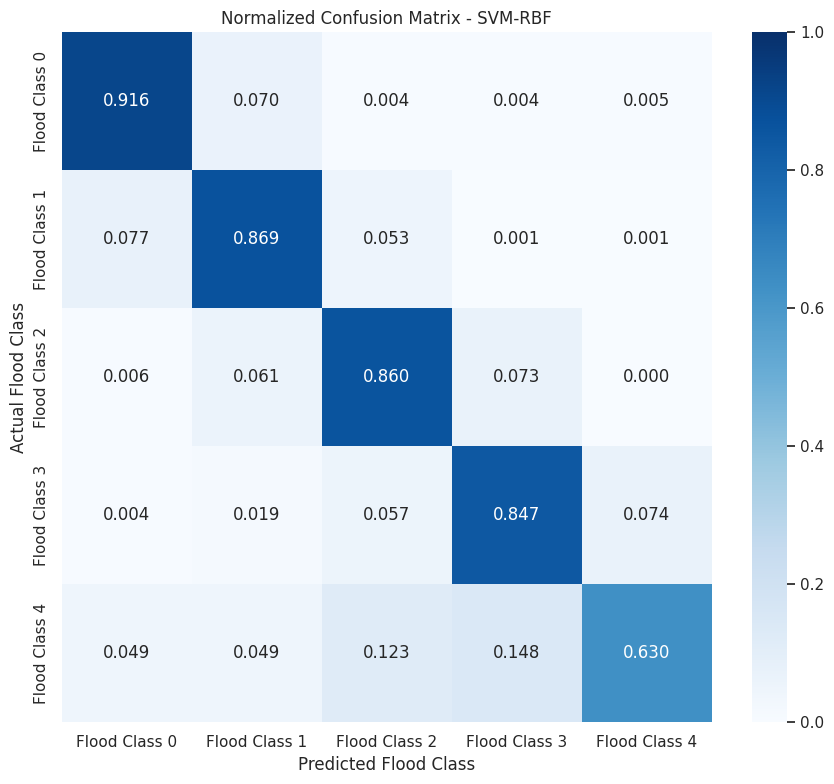

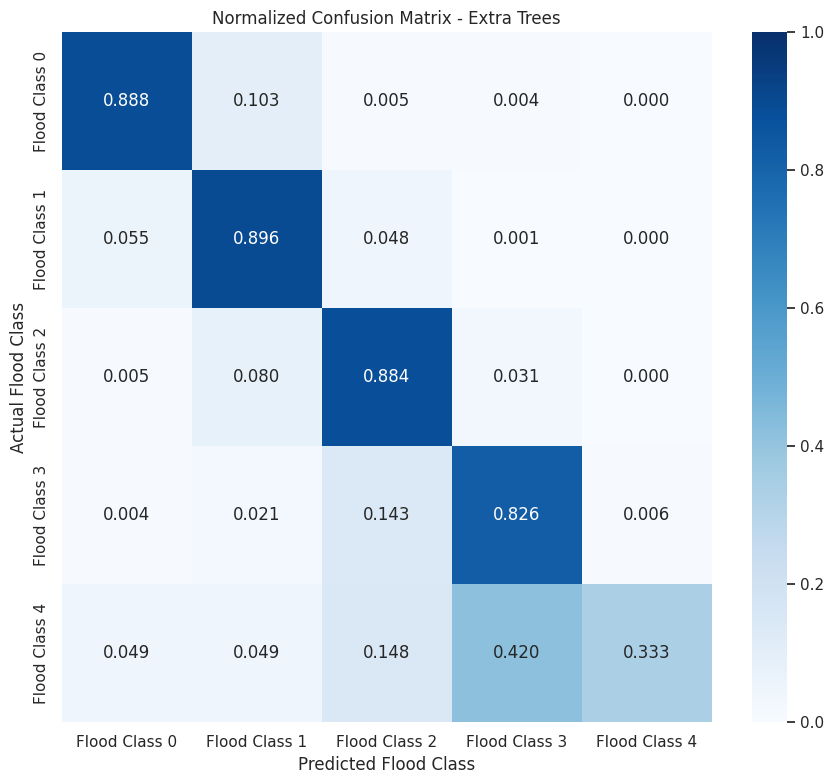

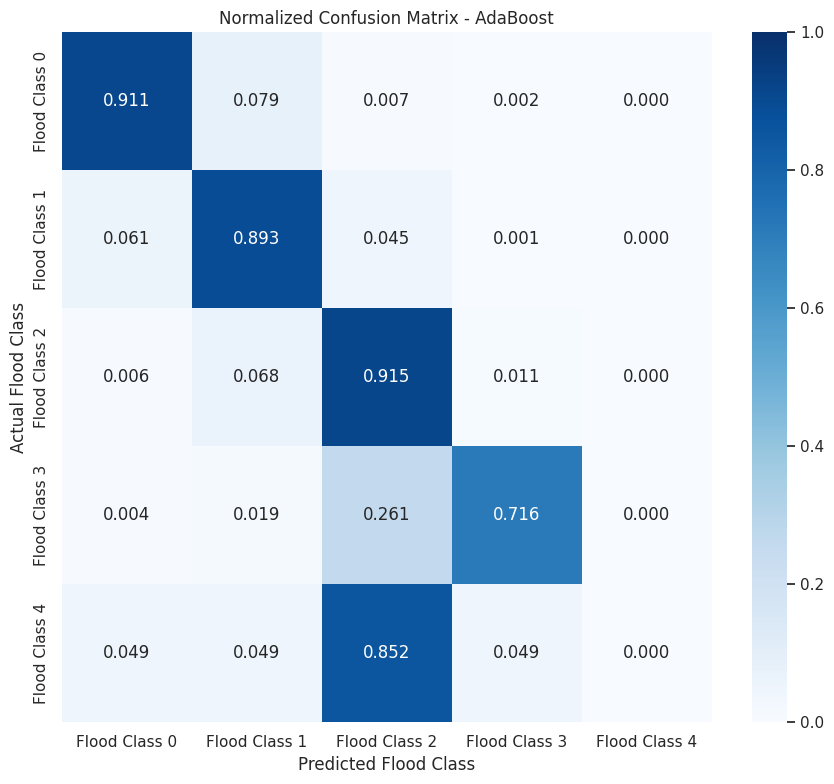

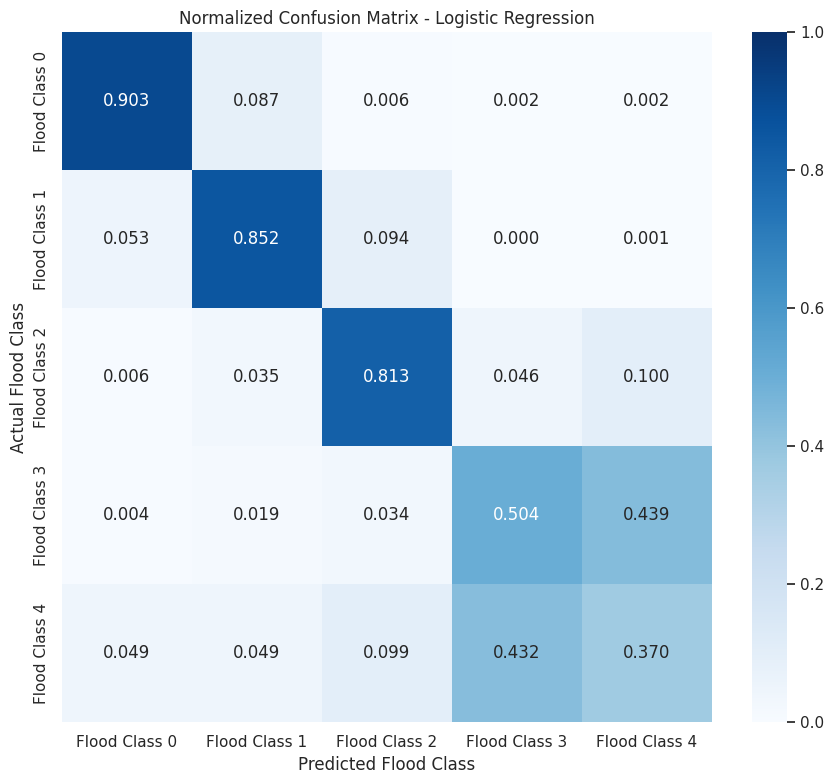

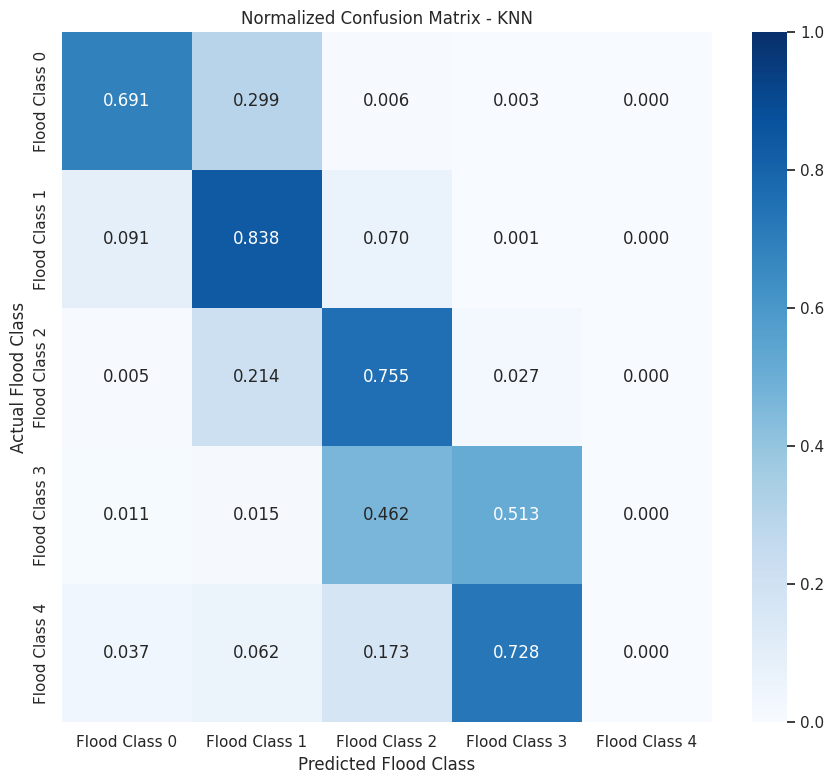

In [56]:
for model_name in final_results.index:

    y_pred = (
        final_predictions[
            model_name
        ]
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=classes
    )

    cm_normalized = (
        cm.astype(float)
        /
        np.maximum(
            cm.sum(
                axis=1,
                keepdims=True
            ),
            1
        )
    )

    plt.figure(
        figsize=(9, 8)
    )

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=[
            f"Flood Class {c}"
            for c in classes
        ],
        yticklabels=[
            f"Flood Class {c}"
            for c in classes
        ]
    )

    plt.title(
        f"Normalized Confusion Matrix - {model_name}"
    )

    plt.xlabel(
        "Predicted Flood Class"
    )

    plt.ylabel(
        "Actual Flood Class"
    )

    plt.tight_layout()
    plt.show()

FINAL CLASS-WISE TEST PERFORMANCE

In [57]:
print(
    "\n26. FINAL CLASS-WISE TEST PERFORMANCE"
)

best_class_test_metrics = (
    classwise_metrics(
        y_test,
        best_test_prediction,
        best_test_probability,
        selected_best_model
    )
)

display(
    best_class_test_metrics.style.format(
        {
            "Precision": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}",
            "F1-Score": "{:.4f}",
            "ROC-AUC": "{:.4f}"
        }
    )
)


26. FINAL CLASS-WISE TEST PERFORMANCE


,Model,Class,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC,Support
0,CatBoost,0,0.9029,0.8952,0.9702,0.8990,0.9809,945
1,CatBoost,1,0.8780,0.8986,0.9320,0.8882,0.9726,1410
2,CatBoost,2,0.8824,0.8897,0.9557,0.8860,0.9748,1088
3,CatBoost,3,0.8681,0.8571,0.9824,0.8626,0.9724,476
4,CatBoost,4,0.8679,0.5679,0.9982,0.6866,0.8522,81


FINAL CONFUSION MATRIX

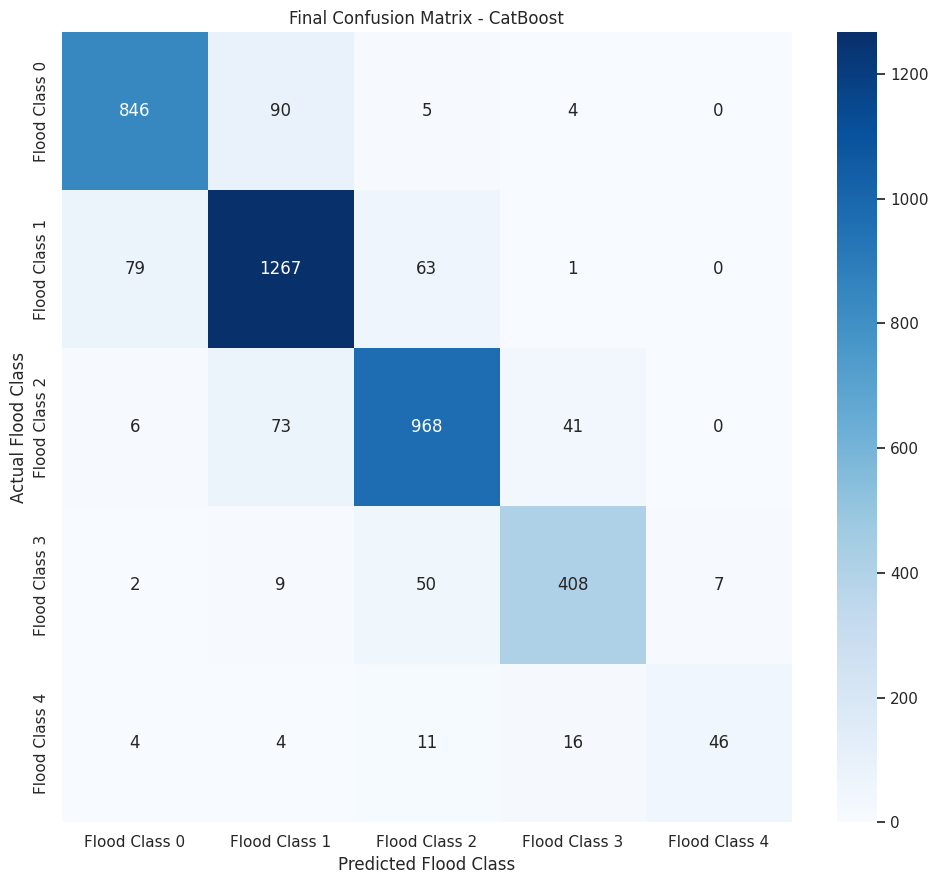

In [58]:
best_cm = confusion_matrix(
    y_test,
    best_test_prediction,
    labels=classes
)

plt.figure(
    figsize=(10, 9)
)

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        f"Flood Class {c}"
        for c in classes
    ],
    yticklabels=[
        f"Flood Class {c}"
        for c in classes
    ]
)

plt.title(
    f"Final Confusion Matrix - {selected_best_model}"
)

plt.xlabel(
    "Predicted Flood Class"
)

plt.ylabel(
    "Actual Flood Class"
)

plt.tight_layout()
plt.show()

FINAL ROC CURVES FOR BEST MODEL


27. FINAL ROC CURVES FOR AUTOMATICALLY SELECTED BEST MODEL


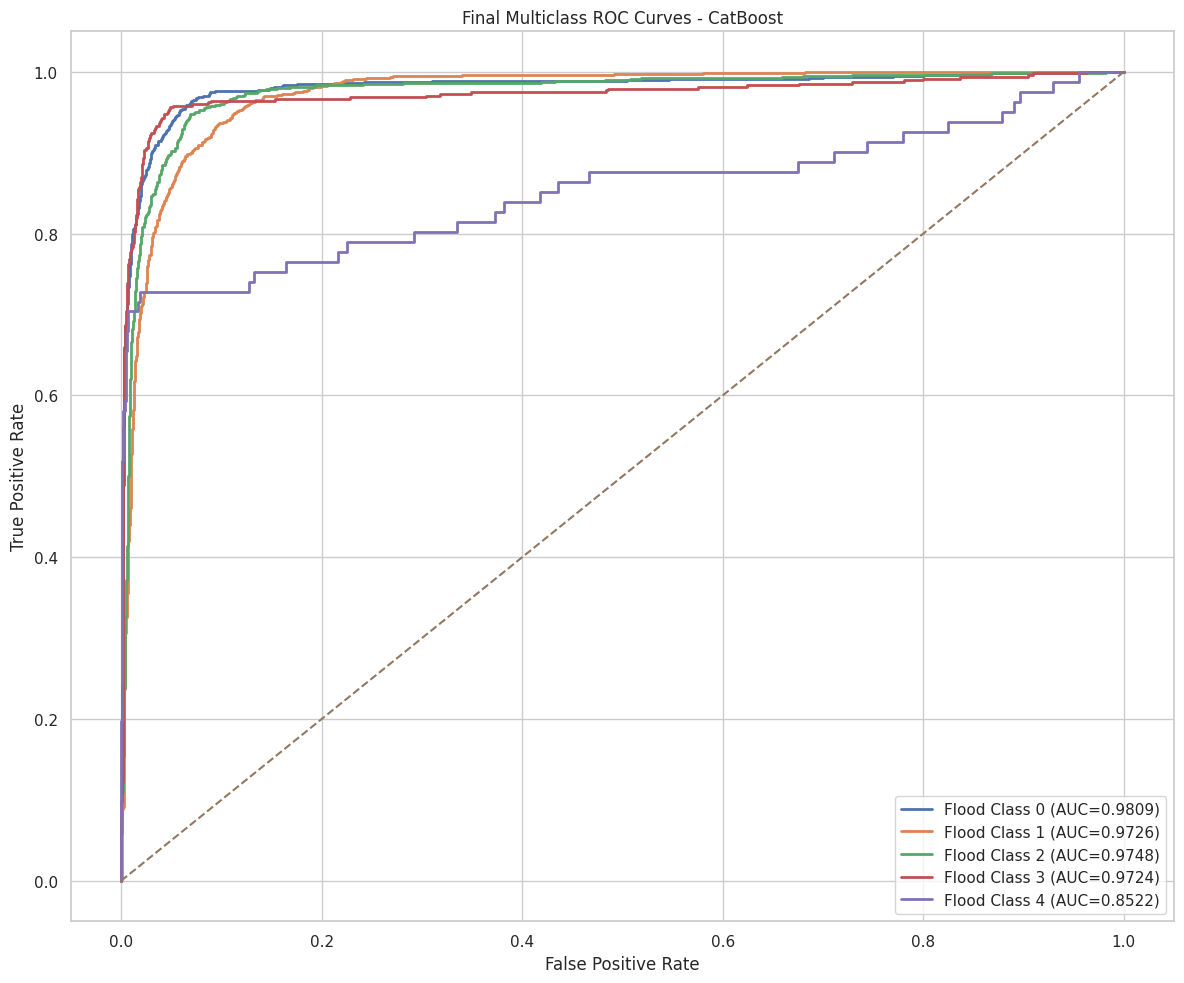

Final Macro ROC-AUC: 0.9506


In [59]:
print(
    "\n27. FINAL ROC CURVES FOR AUTOMATICALLY SELECTED BEST MODEL"
)

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

plt.figure(
    figsize=(12, 10)
)

final_class_auc = {}

for i, class_label in enumerate(
    classes
):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        best_test_probability[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    final_class_auc[
        class_label
    ] = class_auc

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"Flood Class {class_label} "
            f"(AUC={class_auc:.4f})"
        )
    )

macro_auc = np.mean(
    list(
        final_class_auc.values()
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    f"Final Multiclass ROC Curves - {selected_best_model}"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()
plt.show()

print(
    "Final Macro ROC-AUC:",
    round(macro_auc, 4)
)

FIGURE 10: FEATURE IMPORTANCE ANALYSIS


Figure 10: Feature Importance Analysis Using Best Selected Algorithm

Top Features:


,Feature,Importance,Method
0,rainfall_intensity_mmhr,75.883624,Native Feature Importance
1,drain_blockage_pct,3.774089,Native Feature Importance
2,slope_pct,3.547047,Native Feature Importance
3,elevation_m,3.497677,Native Feature Importance
4,drainage_capacity_m3s,3.319297,Native Feature Importance
5,temperature_c,3.286636,Native Feature Importance
6,impervious_surface_pct,3.060212,Native Feature Importance
7,land_use_code,1.892787,Native Feature Importance
8,land_use_name_Silt,0.488684,Native Feature Importance
9,land_use_name_Sandy,0.385399,Native Feature Importance


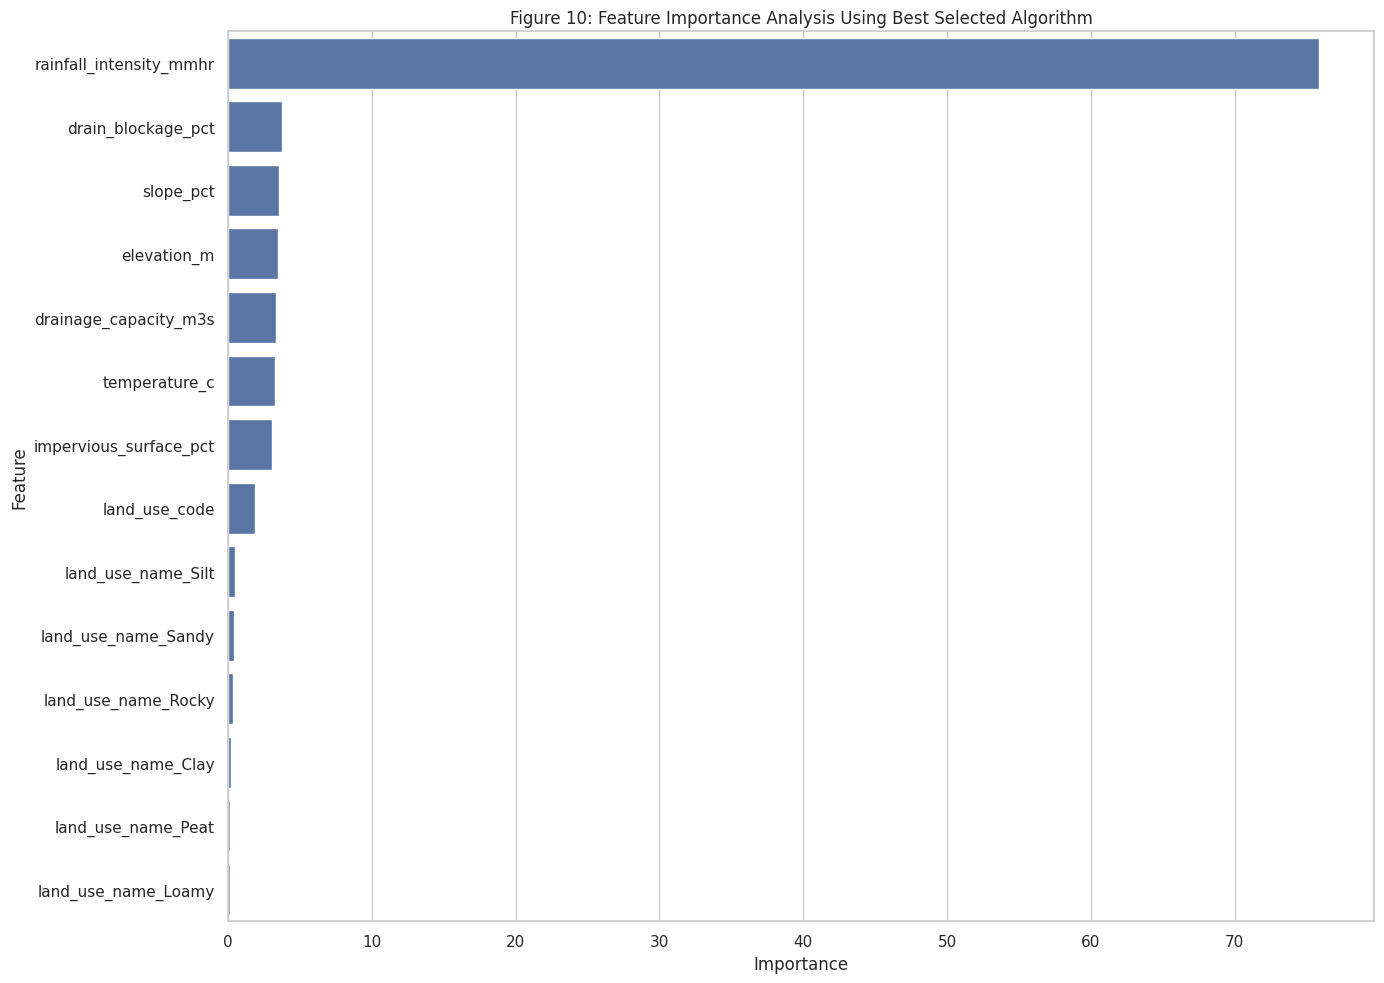

In [60]:
print(
    "\nFigure 10: Feature Importance Analysis Using Best Selected Algorithm"
)

best_model_object = (
    final_models[
        selected_best_model
    ]["model"]
)

best_model_scaler = (
    final_models[
        selected_best_model
    ]["scaler"]
)

best_model_pca = (
    final_models[
        selected_best_model
    ]["pca"]
)

def calculate_original_feature_importance():

    model_name = (
        selected_best_model
    )

    native_tree_models = [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Extra Trees",
        "Gradient Boosting",
        "Hist Gradient Boosting",
        "AdaBoost"
    ]

    if model_name in native_tree_models:

        if hasattr(
            best_model_object,
            "feature_importances_"
        ):

            importance = (
                best_model_object
                .feature_importances_
            )

            return pd.DataFrame({

                "Feature":
                    all_selected_feature_names,

                "Importance":
                    importance,

                "Method":
                    "Native Feature Importance"
            })

    if model_name == "Logistic Regression":

        coefficient_importance = (
            np.mean(
                np.abs(
                    best_model_object.coef_
                ),
                axis=0
            )
        )

        if best_model_pca is not None:

            loading_matrix = (
                best_model_pca
                .components_
            )

            original_contribution = (
                np.abs(
                    loading_matrix
                ).T
                @
                coefficient_importance
            )

            return pd.DataFrame({

                "Feature":
                    all_selected_feature_names,

                "Importance":
                    original_contribution,

                "Method":
                    "PCA Loading-Weighted Coefficient Importance"
            })

        return pd.DataFrame({

            "Feature":
                all_selected_feature_names,

            "Importance":
                coefficient_importance,

            "Method":
                "Absolute Coefficient Magnitude"
        })

    X_test_transformed = (
        best_model_pca.transform(
            best_model_scaler.transform(
                X_test_feature_matrix
            )
        )
        if best_model_pca is not None
        else X_test_feature_matrix
    )

    permutation_result = (
        permutation_importance(
            best_model_object,
            X_test_transformed,
            y_test,
            scoring="f1_macro",
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )

    component_importance = (
        permutation_result
        .importances_mean
    )

    if best_model_pca is not None:

        loading_matrix = (
            best_model_pca
            .components_
        )

        original_importance = (
            np.abs(
                loading_matrix
            ).T
            @
            component_importance
        )

        return pd.DataFrame({

            "Feature":
                all_selected_feature_names,

            "Importance":
                original_importance,

            "Method":
                "PCA Loading-Weighted Permutation Importance"
        })

    return pd.DataFrame({

        "Feature":
            all_selected_feature_names,

        "Importance":
            component_importance,

        "Method":
            "Permutation Importance"
    })


feature_importance = (
    calculate_original_feature_importance()
)

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nTop Features:"
)

display(
    feature_importance.head(20)
    .style.format(
        {
            "Importance":
                "{:.6f}"
        }
    )
)

top_features = (
    feature_importance
    .head(
        min(
            15,
            len(feature_importance)
        )
    )
)

plt.figure(
    figsize=(14, 10)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Figure 10: Feature Importance Analysis Using Best Selected Algorithm"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

FINAL TEST PERFORMANCE

In [61]:
print(
    "\n28. FINAL TEST PERFORMANCE"
)

best_metrics = calculate_metrics(
    y_test,
    best_test_prediction,
    best_test_probability
)

table_10 = pd.DataFrame(
    [best_metrics],
    index=[
        selected_best_model
    ]
)

print(
    "\nTable 10: Final Test-Set Performance of Automatically Selected Best Model"
)

display(
    table_10.style.format(
        "{:.4f}"
    )
)


28. FINAL TEST PERFORMANCE

Table 10: Final Test-Set Performance of Automatically Selected Best Model


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Balanced Accuracy,MCC,Specificity,Sensitivity,ROC-AUC
CatBoost,0.8838,0.8799,0.8217,0.8445,0.8837,0.8838,0.8830,0.8217,0.8405,0.9677,0.8217,0.9506


CLASSIFICATION REPORT

In [62]:
print(
    "\n29. CLASSIFICATION REPORT"
)

print(
    classification_report(
        y_test,
        best_test_prediction,
        labels=classes,
        target_names=[
            f"Flood Class {c}"
            for c in classes
        ],
        digits=4,
        zero_division=0
    )
)


29. CLASSIFICATION REPORT
               precision    recall  f1-score   support

Flood Class 0     0.9029    0.8952    0.8990       945
Flood Class 1     0.8780    0.8986    0.8882      1410
Flood Class 2     0.8824    0.8897    0.8860      1088
Flood Class 3     0.8681    0.8571    0.8626       476
Flood Class 4     0.8679    0.5679    0.6866        81

     accuracy                         0.8838      4000
    macro avg     0.8799    0.8217    0.8445      4000
 weighted avg     0.8837    0.8838    0.8830      4000



ACTUAL VS PREDICTED OUTPUT

In [64]:
print(
    "\n30. ACTUAL VS PREDICTED OUTPUT"
)

final_prediction_output = pd.DataFrame({

    "Sample Index":
        y_test.index,

    "Actual Flood Class":
        y_test.values,

    "Predicted Flood Class":
        best_test_prediction.ravel(),

    "Prediction Correct":
        (
            y_test.values
            ==
            best_test_prediction.ravel()
        )
})

if best_test_probability is not None:

    for i, class_label in enumerate(
        classes
    ):

        final_prediction_output[
            f"Probability Class {class_label}"
        ] = (
            best_test_probability[:, i]
        )

display(
    final_prediction_output
    .head(50)
)


30. ACTUAL VS PREDICTED OUTPUT


,Sample Index,Actual Flood Class,Predicted Flood Class,Prediction Correct,Probability Class 0,Probability Class 1,Probability Class 2,Probability Class 3,Probability Class 4
0,15774,1,1,True,0.013190,0.958910,0.017116,0.006715,0.004068
1,477,1,1,True,0.007164,0.774053,0.207522,0.006496,0.004765
2,13467,3,3,True,0.002855,0.001761,0.018784,0.959521,0.017079
3,4962,0,0,True,0.962780,0.015608,0.004817,0.006332,0.010464
4,13115,3,3,True,0.002576,0.003129,0.019300,0.964489,0.010505
5,8803,1,1,True,0.323304,0.667117,0.003405,0.003377,0.002797
6,10132,1,1,True,0.010047,0.892423,0.084686,0.008112,0.004732
7,12259,3,3,True,0.006233,0.004341,0.029314,0.942933,0.017179
8,11366,2,2,True,0.003396,0.010027,0.966344,0.016700,0.003533
9,15494,3,3,True,0.002416,0.003889,0.135467,0.851458,0.006771


FINAL MODEL COMPARISON TABLE

In [65]:
print(
    "\n32. FINAL VALIDATION PERFORMANCE OF ALL IMPLEMENTED ALGORITHMS"
)

summary_table = (
    validation_summary[
        [
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Sensitivity",
            "Mean_Specificity",
            "Mean_MCC"
        ]
    ]
    .copy()
)

summary_table.columns = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1-Score",

    "ROC-AUC",

    "Balanced Accuracy",

    "Sensitivity",

    "Specificity",

    "MCC"
]

display(
    summary_table.style.format(
        "{:.4f}"
    )
)


32. FINAL VALIDATION PERFORMANCE OF ALL IMPLEMENTED ALGORITHMS


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,Sensitivity,Specificity,MCC
Model,,,,,,,,,
CatBoost,0.8884,0.8584,0.7997,0.8209,0.9423,0.7997,0.7997,0.9690,0.8464
Hist Gradient Boosting,0.8826,0.8502,0.7914,0.8125,0.9391,0.7914,0.7914,0.9674,0.8385
XGBoost,0.8825,0.8531,0.7903,0.8123,0.9398,0.7903,0.7903,0.9674,0.8384
Gradient Boosting,0.8836,0.8314,0.7973,0.8111,0.9397,0.7973,0.7973,0.9679,0.8400
LightGBM,0.8812,0.8504,0.7891,0.8111,0.9387,0.7891,0.7891,0.9670,0.8366
Random Forest,0.8828,0.8330,0.7914,0.8046,0.9368,0.7914,0.7914,0.9682,0.8396
SVM-RBF,0.8717,0.7827,0.8096,0.7938,0.9408,0.8096,0.8096,0.9658,0.8249
Extra Trees,0.8798,0.8642,0.7502,0.7739,0.9414,0.7502,0.7502,0.9664,0.8343
Logistic Regression,0.7892,0.6799,0.6603,0.6465,0.9236,0.6603,0.6603,0.9485,0.7210


DATASET AND METHODOLOGY SUMMARY

In [66]:
print(
    "\n33. DATASET AND METHODOLOGY SUMMARY"
)

table_1 = pd.DataFrame({

    "Dataset Characteristic": [

        "Original Dataset Rows",

        "Original Feature Count",

        "Training Samples Before Outlier Removal",

        "Testing Samples",

        "Final Clean Training Samples",

        "Target Classes",

        "Numerical Features",

        "Categorical Features",

        "Duplicate Rows Removed",

        "IQR Outlier Rows",

        "Z-score Outlier Rows",

        "Rows Removed as Outliers",

        "Selected Numerical Features",

        "Categorical Features Retained",

        "Encoded Feature Count",

        "PCA Components",

        "PCA Explained Variance",

        "Validation Runs",

        "Implemented Algorithms",

        "Automatically Selected Best Model"
    ],

    "Value": [

        len(df),

        len(original_feature_names),

        len(X_train_raw),

        len(X_test_raw),

        len(X_train_clean),

        str(classes.tolist()),

        len(numeric_feature_names),

        len(categorical_feature_names),

        duplicate_count,

        iqr_outlier_mask.sum(),

        zscore_outlier_mask.sum(),

        combined_outlier_mask.sum(),

        len(selected_numeric_features),

        len(selected_categorical_features),

        len(all_selected_feature_names),

        pca_components,

        pca.explained_variance_ratio_.sum(),

        VALIDATION_RUNS,

        len(models),

        selected_best_model
    ]
})

display(
    table_1
)


33. DATASET AND METHODOLOGY SUMMARY


,Dataset Characteristic,Value
0,Original Dataset Rows,20000
1,Original Feature Count,21
2,Training Samples Before Outlier Removal,16000
3,Testing Samples,4000
4,Final Clean Training Samples,15404
5,Target Classes,"[0, 1, 2, 3, 4]"
6,Numerical Features,20
7,Categorical Features,1
8,Duplicate Rows Removed,0
9,IQR Outlier Rows,596


FINAL RESEARCH RESULTS SUMMARY

In [67]:
print("\n")
print("=" * 90)

print(
    "FINAL FLOOD PREDICTION RESEARCH RESULTS SUMMARY"
)

print("=" * 90)

print(
    "\nOriginal Dataset Size:",
    df.shape
)

print(
    "Original Feature Count:",
    len(original_feature_names)
)

print(
    "Selected Numerical Features:",
    len(selected_numeric_features)
)

print(
    "Final Encoded Feature Count:",
    len(all_selected_feature_names)
)

print(
    "PCA Components:",
    pca_components
)

print(
    "PCA Explained Variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

print(
    "Training Samples:",
    len(X_train_clean)
)

print(
    "Test Samples:",
    len(X_test_raw)
)

print(
    "Validation Runs:",
    VALIDATION_RUNS
)

print(
    "Algorithms Compared:",
    len(models)
)

print(
    "\nPerformance of All Implemented Algorithms:"
)

for model_name in validation_summary.index:

    row = (
        validation_summary.loc[
            model_name
        ]
    )

    print(
        f"\n{model_name}: "
        f"Accuracy={row['Mean_Accuracy']:.4f}, "
        f"Precision={row['Mean_Precision']:.4f}, "
        f"Recall={row['Mean_Recall']:.4f}, "
        f"F1={row['Mean_F1']:.4f}, "
        f"ROC-AUC={row['Mean_ROC_AUC']:.4f}, "
        f"Balanced Accuracy={row['Mean_Balanced_Accuracy']:.4f}, "
        f"Sensitivity={row['Mean_Sensitivity']:.4f}, "
        f"Specificity={row['Mean_Specificity']:.4f}, "
        f"MCC={row['Mean_MCC']:.4f}"
    )

print(
    "\nAutomatically Selected Best Algorithm:",
    selected_best_model
)

print(
    "\nFinal Test Performance:"
)

print(
    "Accuracy:",
    f"{best_metrics['Accuracy']:.4f}"
)

print(
    "Macro Precision:",
    f"{best_metrics['Macro Precision']:.4f}"
)

print(
    "Macro Recall / Sensitivity:",
    f"{best_metrics['Macro Recall']:.4f}"
)

print(
    "Specificity:",
    f"{best_metrics['Specificity']:.4f}"
)

print(
    "Macro F1-Score:",
    f"{best_metrics['Macro F1']:.4f}"
)

print(
    "ROC-AUC:",
    f"{best_metrics['ROC-AUC']:.4f}"
)

print(
    "Balanced Accuracy:",
    f"{best_metrics['Balanced Accuracy']:.4f}"
)

print(
    "MCC:",
    f"{best_metrics['MCC']:.4f}"
)

print(
    "\nTop Five Important Features:"
)

display(
    feature_importance
    .head(5)
)

print(
    "\nComplete Research-Oriented Flood Prediction Pipeline Executed Successfully."
)

print("=" * 90)



FINAL FLOOD PREDICTION RESEARCH RESULTS SUMMARY

Original Dataset Size: (20000, 22)
Original Feature Count: 21
Selected Numerical Features: 8
Final Encoded Feature Count: 14
PCA Components: 12
PCA Explained Variance: 1.0
Training Samples: 15404
Test Samples: 4000
Validation Runs: 20
Algorithms Compared: 11

Performance of All Implemented Algorithms:

CatBoost: Accuracy=0.8884, Precision=0.8584, Recall=0.7997, F1=0.8209, ROC-AUC=0.9423, Balanced Accuracy=0.7997, Sensitivity=0.7997, Specificity=0.9690, MCC=0.8464

Hist Gradient Boosting: Accuracy=0.8826, Precision=0.8502, Recall=0.7914, F1=0.8125, ROC-AUC=0.9391, Balanced Accuracy=0.7914, Sensitivity=0.7914, Specificity=0.9674, MCC=0.8385

XGBoost: Accuracy=0.8825, Precision=0.8531, Recall=0.7903, F1=0.8123, ROC-AUC=0.9398, Balanced Accuracy=0.7903, Sensitivity=0.7903, Specificity=0.9674, MCC=0.8384

Gradient Boosting: Accuracy=0.8836, Precision=0.8314, Recall=0.7973, F1=0.8111, ROC-AUC=0.9397, Balanced Accuracy=0.7973, Sensitivity=0.7

,Feature,Importance,Method
0,rainfall_intensity_mmhr,75.883624,Native Feature Importance
1,drain_blockage_pct,3.774089,Native Feature Importance
2,slope_pct,3.547047,Native Feature Importance
3,elevation_m,3.497677,Native Feature Importance
4,drainage_capacity_m3s,3.319297,Native Feature Importance



Complete Research-Oriented Flood Prediction Pipeline Executed Successfully.
